In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "/project/spott/cshan/fiber-seq/code/PolII_footprints_code")
from plot_polii_footprints_precomputed_sort import (
    collect_reads_from_indexed_beds,
    _filter_fire_nucleosome_by_length,
    DEFAULT_FP_BED_DIR,
    DEFAULT_FIRE_NUC_LENGTH_RANGE,
    FP_COLORS,
    CLASS_SUBDIRS,
)

GENES = ["ENO1", "ZCWPW1"]
PAUSING_TSV = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/annotations/"
    "pausing_index_principal_with_CAGE_TSS_all_genes.tsv"
)

FIRE_NUC_LENGTH_RANGE = DEFAULT_FIRE_NUC_LENGTH_RANGE
UNCOVERED_RGB = (0.92, 0.92, 0.92)

paus = pd.read_csv(PAUSING_TSV, sep="\t")
gene_info = (
    paus[paus["gene_name"].isin(GENES)]
    [["gene_name", "gene_id", "chrom", "strand", "tss", "cage_tss", "PI"]]
    .drop_duplicates(subset=["gene_name"], keep="first")
    .reset_index(drop=True)
)
gene_info["tss_anchor"] = gene_info["cage_tss"].fillna(gene_info["tss"]).astype(np.int64)
gene_info["tss_source"] = np.where(gene_info["cage_tss"].notna(), "CAGE", "GENCODE")

print(gene_info.to_string(index=False))

gene_name            gene_id chrom strand       tss    cage_tss        PI  tss_anchor tss_source
     ENO1 ENSG00000074800.17  chr1      -   8878731   8878731.0  0.045216     8878731       CAGE
   ZCWPW1 ENSG00000078487.19  chr7      - 100335963 100335963.0 27.058752   100335963       CAGE


# Cluster by presence of footprint classes

Footprint-shape-agnostic clustering on the **multi-class binary occupancy** of each read in a small TSS-centered window (default `+/-150 bp`). For each of the five footprint classes the plot script (`plot_polii_footprints_precomputed_sort.py`) distinguishes - PPP, PIC, nucleosome (140-160), FIRE_nucleosome, unknown - each read becomes a binary vector: `1` at positions covered by a class-c footprint, `0` elsewhere. The five per-class vectors are concatenated and clustered with hierarchical Ward linkage; row order in the heatmap follows the dendrogram leaves. Class colors and definitions match the plot script's `FP_COLORS` / `CLASS_SUBDIRS`.


### 1. Multi-class binary occupancy: matrix build.

Per gene, per half-window in `PRESENCE_HALF_WINDOWS` (default `[150, 300]`), per read, store a binary array `occ[c, p] in {0, 1}` over the strand-aware TSS-relative range `[-hw, +hw]`, for each class in `FP_CLASSES_FOR_CLUSTERING`. The `aligned` mask records which positions are inside the read's footprint span, so the plot can grey out positions outside the alignment without affecting clustering (uncovered positions cluster as `0`).

Matrices are keyed by `(gene_name, hw)` so multiple window sizes are stored side by side.

Five classes (and colors) are imported from `plot_polii_footprints_precomputed_sort.py`:
- `PPP` (40-60 bp) - `#FF69B4`
- `PIC` (60-80 bp) - `#4169E1`
- `nucleosome (140-160)` - `#2E8B57`
- `FIRE_nucleosome` (length-filtered 140-160 bp) - `#FFA500`
- `unknown` - `#AAAAAA`

`FIRE_nucleosome` is length-filtered with `FIRE_NUC_LENGTH_RANGE`; the other classes are taken as-is from the indexed BEDs in `/project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds`.


In [10]:
from plot_polii_footprints_precomputed_sort import FP_COLORS, CLASS_SUBDIRS

FP_CLASSES_FOR_CLUSTERING = [
    "PPP",
    "PIC",
    "nucleosome (140-160)",
    "FIRE_nucleosome",
    "unknown",
]
PRESENCE_HALF_WINDOWS      = [150, 300]   # bp on each side of TSS, strand-aware
FILTER_FIRE_NUC_BY_LENGTH  = False        # True -> restrict FIRE_nuc footprints to FIRE_NUC_LENGTH_RANGE (140-160 bp)

PRESENCE_OUT_ROOT = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/"
    "31samples_pooled"
)
PRESENCE_OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Half-windows         : {PRESENCE_HALF_WINDOWS} bp (strand-aware)")
print(f"Classes              : {FP_CLASSES_FOR_CLUSTERING}")
print(f"FIRE_nuc length filt : {'on (' + str(FIRE_NUC_LENGTH_RANGE) + ')' if FILTER_FIRE_NUC_BY_LENGTH else 'off (all sizes kept)'}")
print(f"Output dir           : {PRESENCE_OUT_ROOT}\n")

presence_matrices = {}
for _, g in gene_info.iterrows():
    gene_name = g["gene_name"]
    chrom     = g["chrom"]
    strand    = g["strand"]
    tss       = int(g["tss_anchor"])

    for hw in PRESENCE_HALF_WINDOWS:
        view_start = max(0, tss - hw)
        view_end   = tss + hw
        n_pos      = 2 * hw + 1

        # All-class footprints to estimate alignment span 
        read_spans = collect_reads_from_indexed_beds(
            chrom, view_start, view_end,
            fp_class="all", beds_dir=DEFAULT_FP_BED_DIR,
        )

        # Per-class footprints.
        per_class_reads = {}
        for cls in FP_CLASSES_FOR_CLUSTERING:
            per_class_reads[cls] = collect_reads_from_indexed_beds(
                chrom, view_start, view_end,
                fp_class=cls, beds_dir=DEFAULT_FP_BED_DIR,
            )
        if FILTER_FIRE_NUC_BY_LENGTH and "FIRE_nucleosome" in per_class_reads:
            per_class_reads["FIRE_nucleosome"] = _filter_fire_nucleosome_by_length(
                per_class_reads["FIRE_nucleosome"], FIRE_NUC_LENGTH_RANGE
            )

        read_ids = list(read_spans.keys())
        n_reads  = len(read_ids)
        n_cls    = len(FP_CLASSES_FOR_CLUSTERING)

        occ      = np.zeros((n_cls, n_reads, n_pos), dtype=np.float32)
        aligned  = np.zeros((n_reads, n_pos), dtype=bool)
        r_starts = np.zeros(n_reads, dtype=np.int64)
        r_ends   = np.zeros(n_reads, dtype=np.int64)

        def _rel_bounds(g_start, g_end_excl, strand=strand, tss=tss, hw=hw):
            g_end_incl = g_end_excl - 1
            if strand == "+":
                rel_lo = g_start    - tss
                rel_hi = g_end_incl - tss
            else:
                rel_lo = tss - g_end_incl
                rel_hi = tss - g_start
            return max(rel_lo, -hw), min(rel_hi, hw)

        for i, read_name in enumerate(read_ids):
            span_fps = read_spans[read_name]
            r_starts[i] = min(fp[0] for fp in span_fps)
            r_ends[i]   = max(fp[1] for fp in span_fps)

            rel_lo, rel_hi = _rel_bounds(r_starts[i], r_ends[i])
            if rel_lo <= rel_hi:
                aligned[i, rel_lo + hw : rel_hi + hw + 1] = True

            for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
                for fp in per_class_reads[cls].get(read_name, []):
                    rel_lo, rel_hi = _rel_bounds(fp[0], fp[1])
                    if rel_lo <= rel_hi:
                        occ[ci, i, rel_lo + hw : rel_hi + hw + 1] = 1.0

        presence_matrices[(gene_name, hw)] = {
            "read_ids": read_ids,
            "occ":      occ,
            "aligned":  aligned,
            "r_start":  r_starts,
            "r_end":    r_ends,
            "chrom":    chrom,
            "strand":   strand,
            "tss":      tss,
            "hw":       hw,
            "classes":  list(FP_CLASSES_FOR_CLUSTERING),
        }
        print(f"  {gene_name} hw={hw}: n_reads={n_reads}, shape per class={occ[0].shape}")
        for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
            n_with = int((occ[ci].sum(axis=1) > 0).sum())
            print(f"    {cls:24s}: {n_with} reads with >=1 footprint")


Half-windows         : [150, 300] bp (strand-aware)
Classes              : ['PPP', 'PIC', 'nucleosome (140-160)', 'FIRE_nucleosome', 'unknown']
FIRE_nuc length filt : off (all sizes kept)
Output dir           : /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/31samples_pooled



[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi


  ENO1 hw=150: n_reads=570, shape per class=(570, 301)
    PPP                     : 258 reads with >=1 footprint
    PIC                     : 76 reads with >=1 footprint
    nucleosome (140-160)    : 136 reads with >=1 footprint
    FIRE_nucleosome         : 516 reads with >=1 footprint
    unknown                 : 440 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi


  ENO1 hw=300: n_reads=584, shape per class=(584, 601)
    PPP                     : 285 reads with >=1 footprint
    PIC                     : 86 reads with >=1 footprint
    nucleosome (140-160)    : 225 reads with >=1 footprint
    FIRE_nucleosome         : 577 reads with >=1 footprint
    unknown                 : 461 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi


  ZCWPW1 hw=150: n_reads=819, shape per class=(819, 301)
    PPP                     : 465 reads with >=1 footprint
    PIC                     : 41 reads with >=1 footprint
    nucleosome (140-160)    : 234 reads with >=1 footprint
    FIRE_nucleosome         : 706 reads with >=1 footprint
    unknown                 : 676 reads with >=1 footprint
  ZCWPW1 hw=300: n_reads=828, shape per class=(828, 601)
    PPP                     : 513 reads with >=1 footprint
    PIC                     : 58 reads with >=1 footprint
    nucleosome (140-160)    : 481 reads with >=1 footprint
    FIRE_nucleosome         : 824 reads with >=1 footprint
    unknown                 : 740 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi


### 2. Hierarchical Ward clustering; k chosen by largest-gap elbow on the dendrogram.

For each `(gene, hw)` matrix:
1. Bin-smooth every per-class occupancy matrix at `PRESENCE_BIN_BP` bp.
2. Horizontally concatenate the per-class binned matrices into a feature matrix of shape `(n_reads, n_classes * n_bin)`.
3. Compute hierarchical Ward linkage on that feature matrix; obtain the leaf order via `leaves_list`.
4. **k is chosen by Ward itself**: take the top `PRESENCE_TOP_MERGES` merges (largest distances in the linkage matrix), find the **largest gap** between consecutive merge distances, and cut at that height with `fcluster(..., criterion="distance")`. The resulting `k` is whatever the dendrogram says - it can differ between window sizes and between genes.

No silhouette search, no fixed `k`. If the elbow yields `k=1` (no real structure), the fallback is to cut just above the second-highest merge so the run still produces at least two clusters.


In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list

PRESENCE_BIN_BP      = 10
PRESENCE_TOP_MERGES  = 20   # examine the top N merge distances for the elbow gap


def _bin_smooth_mean(X, bin_bp):
    """Mean-pool every `bin_bp` columns of a 2D array."""
    n_reads, n_pos = X.shape
    n_bin = n_pos // bin_bp
    trimmed = X[:, : n_bin * bin_bp].reshape(n_reads, n_bin, bin_bp)
    return trimmed.mean(axis=2)


def _ward_elbow_k(Z, top_merges=PRESENCE_TOP_MERGES):
    """Pick k by the largest gap among the top merge distances of a Ward linkage.

    Returns (labels, k, cut_height). Falls back to a top-2 cut if the elbow
    would otherwise place every read in one cluster.
    """
    distances = Z[:, 2]                          # ascending
    n_merges  = len(distances)
    if n_merges < 2:
        # Degenerate case (<= 2 reads).
        return np.zeros(n_merges + 1, dtype=int), 1, float("inf")

    n_top = min(top_merges, n_merges)
    top   = distances[-n_top:]                   # ascending top-N distances
    diffs = np.diff(top)                         # n_top - 1 gaps
    gap_idx = int(np.argmax(diffs))              # index inside `top`
    cut_h   = float(0.5 * (top[gap_idx] + top[gap_idx + 1]))
    labels  = fcluster(Z, t=cut_h, criterion="distance") - 1
    k_pick  = int(len(np.unique(labels)))

    if k_pick < 2:
        # Fall back to splitting just above the second-largest merge -> k=2.
        cut_h  = float(0.5 * (distances[-2] + distances[-1]))
        labels = fcluster(Z, t=cut_h, criterion="distance") - 1
        k_pick = int(len(np.unique(labels)))
    return labels, k_pick, cut_h


presence_cluster_results = {}
for (gene_name, hw), info in presence_matrices.items():
    occ = info["occ"]
    n_classes, n_reads, n_pos = occ.shape

    if n_reads < 2:
        print(f"{gene_name} hw={hw}: only {n_reads} reads, skipping")
        continue

    binned = [_bin_smooth_mean(occ[c], PRESENCE_BIN_BP) for c in range(n_classes)]
    X = np.concatenate(binned, axis=1)

    Z = linkage(X, method="ward")
    leaf_order = leaves_list(Z)

    labels, best_k, cut_height = _ward_elbow_k(Z)

    presence_cluster_results[(gene_name, hw)] = {
        **info,
        "X":           X,
        "linkage":     Z,
        "leaf_order":  leaf_order,
        "labels":      labels,
        "k":           best_k,
        "cut_height":  cut_height,
    }

    sizes = {c: int((labels == c).sum()) for c in range(best_k)}
    print(f"\n=== {gene_name} hw={hw}  (n_reads={n_reads}, bin={PRESENCE_BIN_BP} bp) ===")
    print(f"  Ward elbow cut at height {cut_height:.3f} -> k={best_k}")
    for c, n in sorted(sizes.items()):
        print(f"  c{c}: n={n}")

    np.save(PRESENCE_OUT_ROOT / f"{gene_name}_w{hw}_presence_labels_k{best_k}.npy",
            labels)
    pd.DataFrame({
        "read_id": info["read_ids"],
        "cluster": labels,
    }).to_csv(PRESENCE_OUT_ROOT / f"{gene_name}_w{hw}_presence_clusters_k{best_k}.tsv",
              sep="\t", index=False)


### 3. Per-cluster class-occupancy tracks + per-read multi-class heatmap.

Three-part layout in **strand-aware TSS-relative coordinates**:

1. **Top combined overlay** - per-class mean occupancy across all reads (one semi-transparent curve per class, colored by `FP_COLORS`).
2. **Per-cluster panels** - same five-curve overlay restricted to reads in each cluster.
3. **Bottom heatmap** - one row per read, ordered by the Ward dendrogram leaves. Each position is drawn as:
   - Light grey (`UNCOVERED_RGB`) if outside the read's alignment.
   - White if aligned but no footprint covers.
   - Class color if a footprint of that class covers (later classes overwrite earlier classes when multiple overlap; class order is `PPP -> PIC -> nucleosome -> FIRE_nucleosome -> unknown`).

Black horizontal lines separate the cluster bands (cluster boundaries computed from the change-points of the leaf-ordered label sequence). Right-margin labels give cluster id and size.


In [ ]:
import matplotlib.colors as mcolors

WHITE_RGB = (1.00, 1.00, 1.00)


def plot_presence_cluster_panels(gene_name, hw, res):
    occ        = res["occ"]              # (n_classes, n_reads, n_pos), 0/1
    aligned    = res["aligned"]
    classes    = res["classes"]
    chrom      = res["chrom"]
    strand     = res["strand"]
    tss        = res["tss"]
    k          = res["k"]
    labels     = res["labels"]
    leaf_order = res["leaf_order"]
    n_classes, n_reads, n_pos = occ.shape
    rel_pos    = np.arange(-hw, hw + 1)

    sizes = {c: int((labels == c).sum()) for c in range(k)}
    present_clusters = [c for c in range(k) if sizes[c] > 0]

    # Per-cluster, per-class footprint count at each position (sum of 0/1
    # occupancy over the cluster's reads = number of reads with that class
    # footprint covering the position).
    profiles = {}
    for cluster_id in range(k):
        cluster_mask = (labels == cluster_id)
        profiles[cluster_id] = {}
        for ci, cls in enumerate(classes):
            if cluster_mask.sum() == 0:
                profiles[cluster_id][cls] = np.zeros(n_pos)
            else:
                profiles[cluster_id][cls] = occ[ci, cluster_mask].sum(axis=0)

    # Combined overlay: per-class total counts across all reads.
    combined = {cls: occ[ci].sum(axis=0) for ci, cls in enumerate(classes)}
    combined_ymax = max((v.max() for v in combined.values()), default=1.0)
    combined_ymax = max(combined_ymax, 1.0)

    # Row order: ward dendrogram leaves.
    order = np.asarray(leaf_order, dtype=int)
    labels_sorted = labels[order]

    # Bottom heatmap RGB image.
    img = np.tile(np.array(WHITE_RGB, dtype=np.float32), (n_reads, n_pos, 1))
    img[~aligned] = UNCOVERED_RGB
    for ci, cls in enumerate(classes):
        if cls not in FP_COLORS:
            continue
        rgb  = np.array(mcolors.to_rgb(FP_COLORS[cls]), dtype=np.float32)
        mask = occ[ci] > 0
        img[mask] = rgb
    img_sorted = img[order]

    n_top_tracks = len(present_clusters) + 1
    bot_height   = min(14.0, max(3.5, 0.05 * n_reads))
    spacer       = 0.5
    fig_height   = 0.8 * n_top_tracks + bot_height + spacer + 1.0

    fig = plt.figure(figsize=(14, fig_height))
    gs = plt.GridSpec(
        n_top_tracks + 2, 1,
        height_ratios=[0.8] * n_top_tracks + [spacer] + [bot_height],
        hspace=0.08,
    )
    ax_combined = fig.add_subplot(gs[0])
    per_cluster_axes = {
        c: fig.add_subplot(gs[1 + i], sharex=ax_combined)
        for i, c in enumerate(present_clusters)
    }
    ax_bot = fig.add_subplot(gs[n_top_tracks + 1], sharex=ax_combined)

    # Combined overlay - per-class total counts across all reads.
    for cls in classes:
        if cls not in FP_COLORS:
            continue
        ax_combined.fill_between(rel_pos, 0, combined[cls],
                                 color=FP_COLORS[cls], alpha=0.5, label=cls)
    ax_combined.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax_combined.set_xlim(-hw, hw)
    ax_combined.set_ylim(0, combined_ymax * 1.1)
    ax_combined.set_ylabel("all reads\nfootprint count", fontsize=8,
                           rotation=0, labelpad=46, va="center")
    ax_combined.set_title(
        f"{gene_name}  |  {chrom}, strand {strand}, TSS at {tss:,}  |  "
        f"hw={hw} bp  |  presence clustering (Ward, k={k}, n={n_reads})",
        fontsize=10,
    )
    ax_combined.legend(loc="upper right", fontsize=7, ncol=min(n_classes, 5))
    plt.setp(ax_combined.get_xticklabels(), visible=False)

    # Per-cluster panels - per-class counts within each cluster, own y-axis max.
    last_idx = len(present_clusters) - 1
    for i, cluster_id in enumerate(present_clusters):
        ax = per_cluster_axes[cluster_id]
        for cls in classes:
            if cls not in FP_COLORS:
                continue
            ax.fill_between(rel_pos, 0, profiles[cluster_id][cls],
                            color=FP_COLORS[cls], alpha=0.6)
        ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
        ax.set_xlim(-hw, hw)
        cluster_ymax = max(
            (profiles[cluster_id][cls].max() for cls in classes if cls in FP_COLORS),
            default=1.0,
        )
        cluster_ymax = max(cluster_ymax, 1.0)
        ax.set_ylim(0, cluster_ymax * 1.1)
        ax.set_ylabel(
            f"c{cluster_id}\nn={sizes[cluster_id]}\nmax={int(cluster_ymax)}",
            fontsize=8, rotation=0, labelpad=46, va="center",
        )
        if i < last_idx:
            plt.setp(ax.get_xticklabels(), visible=False)

    # Bottom heatmap
    ax_bot.imshow(img_sorted, aspect="auto", interpolation="nearest",
                  extent=[-hw - 0.5, hw + 0.5, n_reads, 0])
    ax_bot.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    boundaries = np.where(np.diff(labels_sorted) != 0)[0] + 1
    for b in boundaries:
        ax_bot.axhline(b - 0.5, color="black", lw=0.7)
    label_x = hw + (2 * hw) * 0.02
    for c in present_clusters:
        idx = np.where(labels_sorted == c)[0]
        if len(idx):
            ax_bot.text(label_x, (idx.min() + idx.max()) / 2,
                        f"c{c}\nn={sizes[c]}", fontsize=8, va="center",
                        color="black", fontweight="bold")
    ax_bot.set_xlim(-hw, hw)
    ax_bot.set_ylim(n_reads, -1)
    ax_bot.set_yticks([])
    ax_bot.set_ylabel(f"Reads (n={n_reads})\nWard leaf order", fontsize=9)
    ax_bot.set_xlabel("Distance to TSS (bp, strand-oriented)", fontsize=9)

    plt.tight_layout()
    out_pdf = PRESENCE_OUT_ROOT / f"{gene_name}_w{hw}_presence_cluster_panels_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


for (gene_name, hw), res in presence_cluster_results.items():
    plot_presence_cluster_panels(gene_name, hw, res)


# Cluster by single footprint class based on the presence of that class alone

Three-class binary occupancy data (PPP_unknown, PIC, FIRE_nucleosome),
where PPP and unknown footprints are merged into a single class.
Clustering is driven by **one footprint class at a time**.

For each class in `FP_CLASSES_FOR_CLUSTERING`:

1. Build a per-read binary occupancy matrix covering the TSS-centred window.
2. Bin-smooth that class's matrix and cluster using either **Ward** hierarchical
   linkage (k via largest-gap elbow, rows ordered by dendrogram) or **k-means**
   (k via silhouette score). Set `CLUSTER_METHOD` to `"ward"` or `"kmeans"`.
3. Plot the standard three-part layout (combined overlay → per-cluster
   overlays → per-read heatmap) showing all three classes, with row
   ordering and cluster assignments determined solely by the driving class.

### 1. Setup and multi-class occupancy matrix build.

Matrices are stored in `sc_presence_matrices` 

In [20]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

sys.path.insert(0, "/project/spott/cshan/fiber-seq/code/PolII_footprints_code")
from plot_polii_footprints_precomputed_sort import (
    collect_reads_from_indexed_beds,
    _filter_fire_nucleosome_by_length,
    DEFAULT_FP_BED_DIR,
    DEFAULT_FIRE_NUC_LENGTH_RANGE,
    FP_COLORS,
    CLASS_SUBDIRS,
)

FP_CLASSES_FOR_CLUSTERING = [
    "PPP_unknown",
    "PIC",
    "FIRE_nucleosome",
]
SOURCE_CLASSES = {
    "PPP_unknown": ["PPP", "unknown"],
    "PIC": ["PIC"],
    "FIRE_nucleosome": ["FIRE_nucleosome"],
}
SC_FP_COLORS = {
    "PPP_unknown": "#FF69B4",
    "PIC": "#4169E1",
    "FIRE_nucleosome": "#FFA500",
}

SC_HALF_WINDOWS            = [150, 300]
FILTER_FIRE_NUC_BY_LENGTH  = False
FIRE_NUC_LENGTH_RANGE      = DEFAULT_FIRE_NUC_LENGTH_RANGE
SC_BIN_BP                  = 10
SC_TOP_MERGES              = 20
UNCOVERED_RGB              = (0.92, 0.92, 0.92)
WHITE_RGB                  = (1.00, 1.00, 1.00)

CLUSTER_METHOD = "ward"   # "ward" or "kmeans"
K_RANGE = list(range(2, 10))

SC_OUT_ROOT = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/"
    "31samples_pooled"
)
SC_OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Half-windows         : {SC_HALF_WINDOWS} bp")
print(f"Classes              : {FP_CLASSES_FOR_CLUSTERING}")
print(f"Source mapping       : {SOURCE_CLASSES}")
print(f"Cluster method       : {CLUSTER_METHOD}")
print(f"Bin size             : {SC_BIN_BP} bp")
print(f"FIRE_nuc length filt : {'on (' + str(FIRE_NUC_LENGTH_RANGE) + ')' if FILTER_FIRE_NUC_BY_LENGTH else 'off'}")
print(f"Output dir           : {SC_OUT_ROOT}\n")

sc_presence_matrices = {}
for _, g in gene_info.iterrows():
    gene_name = g["gene_name"]
    chrom     = g["chrom"]
    strand    = g["strand"]
    tss       = int(g["tss_anchor"])

    for hw in SC_HALF_WINDOWS:
        view_start = max(0, tss - hw)
        view_end   = tss + hw
        n_pos      = 2 * hw + 1

        # collects reads with any footprint in the region, to get the union of all reads to cluster on
        read_spans = collect_reads_from_indexed_beds(
            chrom, view_start, view_end,
            fp_class="all", beds_dir=DEFAULT_FP_BED_DIR,
        )

        # create directory of reads for each class by merging the sources defined in SOURCE_CLASSES
        per_class_reads = {}
        for cls, sources in SOURCE_CLASSES.items():
            merged = {}
            for src in sources:
                src_reads = collect_reads_from_indexed_beds(
                    chrom, view_start, view_end,
                    fp_class=src, beds_dir=DEFAULT_FP_BED_DIR,
                )
                for read_name, fps in src_reads.items():
                    merged.setdefault(read_name, []).extend(fps)
            per_class_reads[cls] = merged
        if FILTER_FIRE_NUC_BY_LENGTH and "FIRE_nucleosome" in per_class_reads:
            per_class_reads["FIRE_nucleosome"] = _filter_fire_nucleosome_by_length(
                per_class_reads["FIRE_nucleosome"], FIRE_NUC_LENGTH_RANGE
            )

        read_ids = list(read_spans.keys())
        # count how many reads have any footprint are included
        n_reads  = len(read_ids)
        # count how many footprint classes are included
        n_cls    = len(FP_CLASSES_FOR_CLUSTERING)

        occ     = np.zeros((n_cls, n_reads, n_pos), dtype=np.float32)
        aligned = np.zeros((n_reads, n_pos), dtype=bool)
        r_starts = np.zeros(n_reads, dtype=np.int64)
        r_ends   = np.zeros(n_reads, dtype=np.int64)

        def _rel_bounds(g_start, g_end_excl, _strand=strand, _tss=tss, _hw=hw):
            g_end_incl = g_end_excl - 1
            if _strand == "+":
                rel_lo = g_start    - _tss
                rel_hi = g_end_incl - _tss
            else:
                rel_lo = _tss - g_end_incl
                rel_hi = _tss - g_start
            return max(rel_lo, -_hw), min(rel_hi, _hw)

        for i, read_name in enumerate(read_ids):
            span_fps = read_spans[read_name]
            r_starts[i] = min(fp[0] for fp in span_fps)
            r_ends[i]   = max(fp[1] for fp in span_fps)

            rel_lo, rel_hi = _rel_bounds(r_starts[i], r_ends[i])
            if rel_lo <= rel_hi:
                aligned[i, rel_lo + hw : rel_hi + hw + 1] = True

            for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
                for fp in per_class_reads[cls].get(read_name, []):
                    rel_lo, rel_hi = _rel_bounds(fp[0], fp[1])
                    if rel_lo <= rel_hi:
                        occ[ci, i, rel_lo + hw : rel_hi + hw + 1] = 1.0

        sc_presence_matrices[(gene_name, hw)] = {
            "read_ids": read_ids,
            "occ":      occ,
            "aligned":  aligned,
            "r_start":  r_starts,
            "r_end":    r_ends,
            "chrom":    chrom,
            "strand":   strand,
            "tss":      tss,
            "hw":       hw,
            "classes":  list(FP_CLASSES_FOR_CLUSTERING),
        }
        print(f"  {gene_name} hw={hw}: n_reads={n_reads}")
        for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
            n_with = int((occ[ci].sum(axis=1) > 0).sum())
            print(f"    {cls:24s}: {n_with} reads with >=1 footprint")

Half-windows         : [150, 300] bp
Classes              : ['PPP_unknown', 'PIC', 'FIRE_nucleosome']
Source mapping       : {'PPP_unknown': ['PPP', 'unknown'], 'PIC': ['PIC'], 'FIRE_nucleosome': ['FIRE_nucleosome']}
Cluster method       : ward
Bin size             : 10 bp
FIRE_nuc length filt : off
Output dir           : /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled

  ENO1 hw=150: n_reads=570


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi


    PPP_unknown             : 507 reads with >=1 footprint
    PIC                     : 76 reads with >=1 footprint
    FIRE_nucleosome         : 516 reads with >=1 footprint
  ENO1 hw=300: n_reads=584
    PPP_unknown             : 525 reads with >=1 footprint
    PIC                     : 86 reads with >=1 footprint
    FIRE_nucleosome         : 577 reads with >=1 footprint
  ZCWPW1 hw=150: n_reads=819
    PPP_unknown             : 771 reads with >=1 footprint
    PIC                     : 41 reads with >=1 footprint
    FIRE_nucleosome         : 706 reads with >=1 footprint
  ZCWPW1 hw=300: n_reads=828
    PPP_unknown             : 797 reads with >=1 footprint
    PIC                     : 58 reads with >=1 footprint
    FIRE_nucleosome         : 824 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi


### 2. Clustering on each single class.

For each driving class, bin-smooth only that class's occupancy row.

If  `CLUSTER_METHOD == "ward"`: run Ward linkage and pick *k* via the elbow-gap; rows are ordered by the dendrogram leaf order. If

If `CLUSTER_METHOD == "kmeans"`: run k-means for each k in `K_RANGE` and pick the k with the best silhouette score; rows are sorted by cluster label.
Results are keyed by `(driving_class, gene_name, hw)`.

In [21]:
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# function for positioning smoothing
def _sc_bin_smooth_mean(X, bin_bp):
    n_reads, n_pos = X.shape
    n_bin = n_pos // bin_bp
    trimmed = X[:, : n_bin * bin_bp].reshape(n_reads, n_bin, bin_bp)
    return trimmed.mean(axis=2)

# function to choose cluster number from Ward dendrogram
# ------------------------------------------------------------------
    #  input: Z = output of scipy linkage, top_merges = how many of the top merges to examine for the elbow gap
    #  output: (labels, k_pick, cut_h)
    #    labels = cluster labels for each read based on the chosen cut height
    #    k_pick = number of clusters corresponding to the chosen cut height
    #    cut_h = the cut height chosen by the elbow method (the gap in merge distances)
def _sc_ward_elbow_k(Z, top_merges=SC_TOP_MERGES):
    # Pick k by the largest gap among the top merge distances of a Ward linkage
    distances = Z[:, 2]
    n_merges  = len(distances)
    if n_merges < 2:
        return np.zeros(n_merges + 1, dtype=int), 1, float("inf")
    # take the top merges (largest distances) and find the biggest gap between them
    n_top = min(top_merges, n_merges)
    top   = distances[-n_top:]
    # compute jump size between adjacent merge distances in the top merges
    diffs = np.diff(top)
    # find the largest gap and use it to pick the cut height between the two merges that define the gap
    gap_idx = int(np.argmax(diffs))

    # in ward hierarchical clustering, every merge has a distance = height --> small height - merge similar clusters, large height - merge dissimilar clusters

    # set the cut height to be halfway across the largest gap between merges in the top merges
    cut_h   = float(0.5 * (top[gap_idx] + top[gap_idx + 1]))
    labels  = fcluster(Z, t=cut_h, criterion="distance") - 1
    k_pick  = int(len(np.unique(labels)))

    if k_pick < 2:
        cut_h  = float(0.5 * (distances[-2] + distances[-1]))
        labels = fcluster(Z, t=cut_h, criterion="distance") - 1
        k_pick = int(len(np.unique(labels)))
    return labels, k_pick, cut_h


def _sc_kmeans_best_k(X, k_range):
    best_k, best_score, best_labels = 2, -1, None
    for k in k_range:
        if k >= X.shape[0]:
            break
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labs = km.fit_predict(X)
        if len(np.unique(labs)) < 2:
            continue
        # compute silhouette score to evaluate clustering quality and pick the best k based on silhouette score
        score = silhouette_score(X, labs)
        if score > best_score:
            best_k, best_score, best_labels = k, score, labs
    if best_labels is None:
        best_labels = np.zeros(X.shape[0], dtype=int)
        best_k = 1
    return best_labels, best_k, best_score

# loop through the footprint classes defined in FP_CLASSES_FOR_CLUSTERING, and for each class, 
# cluster the reads based on the presence of that class's footprints (after binning/smoothing) using either Ward hierarchical clustering or K-means, 
# and store the results in sc_cluster_results
sc_cluster_results = {}

for driving_cls in FP_CLASSES_FOR_CLUSTERING:
    driving_ci = FP_CLASSES_FOR_CLUSTERING.index(driving_cls)

    for (gene_name, hw), info in sc_presence_matrices.items():
        occ = info["occ"]
        n_classes, n_reads, n_pos = occ.shape

        if n_reads < 2:
            print(f"{gene_name} hw={hw}: only {n_reads} reads, skipping {driving_cls}")
            continue

        X_single = _sc_bin_smooth_mean(occ[driving_ci], SC_BIN_BP)

        if CLUSTER_METHOD == "ward":
            Z = linkage(X_single, method="ward")
            leaf_order = leaves_list(Z)
            labels, best_k, cut_height = _sc_ward_elbow_k(Z)
        else:
            labels, best_k, _ = _sc_kmeans_best_k(X_single, K_RANGE)
            Z = None
            X_drv = occ[driving_ci]
            positions = np.arange(-hw, hw + 1)
            center = np.full(X_drv.shape[0], np.nan)
            for i in range(X_drv.shape[0]):
                if X_drv[i].sum() > 0:
                    center[i] = np.average(positions, weights=X_drv[i])
            center_sort = np.where(np.isnan(center), np.inf, center)
            leaf_order = np.lexsort((center_sort, labels))

        sc_cluster_results[(driving_cls, gene_name, hw)] = {
            **info,
            "driving_class": driving_cls,
            "X":             X_single,
            "linkage":       Z,
            "leaf_order":    leaf_order,
            "labels":        labels,
            "k":             best_k,
            "method":        CLUSTER_METHOD,
        }

        sizes = {c: int((labels == c).sum()) for c in range(best_k)}
        tag = driving_cls.replace(" ", "_").replace("(", "").replace(")", "")
        print(f"\n=== {gene_name} hw={hw}  cluster on '{driving_cls}' "
              f"(n_reads={n_reads}, bin={SC_BIN_BP} bp, method={CLUSTER_METHOD}) ===")
        if CLUSTER_METHOD == "ward":
            print(f"  Ward elbow -> k={best_k}  (cut height {cut_height:.3f})")
        else:
            print(f"  K-means silhouette -> k={best_k}")
        for c, n in sorted(sizes.items()):
            print(f"  c{c}: n={n}")

        np.save(SC_OUT_ROOT / f"{gene_name}_w{hw}_single_{tag}_{CLUSTER_METHOD}_labels_k{best_k}.npy",
                labels)
        pd.DataFrame({
            "read_id": info["read_ids"],
            "cluster": labels,
        }).to_csv(SC_OUT_ROOT / f"{gene_name}_w{hw}_single_{tag}_{CLUSTER_METHOD}_clusters_k{best_k}.tsv",
                  sep="\t", index=False)

print(f"\n--- {len(sc_cluster_results)} clustering results stored ---")


=== ENO1 hw=150  cluster on 'PPP_unknown' (n_reads=570, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 18.797)
  c0: n=117
  c1: n=453

=== ENO1 hw=300  cluster on 'PPP_unknown' (n_reads=584, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 17.826)
  c0: n=113
  c1: n=471

=== ZCWPW1 hw=150  cluster on 'PPP_unknown' (n_reads=819, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 19.397)
  c0: n=166
  c1: n=653

=== ZCWPW1 hw=300  cluster on 'PPP_unknown' (n_reads=828, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 20.526)
  c0: n=165
  c1: n=663

=== ENO1 hw=150  cluster on 'PIC' (n_reads=570, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 15.672)
  c0: n=47
  c1: n=523

=== ENO1 hw=300  cluster on 'PIC' (n_reads=584, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 15.633)
  c0: n=50
  c1: n=534

=== ZCWPW1 hw=150  cluster on 'PIC' (n_reads=819, bin=10 bp, method=ward) ===
  Ward elbow -> k=3  (cut height 8.

### 3. Per-cluster class-occupancy tracks + per-read heatmap (single-class driven).



/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ENO1_w150_single_PPP_unknown_ward_cluster_panels_k2.pdf


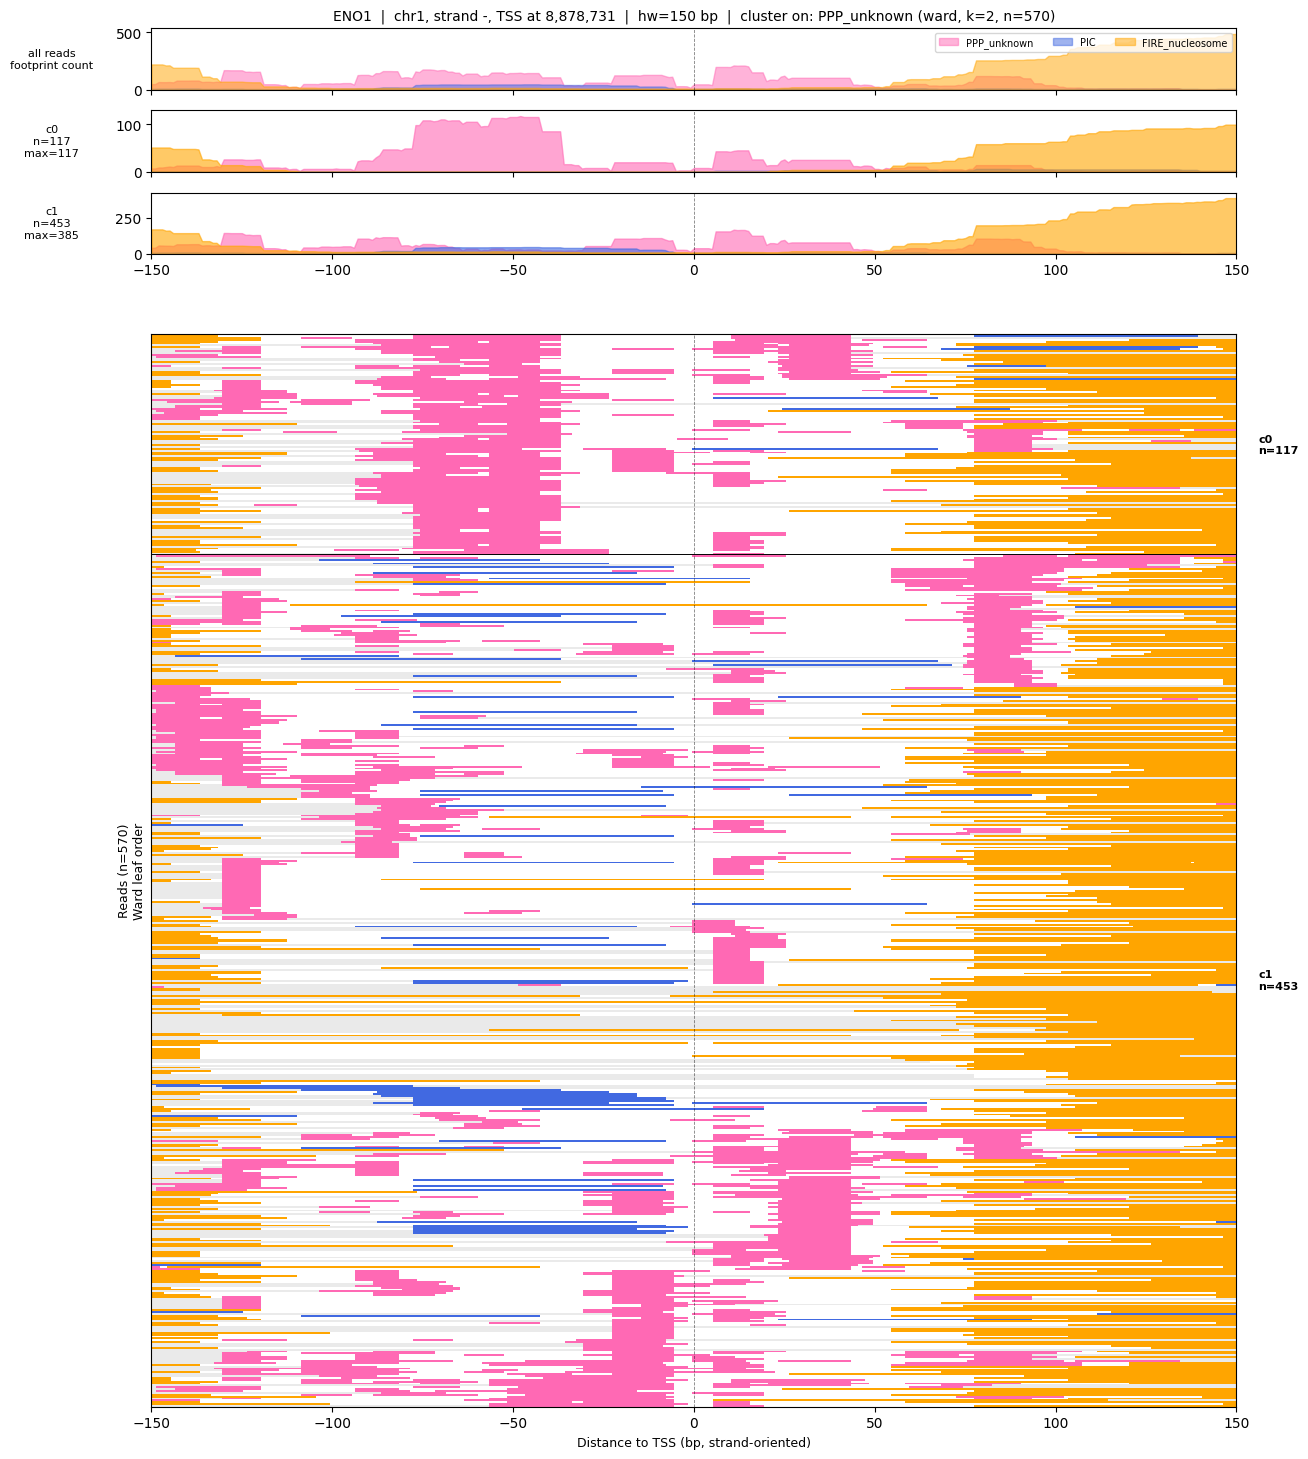

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ENO1_w300_single_PPP_unknown_ward_cluster_panels_k2.pdf


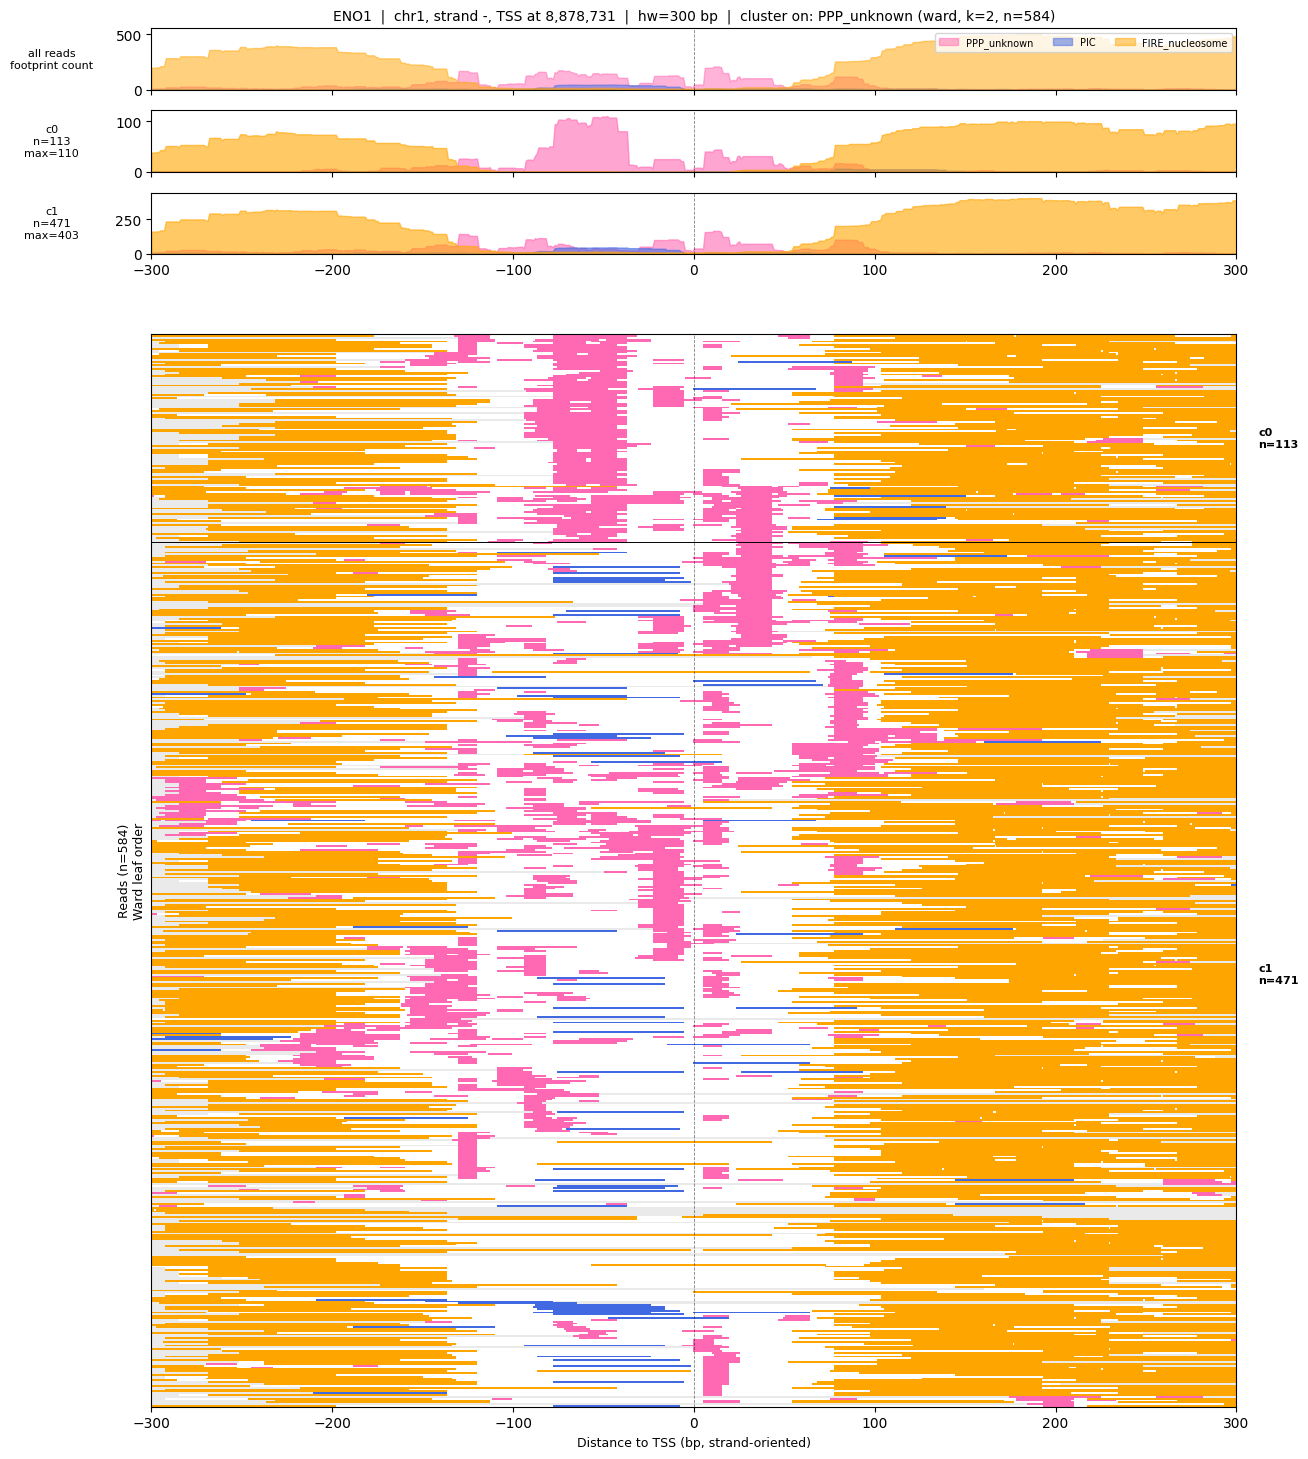

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ZCWPW1_w150_single_PPP_unknown_ward_cluster_panels_k2.pdf


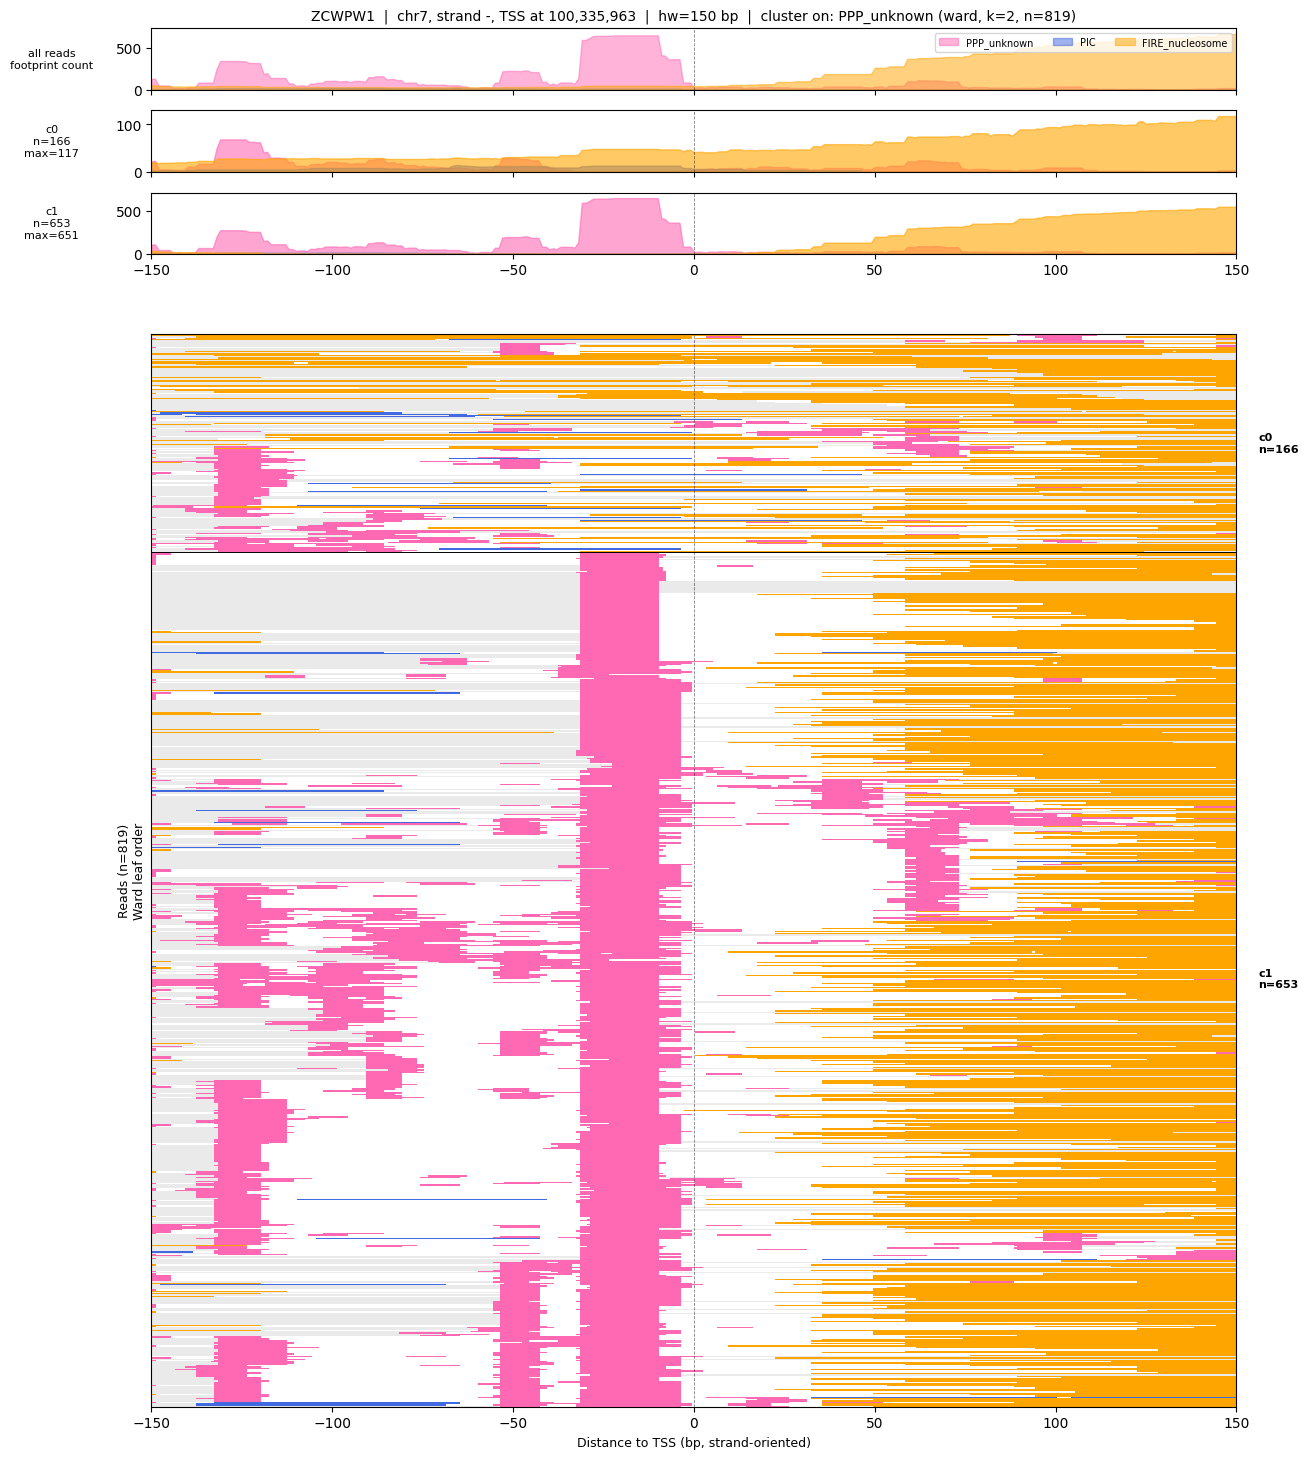

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ZCWPW1_w300_single_PPP_unknown_ward_cluster_panels_k2.pdf


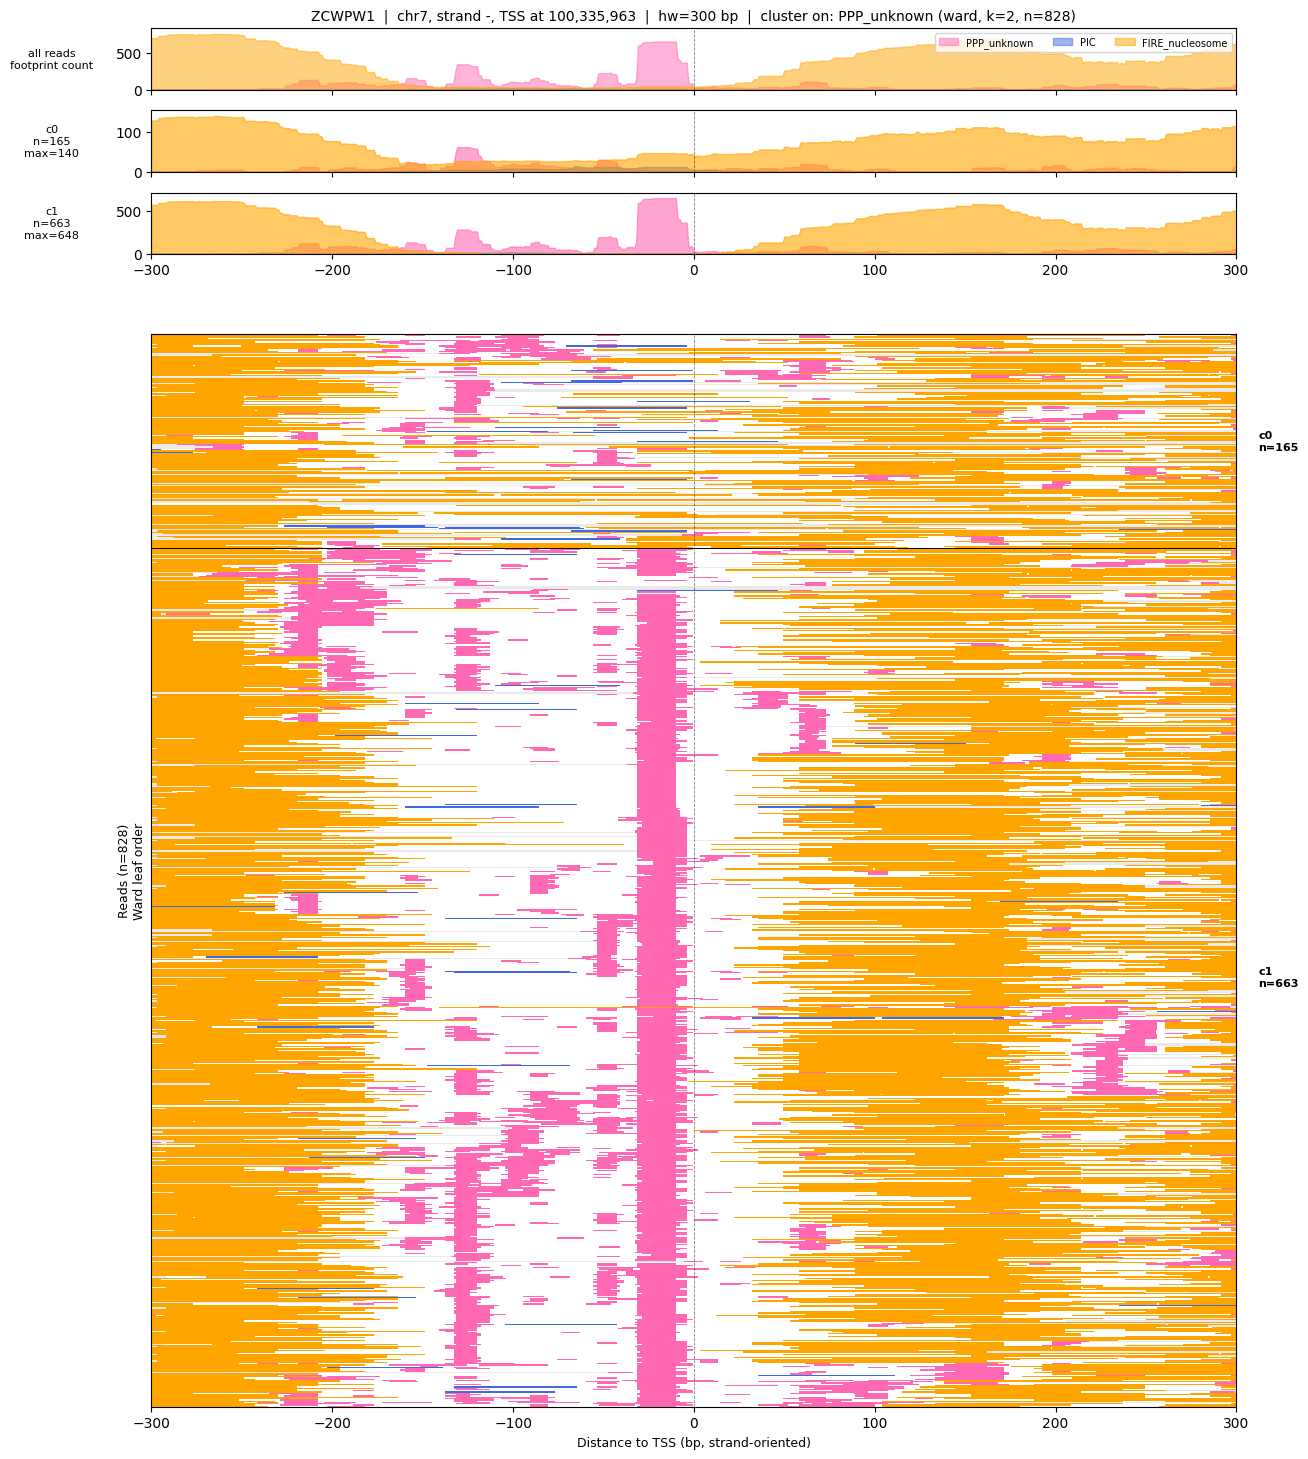

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ENO1_w150_single_PIC_ward_cluster_panels_k2.pdf


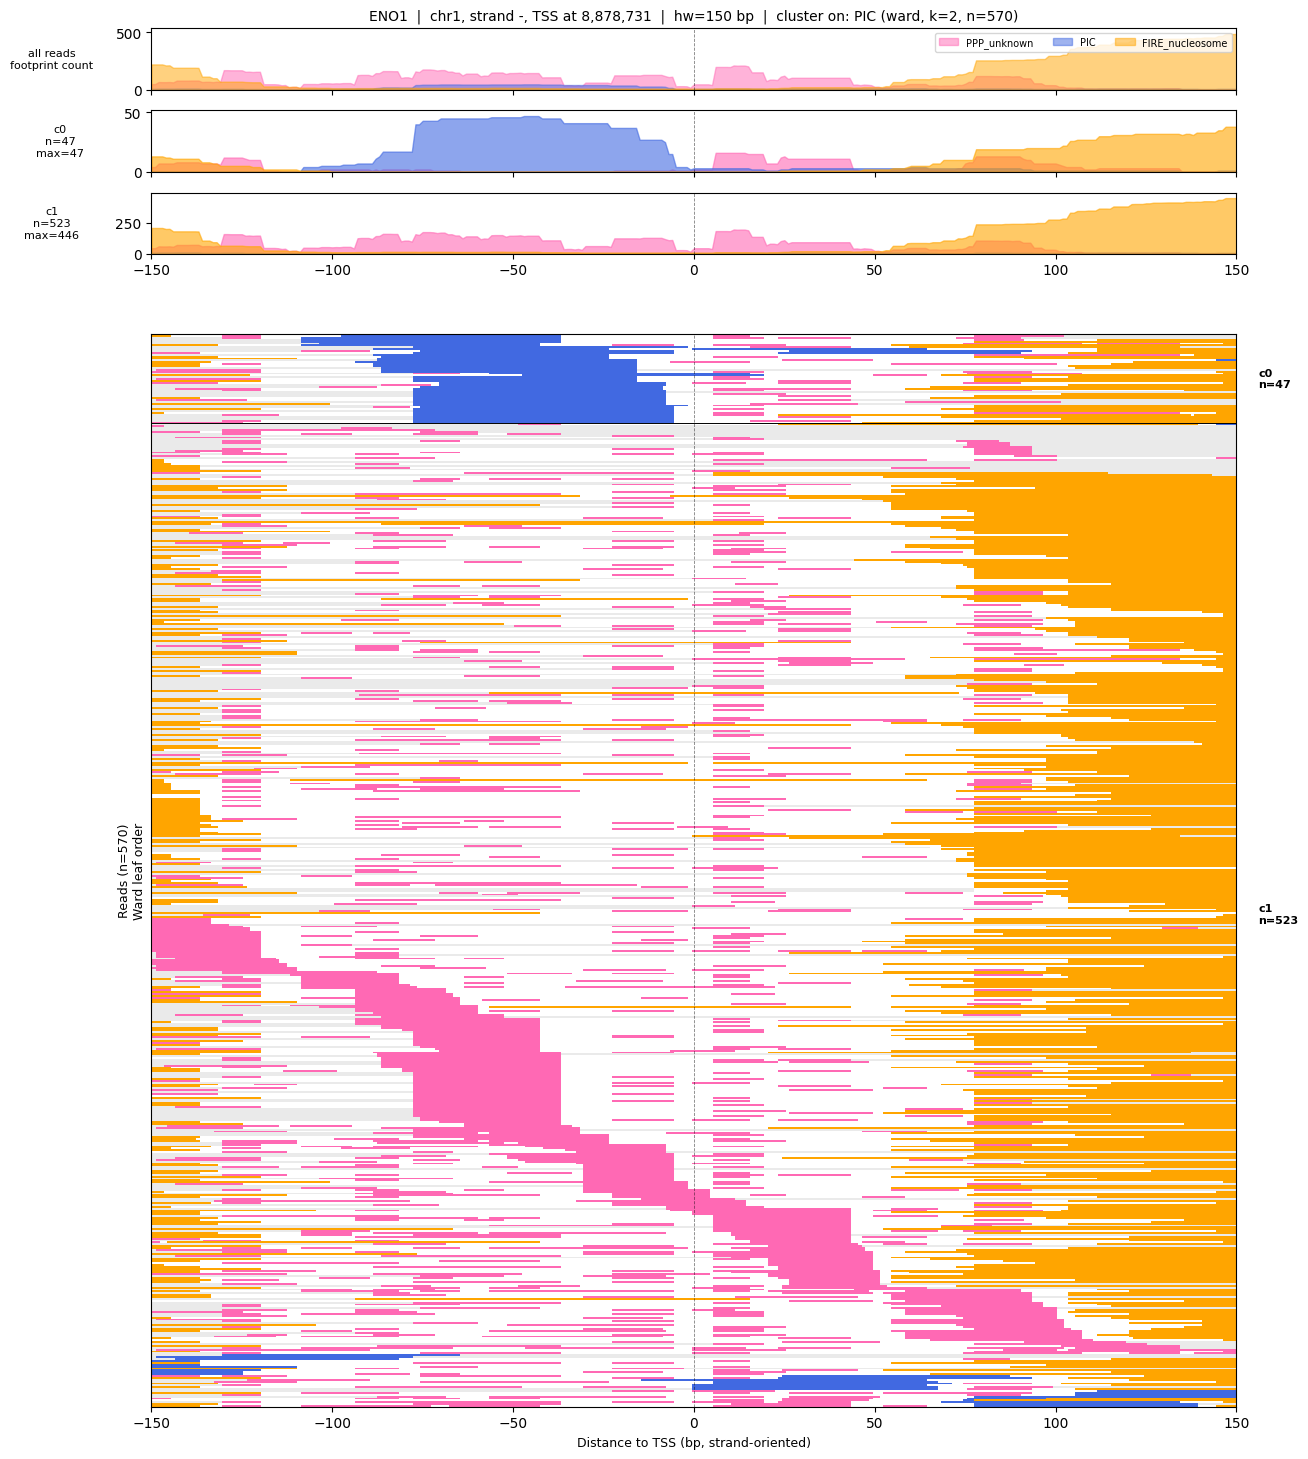

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ENO1_w300_single_PIC_ward_cluster_panels_k2.pdf


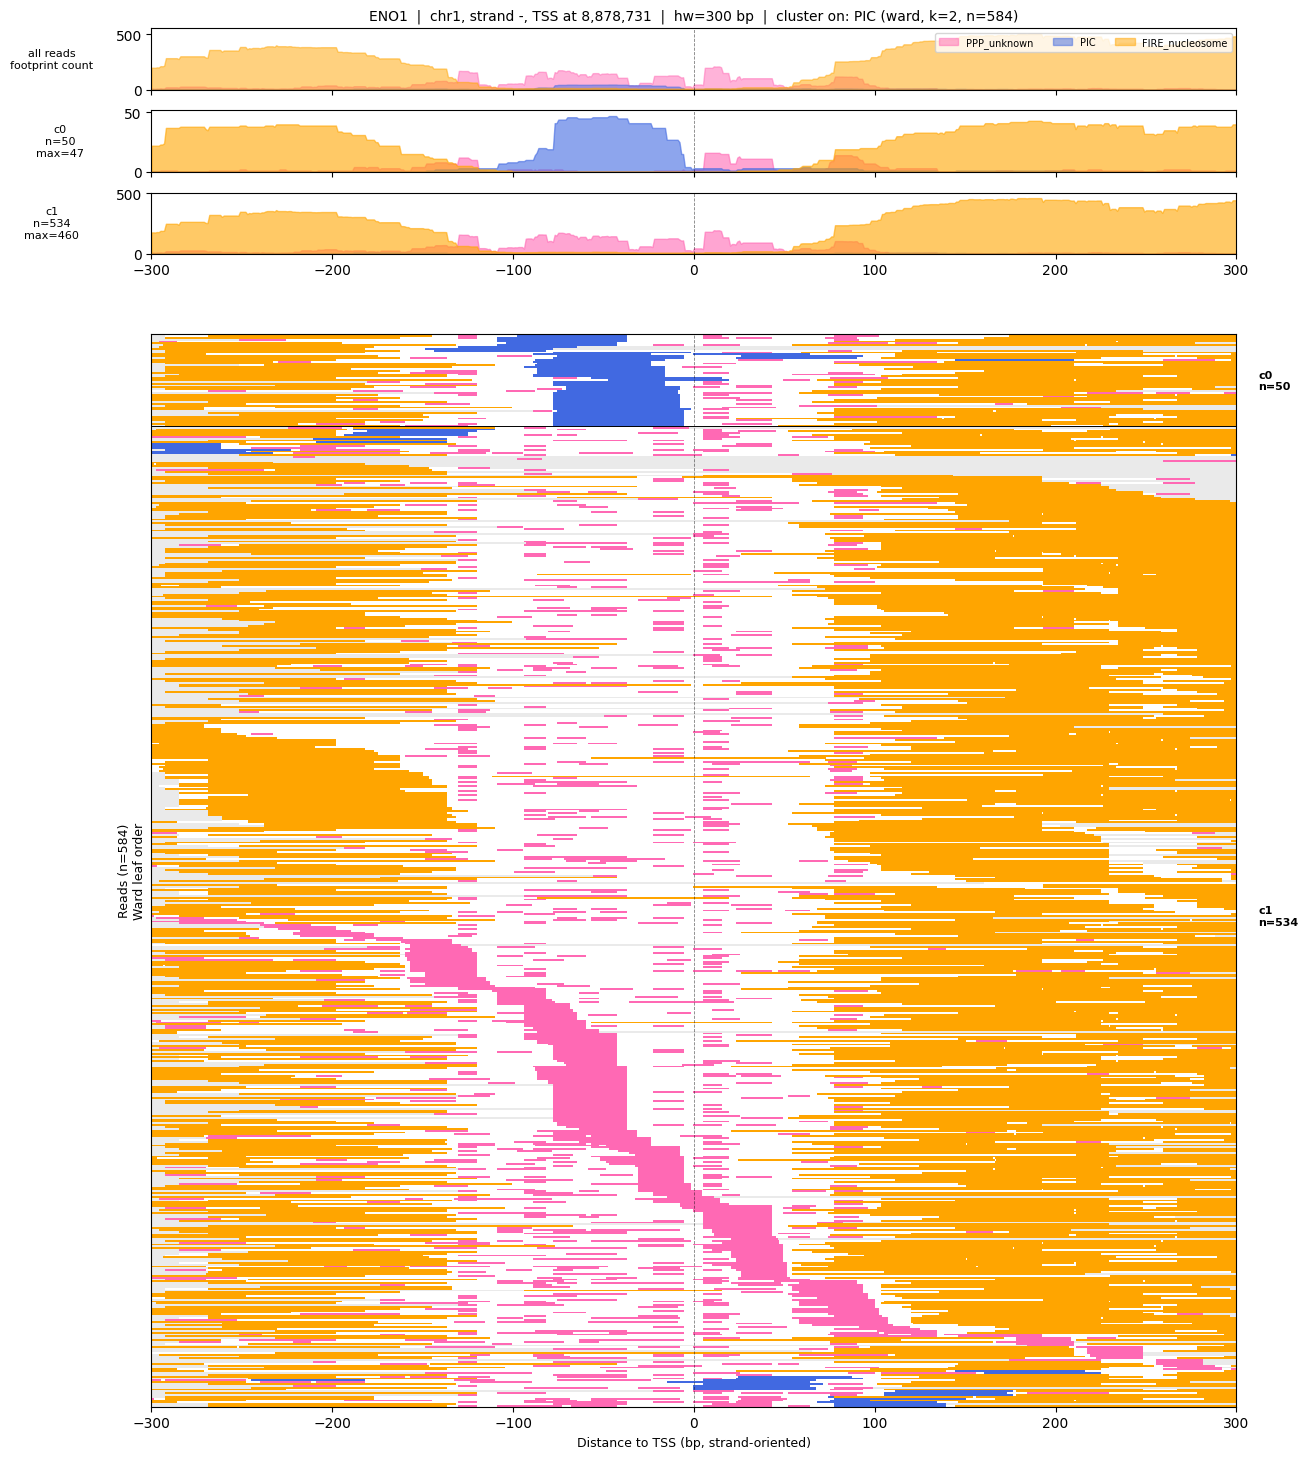

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ZCWPW1_w150_single_PIC_ward_cluster_panels_k3.pdf


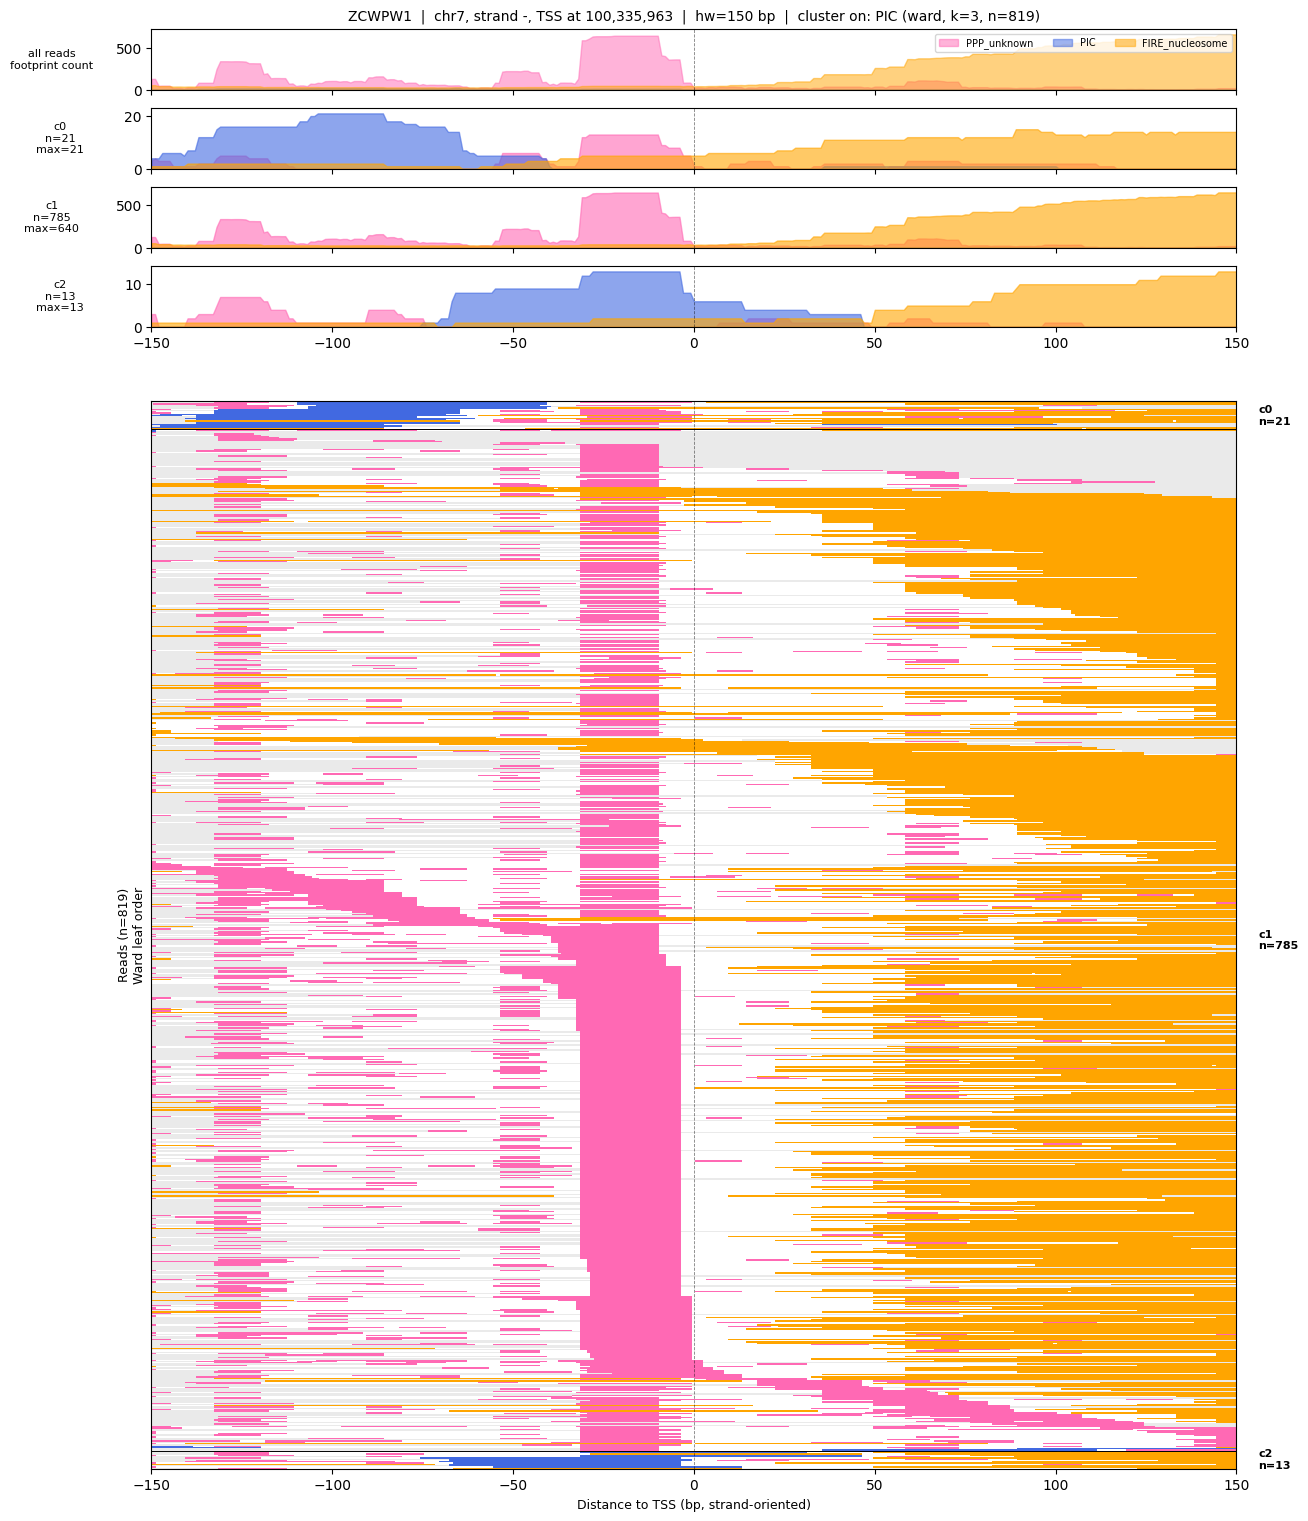

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ZCWPW1_w300_single_PIC_ward_cluster_panels_k4.pdf


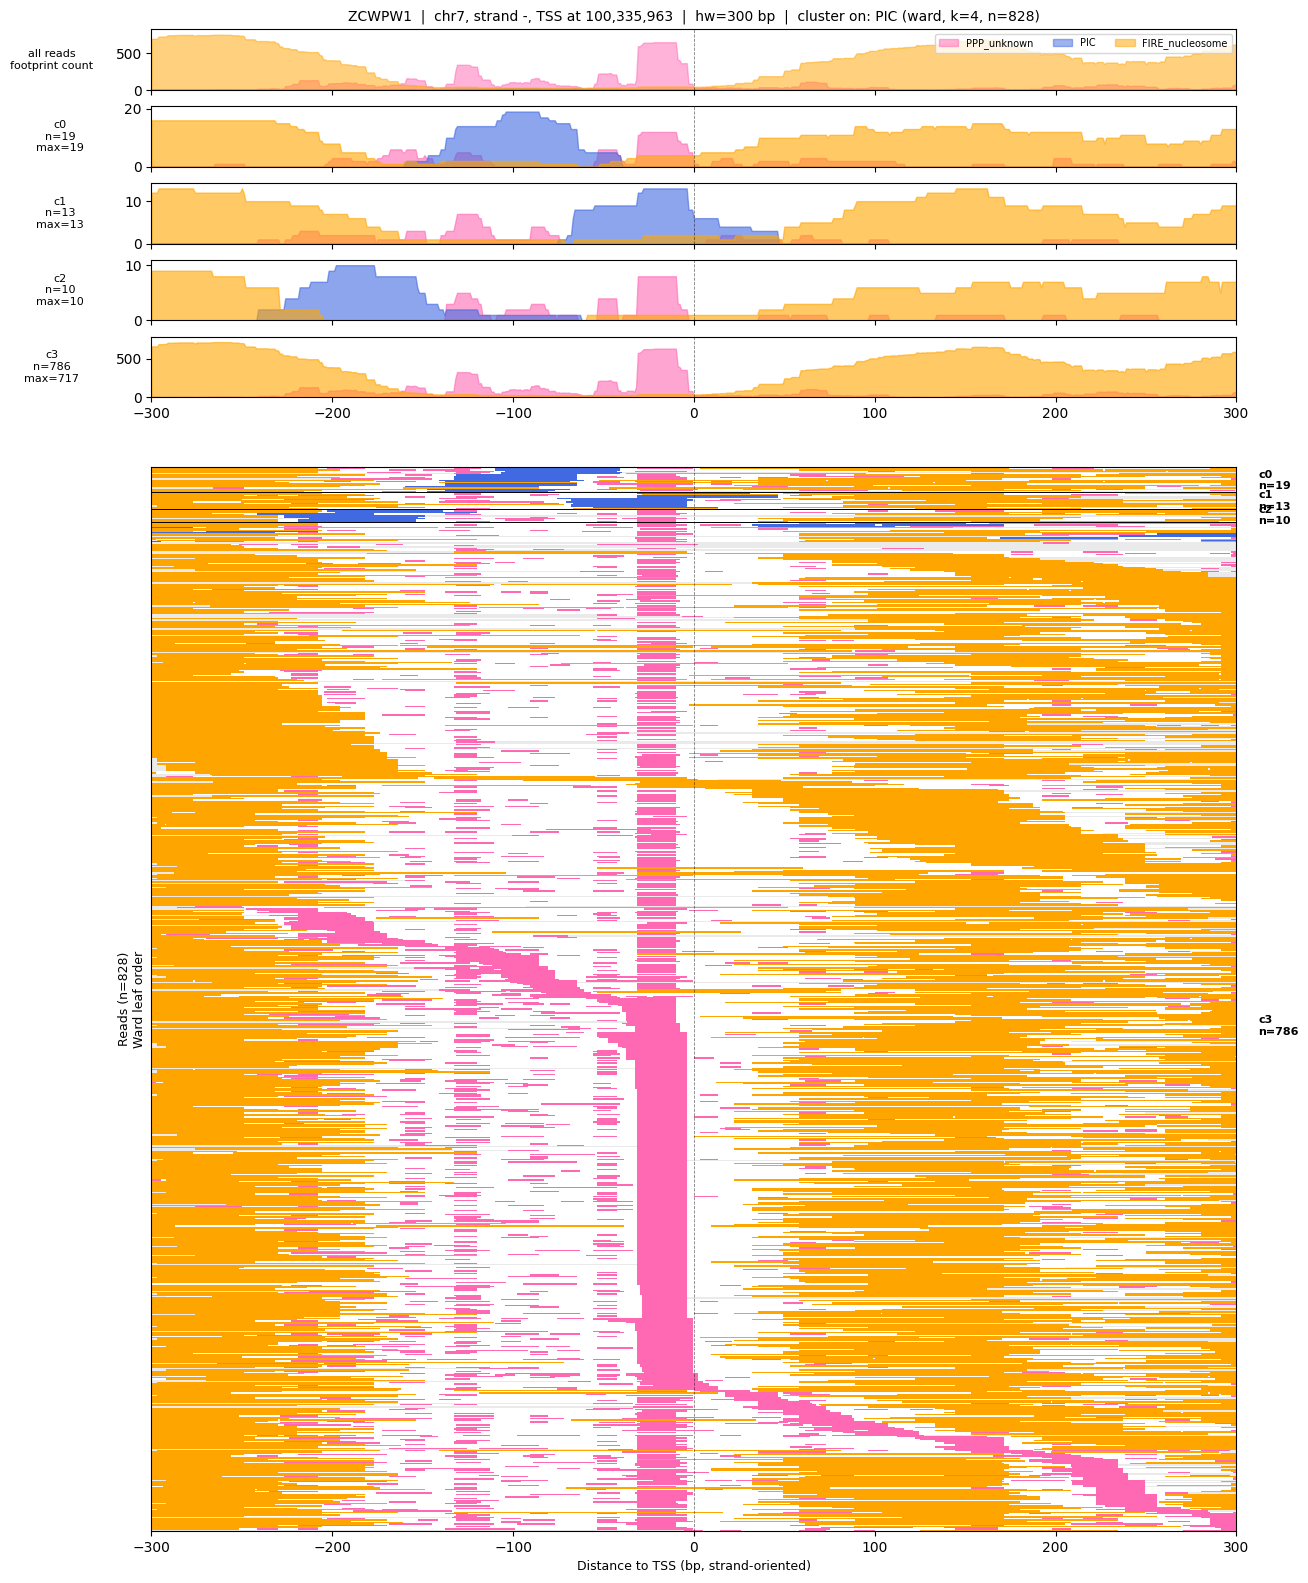

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ENO1_w150_single_FIRE_nucleosome_ward_cluster_panels_k2.pdf


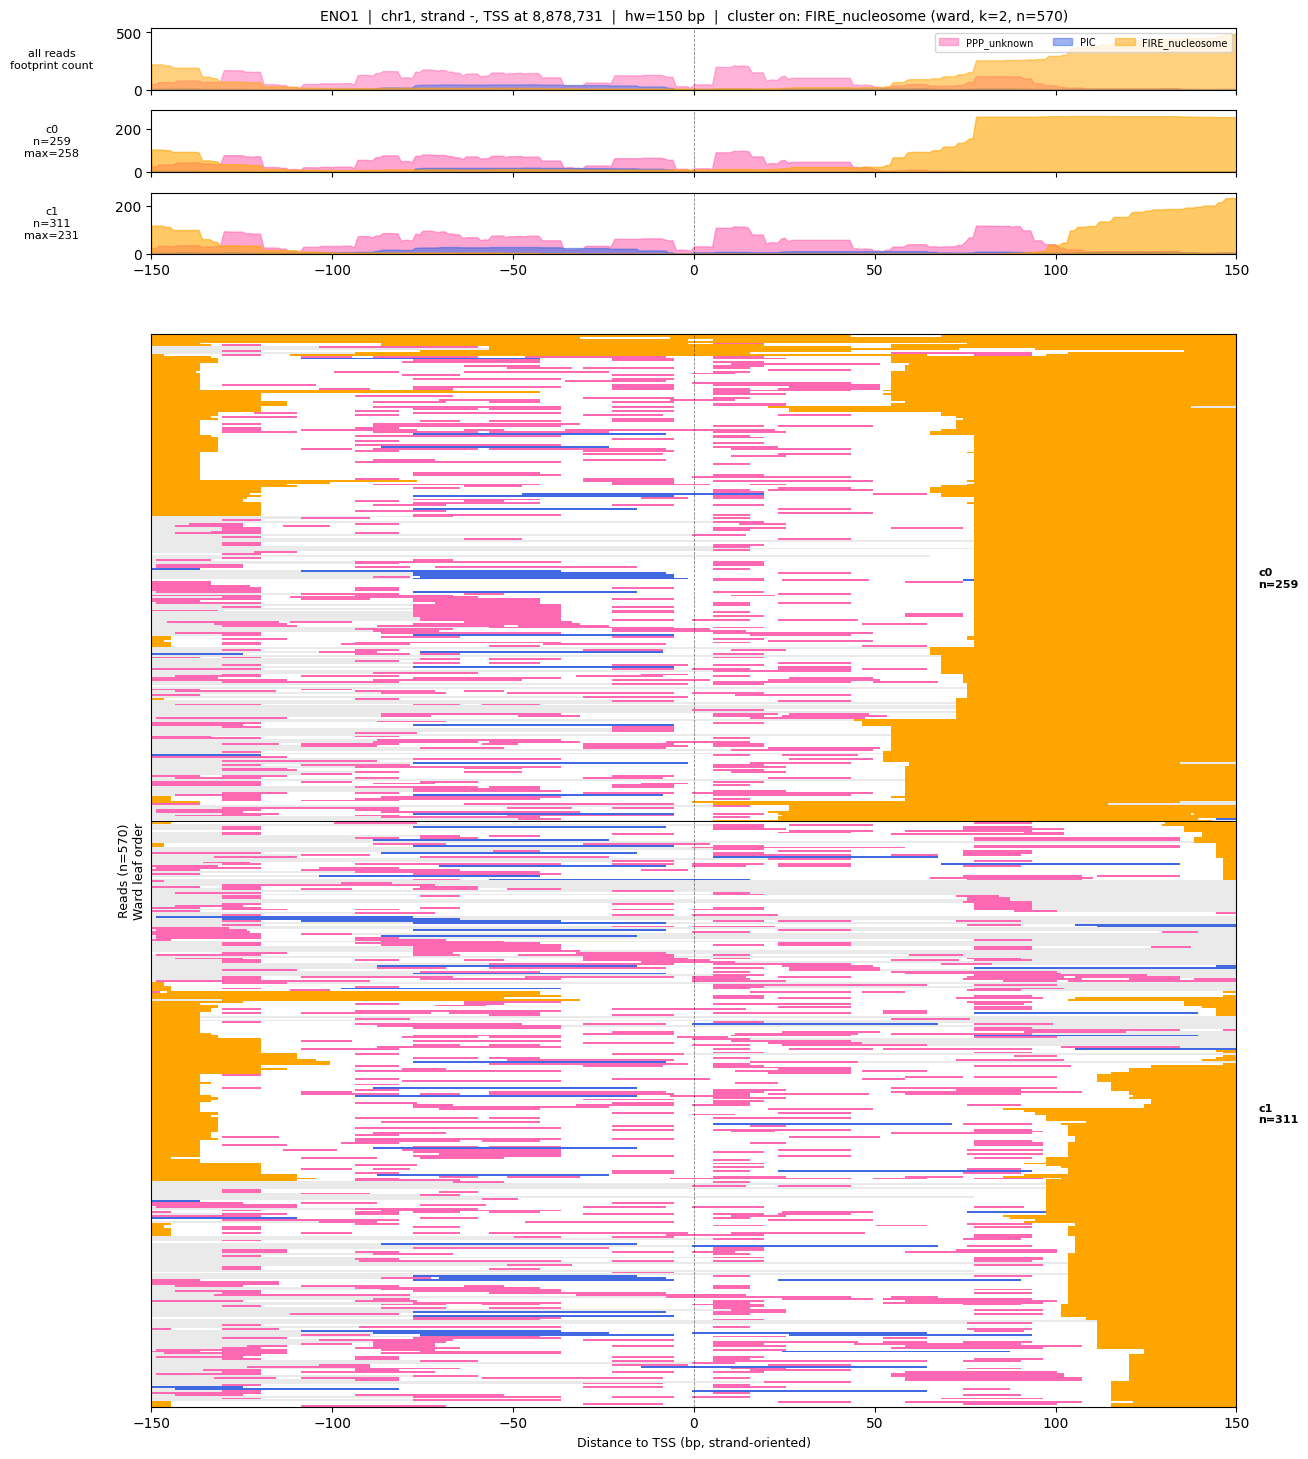

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ENO1_w300_single_FIRE_nucleosome_ward_cluster_panels_k2.pdf


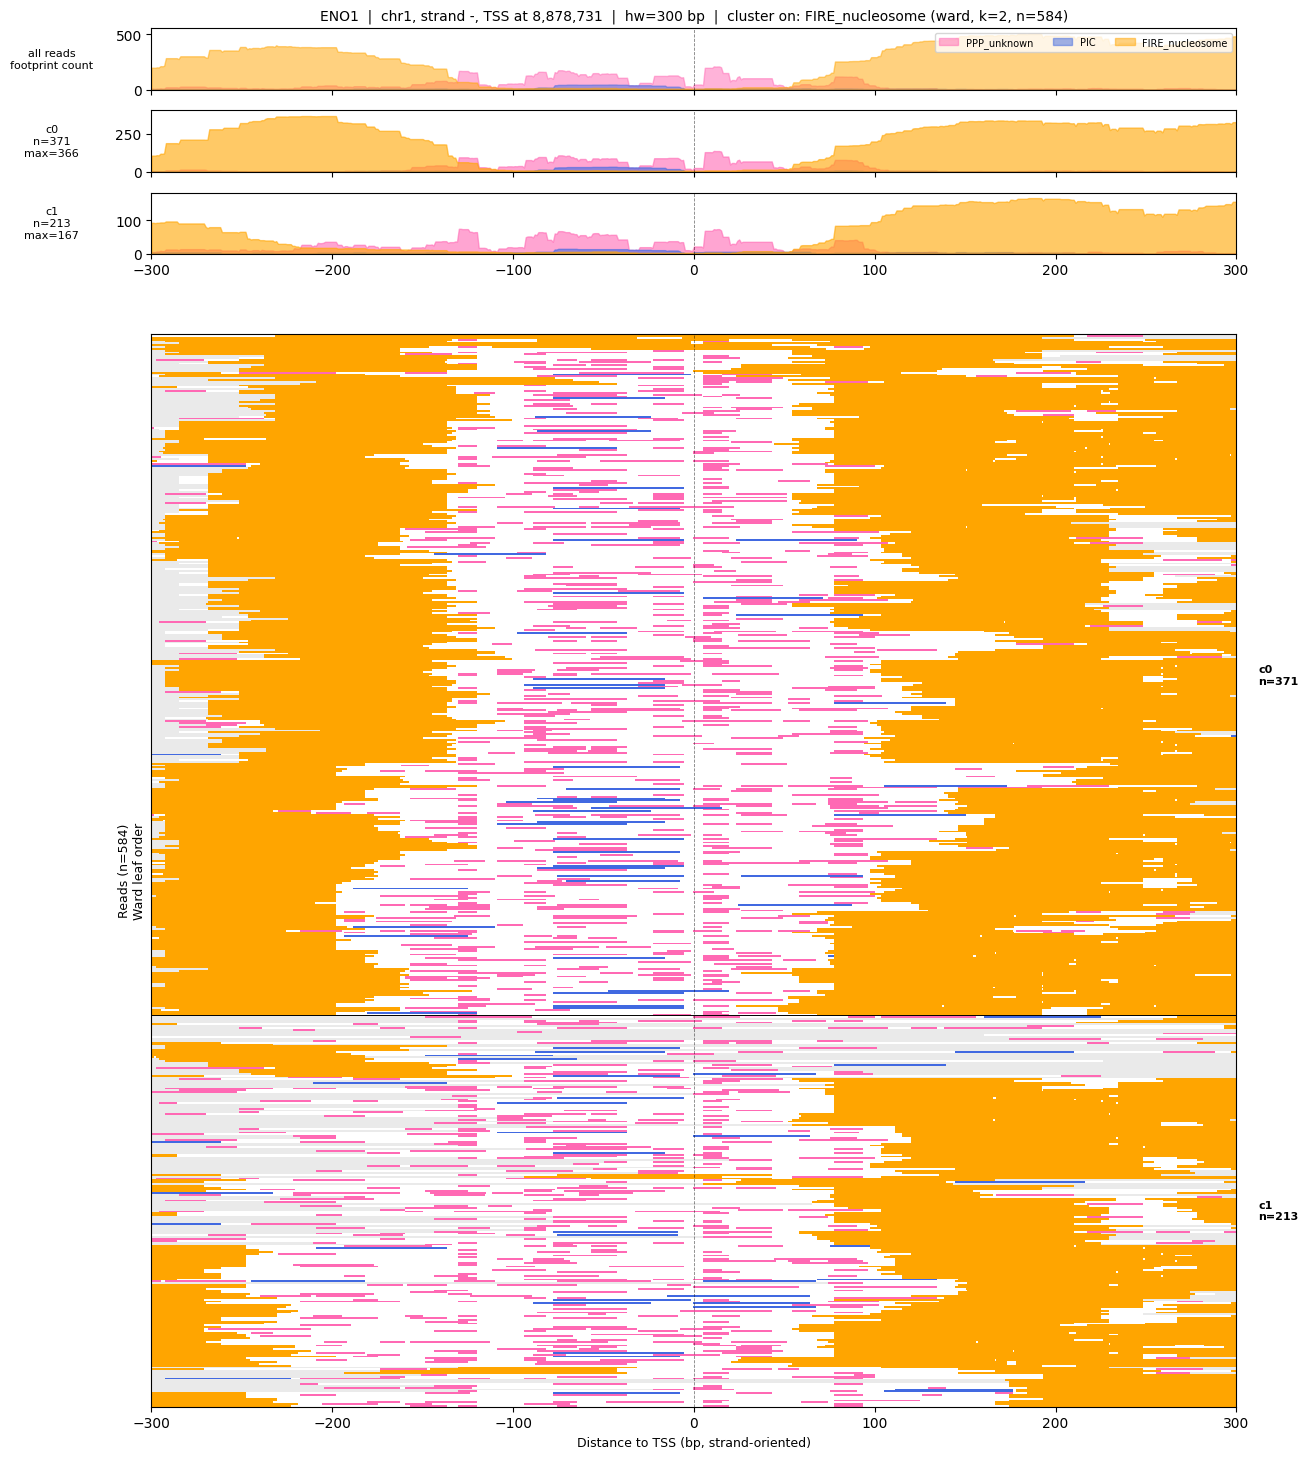

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ZCWPW1_w150_single_FIRE_nucleosome_ward_cluster_panels_k2.pdf


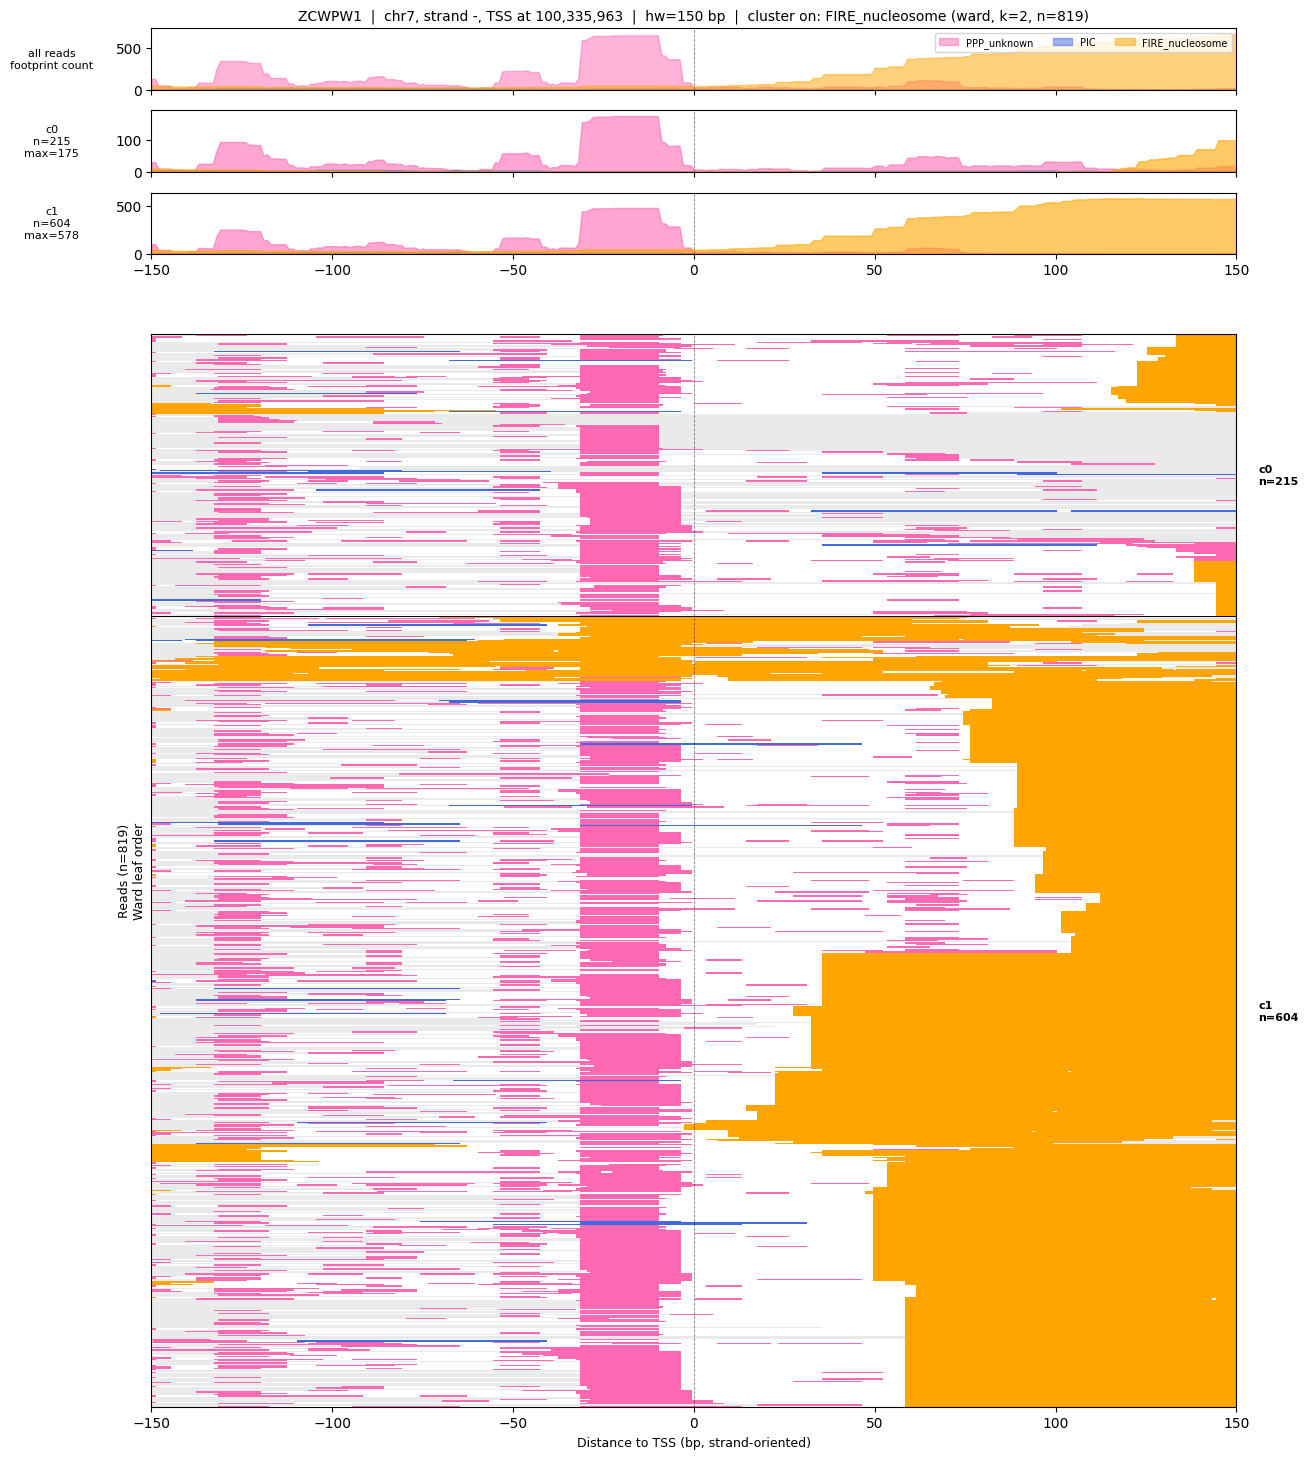

/home/cshan/ipykernel_3839657/4036326097.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_single_FP_class/31samples_pooled/ZCWPW1_w300_single_FIRE_nucleosome_ward_cluster_panels_k2.pdf


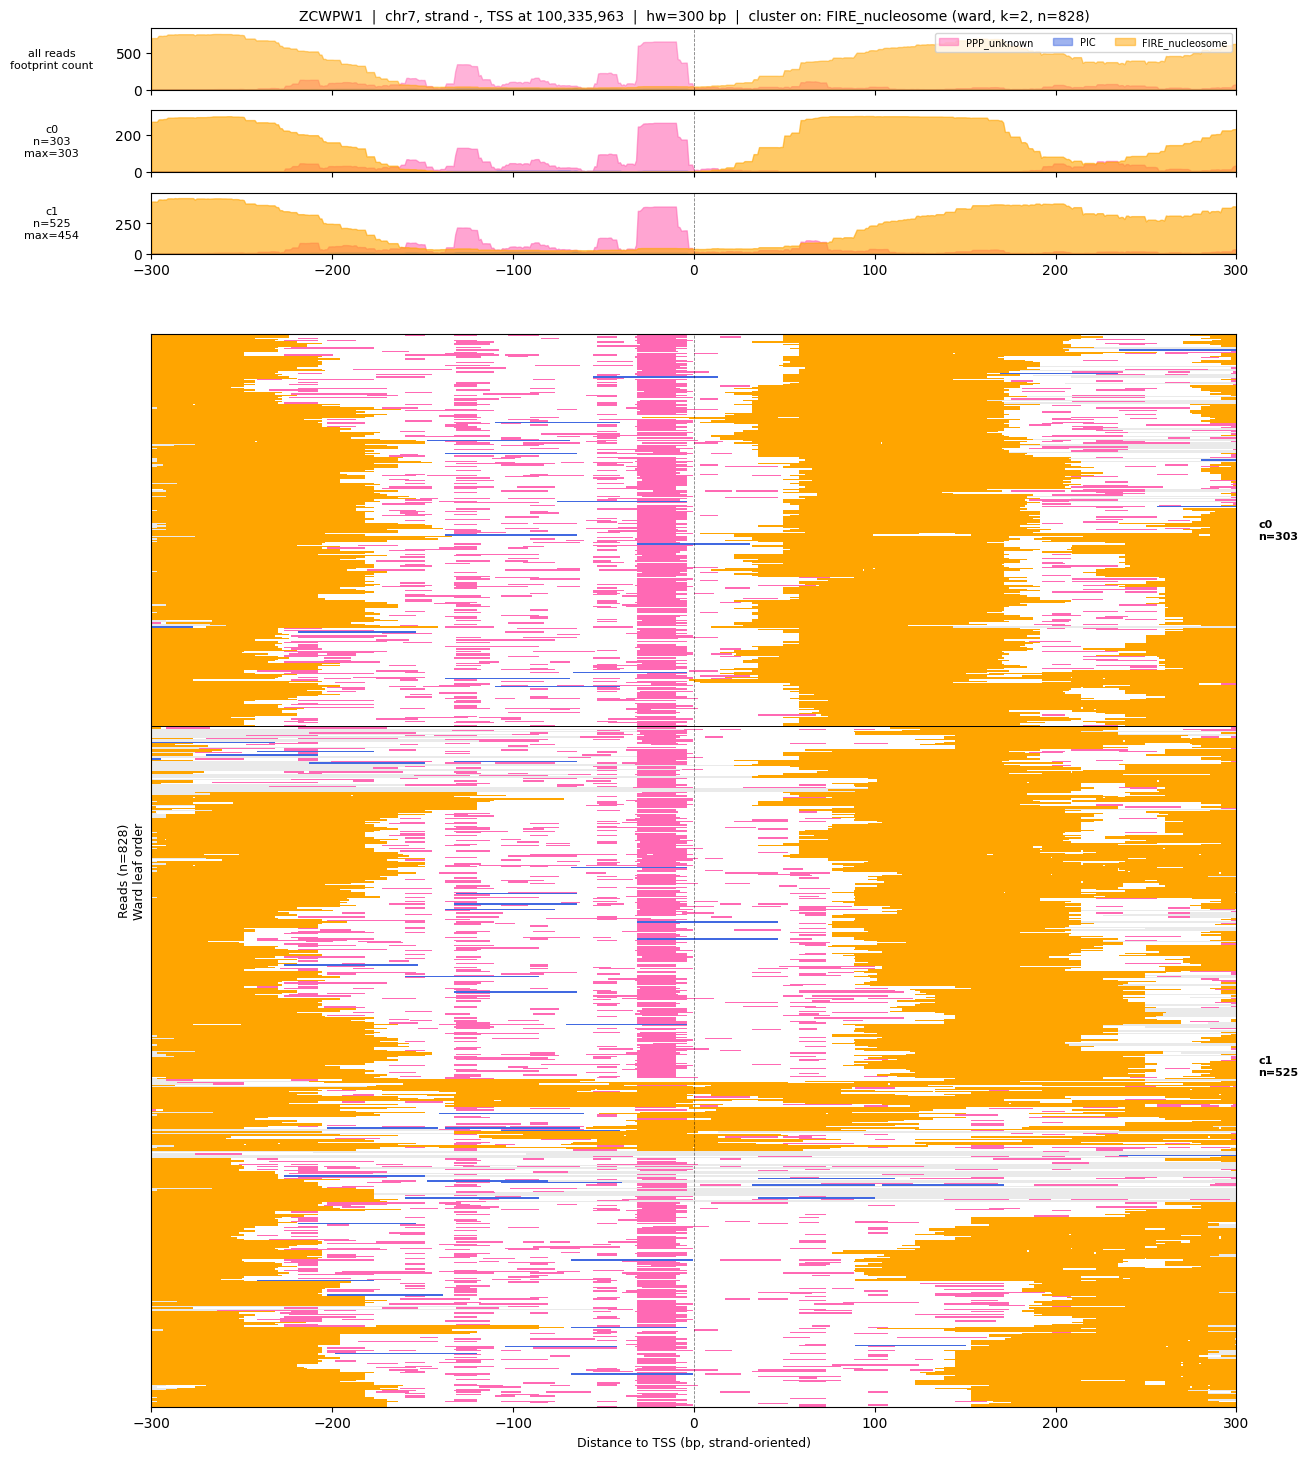

In [22]:
def plot_sc_cluster_panels(driving_cls, gene_name, hw, res):
    occ        = res["occ"]
    aligned    = res["aligned"]
    classes    = res["classes"]
    chrom      = res["chrom"]
    strand     = res["strand"]
    tss        = res["tss"]
    k          = res["k"]
    labels     = res["labels"]
    leaf_order = res["leaf_order"]
    method     = res["method"]
    n_classes, n_reads, n_pos = occ.shape
    rel_pos    = np.arange(-hw, hw + 1)

    # counts read per cluster
    sizes = {c: int((labels == c).sum()) for c in range(k)}
    # only keep clusters that contain read
    present_clusters = [c for c in range(k) if sizes[c] > 0]

    profiles = {}
    for cluster_id in range(k):
        cluster_mask = (labels == cluster_id)
        profiles[cluster_id] = {}
        for ci, cls in enumerate(classes):
            if cluster_mask.sum() == 0:
                profiles[cluster_id][cls] = np.zeros(n_pos)
            else:
                profiles[cluster_id][cls] = occ[ci, cluster_mask].sum(axis=0)

    combined = {cls: occ[ci].sum(axis=0) for ci, cls in enumerate(classes)}
    combined_ymax = max((v.max() for v in combined.values()), default=1.0)
    combined_ymax = max(combined_ymax, 1.0)

    order = np.asarray(leaf_order, dtype=int)
    labels_sorted = labels[order]

    img = np.tile(np.array(WHITE_RGB, dtype=np.float32), (n_reads, n_pos, 1))
    img[~aligned] = UNCOVERED_RGB
    for ci, cls in enumerate(classes):
        if cls not in SC_FP_COLORS:
            continue
        rgb  = np.array(mcolors.to_rgb(SC_FP_COLORS[cls]), dtype=np.float32)
        mask = occ[ci] > 0
        img[mask] = rgb
    img_sorted = img[order]

    n_top_tracks = len(present_clusters) + 1
    bot_height   = min(14.0, max(3.5, 0.05 * n_reads))
    spacer       = 0.5
    fig_height   = 0.8 * n_top_tracks + bot_height + spacer + 1.0

    fig = plt.figure(figsize=(14, fig_height))
    gs = plt.GridSpec(
        n_top_tracks + 2, 1,
        height_ratios=[0.8] * n_top_tracks + [spacer] + [bot_height],
        hspace=0.08,
    )
    ax_combined = fig.add_subplot(gs[0])
    per_cluster_axes = {
        c: fig.add_subplot(gs[1 + i], sharex=ax_combined)
        for i, c in enumerate(present_clusters)
    }
    ax_bot = fig.add_subplot(gs[n_top_tracks + 1], sharex=ax_combined)

    for cls in classes:
        if cls not in SC_FP_COLORS:
            continue
        ax_combined.fill_between(rel_pos, 0, combined[cls],
                                 color=SC_FP_COLORS[cls], alpha=0.5, label=cls)
    ax_combined.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax_combined.set_xlim(-hw, hw)
    ax_combined.set_ylim(0, combined_ymax * 1.1)
    ax_combined.set_ylabel("all reads\nfootprint count", fontsize=8,
                           rotation=0, labelpad=46, va="center")
    ax_combined.set_title(
        f"{gene_name}  |  {chrom}, strand {strand}, TSS at {tss:,}  |  "
        f"hw={hw} bp  |  cluster on: {driving_cls} ({method}, k={k}, n={n_reads})",
        fontsize=10,
    )
    ax_combined.legend(loc="upper right", fontsize=7, ncol=min(n_classes, 5))
    plt.setp(ax_combined.get_xticklabels(), visible=False)

    last_idx = len(present_clusters) - 1
    for i, cluster_id in enumerate(present_clusters):
        ax = per_cluster_axes[cluster_id]
        for cls in classes:
            if cls not in SC_FP_COLORS:
                continue
            ax.fill_between(rel_pos, 0, profiles[cluster_id][cls],
                            color=SC_FP_COLORS[cls], alpha=0.6)
        ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
        ax.set_xlim(-hw, hw)
        cluster_ymax = max(
            (profiles[cluster_id][cls].max() for cls in classes if cls in SC_FP_COLORS),
            default=1.0,
        )
        cluster_ymax = max(cluster_ymax, 1.0)
        ax.set_ylim(0, cluster_ymax * 1.1)
        ax.set_ylabel(
            f"c{cluster_id}\nn={sizes[cluster_id]}\nmax={int(cluster_ymax)}",
            fontsize=8, rotation=0, labelpad=46, va="center",
        )
        if i < last_idx:
            plt.setp(ax.get_xticklabels(), visible=False)

    ax_bot.imshow(img_sorted, aspect="auto", interpolation="nearest",
                  extent=[-hw - 0.5, hw + 0.5, n_reads, 0])
    ax_bot.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    boundaries = np.where(np.diff(labels_sorted) != 0)[0] + 1
    for b in boundaries:
        ax_bot.axhline(b - 0.5, color="black", lw=0.7)
    label_x = hw + (2 * hw) * 0.02
    for c in present_clusters:
        idx = np.where(labels_sorted == c)[0]
        if len(idx):
            ax_bot.text(label_x, (idx.min() + idx.max()) / 2,
                        f"c{c}\nn={sizes[c]}", fontsize=8, va="center",
                        color="black", fontweight="bold")
    ax_bot.set_xlim(-hw, hw)
    ax_bot.set_ylim(n_reads, -1)
    ax_bot.set_yticks([])
    order_label = "Ward leaf order" if method == "ward" else "k-means order"
    ax_bot.set_ylabel(f"Reads (n={n_reads})\n{order_label}", fontsize=9)
    ax_bot.set_xlabel("Distance to TSS (bp, strand-oriented)", fontsize=9)

    plt.tight_layout()
    tag = driving_cls.replace(" ", "_").replace("(", "").replace(")", "")
    out_pdf = SC_OUT_ROOT / f"{gene_name}_w{hw}_single_{tag}_{method}_cluster_panels_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


for (driving_cls, gene_name, hw), res in sc_cluster_results.items():
    plot_sc_cluster_panels(driving_cls, gene_name, hw, res)

# Cluster by TSS-proximal region (-100 to +10 bp)

Three-class binary occupancy matrices (PPP_unknown, PIC, FIRE_nucleosome)
are built with a display half-window of 300 bp, but clustering uses only
the **-100 to +10 bp** TSS-relative columns (concatenated across all three
classes). Set `CLUSTER_METHOD` to `"ward"` (dendrogram leaf order) or
`"kmeans"` (silhouette-based k, rows sorted by cluster).

Genes in this section (hard-coded coordinates, not from the pausing table):

| Gene   | Chrom | Strand | TSS         |
|--------|-------|--------|-------------|
| ALAS1  | chr3  | +      | 52,198,093  |
| ENO1   | chr1  | -      |  8,878,731  |
| ZCWPW1 | chr7  | -      | 100,335,963 |

### 1. Setup and multi-class occupancy matrix build.

In [29]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

sys.path.insert(0, "/project/spott/cshan/fiber-seq/code/PolII_footprints_code")
from plot_polii_footprints_precomputed_sort import (
    collect_reads_from_indexed_beds,
    _filter_fire_nucleosome_by_length,
    DEFAULT_FP_BED_DIR,
    DEFAULT_FIRE_NUC_LENGTH_RANGE,
    FP_COLORS,
)

TSS_GENES = pd.DataFrame([
    {"gene_name": "ALAS1",  "chrom": "chr3", "strand": "+", "tss_anchor": 52198093},
    {"gene_name": "ENO1",   "chrom": "chr1", "strand": "-", "tss_anchor": 8878731},
    {"gene_name": "ZCWPW1", "chrom": "chr7", "strand": "-", "tss_anchor": 100335963},
])

FP_CLASSES = [
    "PPP_unknown",
    "PIC",
    "FIRE_nucleosome",
]
SOURCE_CLASSES = {
    "PPP_unknown": ["PPP", "unknown"],
    "PIC": ["PIC"],
    "FIRE_nucleosome": ["FIRE_nucleosome"],
}
TSS_FP_COLORS = {
    "PPP_unknown": "#FF69B4",
    "PIC": "#4169E1",
    "FIRE_nucleosome": "#FFA500",
}

TSS_HW                     = 300
CLUSTER_REL_START          = -100
CLUSTER_REL_END            = 10
FILTER_FIRE_NUC_BY_LENGTH  = False
FIRE_NUC_LENGTH_RANGE      = DEFAULT_FIRE_NUC_LENGTH_RANGE
TSS_BIN_BP                 = 10
TSS_TOP_MERGES             = 20
UNCOVERED_RGB              = (0.92, 0.92, 0.92)
WHITE_RGB                  = (1.00, 1.00, 1.00)

CLUSTER_METHOD = "ward"   # "ward" or "kmeans"
K_RANGE = list(range(2, 10))

TSS_OUT_ROOT = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/"
    "31samples_pooled"
)
TSS_OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Genes                : {list(TSS_GENES['gene_name'])}")
print(f"Display half-window  : {TSS_HW} bp")
print(f"Clustering region    : [{CLUSTER_REL_START}, {CLUSTER_REL_END}] bp rel. to TSS")
print(f"Bin size             : {TSS_BIN_BP} bp")
print(f"Classes              : {FP_CLASSES}")
print(f"Source mapping       : {SOURCE_CLASSES}")
print(f"Cluster method       : {CLUSTER_METHOD}")
print(f"Output dir           : {TSS_OUT_ROOT}\n")

tss_matrices = {}
for _, g in TSS_GENES.iterrows():
    gene_name = g["gene_name"]
    chrom     = g["chrom"]
    strand    = g["strand"]
    tss       = int(g["tss_anchor"])
    hw        = TSS_HW

    view_start = max(0, tss - hw)
    view_end   = tss + hw
    n_pos      = 2 * hw + 1

    read_spans = collect_reads_from_indexed_beds(
        chrom, view_start, view_end,
        fp_class="all", beds_dir=DEFAULT_FP_BED_DIR,
    )

    per_class_reads = {}
    for cls, sources in SOURCE_CLASSES.items():
        merged = {}
        for src in sources:
            src_reads = collect_reads_from_indexed_beds(
                chrom, view_start, view_end,
                fp_class=src, beds_dir=DEFAULT_FP_BED_DIR,
            )
            for read_name, fps in src_reads.items():
                merged.setdefault(read_name, []).extend(fps)
        per_class_reads[cls] = merged
    if FILTER_FIRE_NUC_BY_LENGTH and "FIRE_nucleosome" in per_class_reads:
        per_class_reads["FIRE_nucleosome"] = _filter_fire_nucleosome_by_length(
            per_class_reads["FIRE_nucleosome"], FIRE_NUC_LENGTH_RANGE
        )

    read_ids = list(read_spans.keys())
    n_reads  = len(read_ids)
    n_cls    = len(FP_CLASSES)

    occ     = np.zeros((n_cls, n_reads, n_pos), dtype=np.float32)
    aligned = np.zeros((n_reads, n_pos), dtype=bool)
    r_starts = np.zeros(n_reads, dtype=np.int64)
    r_ends   = np.zeros(n_reads, dtype=np.int64)

    def _rel_bounds(g_start, g_end_excl, _strand=strand, _tss=tss, _hw=hw):
        g_end_incl = g_end_excl - 1
        if _strand == "+":
            rel_lo = g_start    - _tss
            rel_hi = g_end_incl - _tss
        else:
            rel_lo = _tss - g_end_incl
            rel_hi = _tss - g_start
        return max(rel_lo, -_hw), min(rel_hi, _hw)

    for i, read_name in enumerate(read_ids):
        span_fps = read_spans[read_name]
        r_starts[i] = min(fp[0] for fp in span_fps)
        r_ends[i]   = max(fp[1] for fp in span_fps)

        rel_lo, rel_hi = _rel_bounds(r_starts[i], r_ends[i])
        if rel_lo <= rel_hi:
            aligned[i, rel_lo + hw : rel_hi + hw + 1] = True

        for ci, cls in enumerate(FP_CLASSES):
            for fp in per_class_reads[cls].get(read_name, []):
                rel_lo, rel_hi = _rel_bounds(fp[0], fp[1])
                if rel_lo <= rel_hi:
                    occ[ci, i, rel_lo + hw : rel_hi + hw + 1] = 1.0

    tss_matrices[gene_name] = {
        "read_ids": read_ids,
        "occ":      occ,
        "aligned":  aligned,
        "r_start":  r_starts,
        "r_end":    r_ends,
        "chrom":    chrom,
        "strand":   strand,
        "tss":      tss,
        "hw":       hw,
        "classes":  list(FP_CLASSES),
    }
    print(f"  {gene_name} hw={hw}: n_reads={n_reads}")
    for ci, cls in enumerate(FP_CLASSES):
        n_with = int((occ[ci].sum(axis=1) > 0).sum())
        print(f"    {cls:24s}: {n_with} reads with >=1 footprint")

Genes                : ['ALAS1', 'ENO1', 'ZCWPW1']
Display half-window  : 300 bp
Clustering region    : [-100, 10] bp rel. to TSS
Bin size             : 10 bp
Classes              : ['PPP_unknown', 'PIC', 'FIRE_nucleosome']
Source mapping       : {'PPP_unknown': ['PPP', 'unknown'], 'PIC': ['PIC'], 'FIRE_nucleosome': ['FIRE_nucleosome']}
Cluster method       : ward
Output dir           : /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled



[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr3_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr3_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi


  ALAS1 hw=300: n_reads=648
    PPP_unknown             : 577 reads with >=1 footprint
    PIC                     : 90 reads with >=1 footprint
    FIRE_nucleosome         : 644 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi


  ENO1 hw=300: n_reads=584
    PPP_unknown             : 525 reads with >=1 footprint
    PIC                     : 86 reads with >=1 footprint
    FIRE_nucleosome         : 577 reads with >=1 footprint
  ZCWPW1 hw=300: n_reads=828
    PPP_unknown             : 797 reads with >=1 footprint
    PIC                     : 58 reads with >=1 footprint
    FIRE_nucleosome         : 824 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi


### 2. Clustering on the TSS-proximal region.

For each gene, the columns corresponding to positions **-100 to +10 bp**
(relative to TSS) are extracted from every class's occupancy matrix,
bin-smoothed, and horizontally concatenated into a single feature matrix.
If `CLUSTER_METHOD == "ward"`: Ward linkage + elbow-gap *k* selection,
rows ordered by dendrogram. If `CLUSTER_METHOD == "kmeans"`: silhouette-
based *k*, rows sorted by cluster label. Results used for all downstream
plots, which show the full display window.

In [30]:
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def _tss_bin_smooth_mean(X, bin_bp):
    n_reads, n_pos = X.shape
    n_bin = n_pos // bin_bp
    trimmed = X[:, : n_bin * bin_bp].reshape(n_reads, n_bin, bin_bp)
    return trimmed.mean(axis=2)


def _tss_ward_elbow_k(Z, top_merges=TSS_TOP_MERGES):
    distances = Z[:, 2]
    n_merges  = len(distances)
    if n_merges < 2:
        return np.zeros(n_merges + 1, dtype=int), 1, float("inf")

    n_top = min(top_merges, n_merges)
    top   = distances[-n_top:]
    diffs = np.diff(top)
    gap_idx = int(np.argmax(diffs))
    cut_h   = float(0.5 * (top[gap_idx] + top[gap_idx + 1]))
    labels  = fcluster(Z, t=cut_h, criterion="distance") - 1
    k_pick  = int(len(np.unique(labels)))

    if k_pick < 2:
        cut_h  = float(0.5 * (distances[-2] + distances[-1]))
        labels = fcluster(Z, t=cut_h, criterion="distance") - 1
        k_pick = int(len(np.unique(labels)))
    return labels, k_pick, cut_h


def _tss_kmeans_best_k(X, k_range):
    best_k, best_score, best_labels = 2, -1, None
    for k in k_range:
        if k >= X.shape[0]:
            break
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labs = km.fit_predict(X)
        if len(np.unique(labs)) < 2:
            continue
        score = silhouette_score(X, labs)
        if score > best_score:
            best_k, best_score, best_labels = k, score, labs
    if best_labels is None:
        best_labels = np.zeros(X.shape[0], dtype=int)
        best_k = 1
    return best_labels, best_k, best_score


col_start = TSS_HW + CLUSTER_REL_START
col_end   = TSS_HW + CLUSTER_REL_END + 1
print(f"Clustering columns: [{col_start}, {col_end})  "
      f"= positions [{CLUSTER_REL_START}, {CLUSTER_REL_END}] bp  "
      f"({col_end - col_start} positions)")
print(f"Cluster method: {CLUSTER_METHOD}\n")

tss_cluster_results = {}
for gene_name, info in tss_matrices.items():
    occ = info["occ"]
    n_classes, n_reads, n_pos = occ.shape

    if n_reads < 2:
        print(f"{gene_name}: only {n_reads} reads, skipping")
        continue

    binned_parts = []
    for ci in range(n_classes):
        region = occ[ci][:, col_start:col_end]
        binned_parts.append(_tss_bin_smooth_mean(region, TSS_BIN_BP))
    X = np.concatenate(binned_parts, axis=1)

    if CLUSTER_METHOD == "ward":
        Z = linkage(X, method="ward")
        leaf_order = leaves_list(Z)
        labels, best_k, cut_height = _tss_ward_elbow_k(Z)
    else:
        labels, best_k, _ = _tss_kmeans_best_k(X, K_RANGE)
        Z = None
        leaf_order = np.argsort(labels)

    tss_cluster_results[gene_name] = {
        **info,
        "X":           X,
        "linkage":     Z,
        "leaf_order":  leaf_order,
        "labels":      labels,
        "k":           best_k,
        "method":      CLUSTER_METHOD,
    }

    sizes = {c: int((labels == c).sum()) for c in range(best_k)}
    print(f"=== {gene_name} (n_reads={n_reads}, "
          f"cluster region [{CLUSTER_REL_START},{CLUSTER_REL_END}] bp, "
          f"bin={TSS_BIN_BP} bp, method={CLUSTER_METHOD}) ===")
    if CLUSTER_METHOD == "ward":
        print(f"  Ward elbow -> k={best_k}  (cut height {cut_height:.3f})")
    else:
        print(f"  K-means silhouette -> k={best_k}")
    for c, n in sorted(sizes.items()):
        print(f"  c{c}: n={n}")

    np.save(TSS_OUT_ROOT / f"{gene_name}_hw{TSS_HW}_tss_proximal_{CLUSTER_METHOD}_labels_k{best_k}.npy",
            labels)
    pd.DataFrame({
        "read_id": info["read_ids"],
        "cluster": labels,
    }).to_csv(TSS_OUT_ROOT / f"{gene_name}_hw{TSS_HW}_tss_proximal_{CLUSTER_METHOD}_clusters_k{best_k}.tsv",
              sep="\t", index=False)

print(f"\n--- {len(tss_cluster_results)} clustering results stored ---")

Clustering columns: [200, 311)  = positions [-100, 10] bp  (111 positions)
Cluster method: ward

=== ALAS1 (n_reads=648, cluster region [-100,10] bp, bin=10 bp, method=ward) ===
  Ward elbow -> k=3  (cut height 17.526)
  c0: n=55
  c1: n=377
  c2: n=216
=== ENO1 (n_reads=584, cluster region [-100,10] bp, bin=10 bp, method=ward) ===
  Ward elbow -> k=3  (cut height 19.068)
  c0: n=128
  c1: n=50
  c2: n=406
=== ZCWPW1 (n_reads=828, cluster region [-100,10] bp, bin=10 bp, method=ward) ===
  Ward elbow -> k=2  (cut height 23.602)
  c0: n=658
  c1: n=170

--- 3 clustering results stored ---


### 3. Per-cluster class-occupancy tracks + per-read heatmap.

Full display window (`hw=300 bp`) is shown, but reads are ordered and
grouped by the clustering on the narrow **-100 to +10 bp** region.
Vertical dashed lines mark the clustering region boundaries.
For Ward: dendrogram leaf order. For k-means: sorted by cluster label.

/home/cshan/ipykernel_3839657/3880104023.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ALAS1_hw300_tss_proximal_ward_cluster_panels_k3.pdf


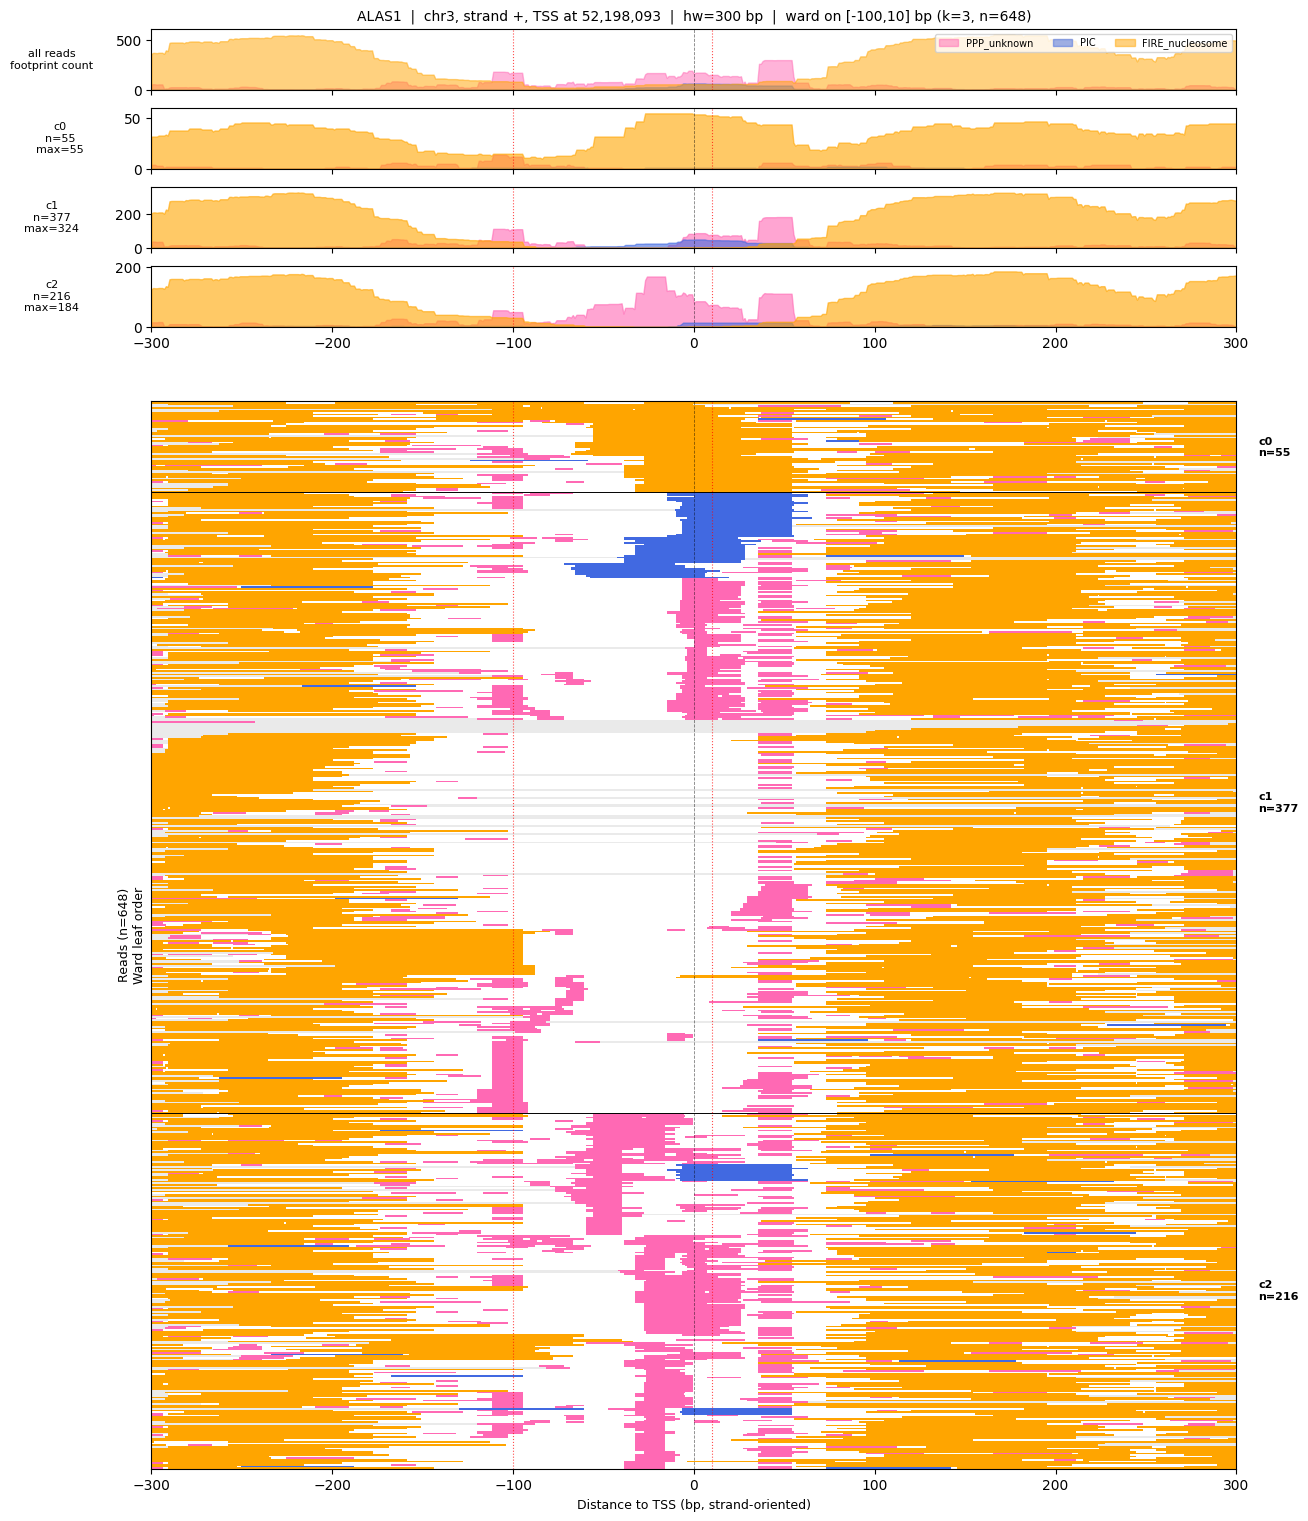

/home/cshan/ipykernel_3839657/3880104023.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ENO1_hw300_tss_proximal_ward_cluster_panels_k3.pdf


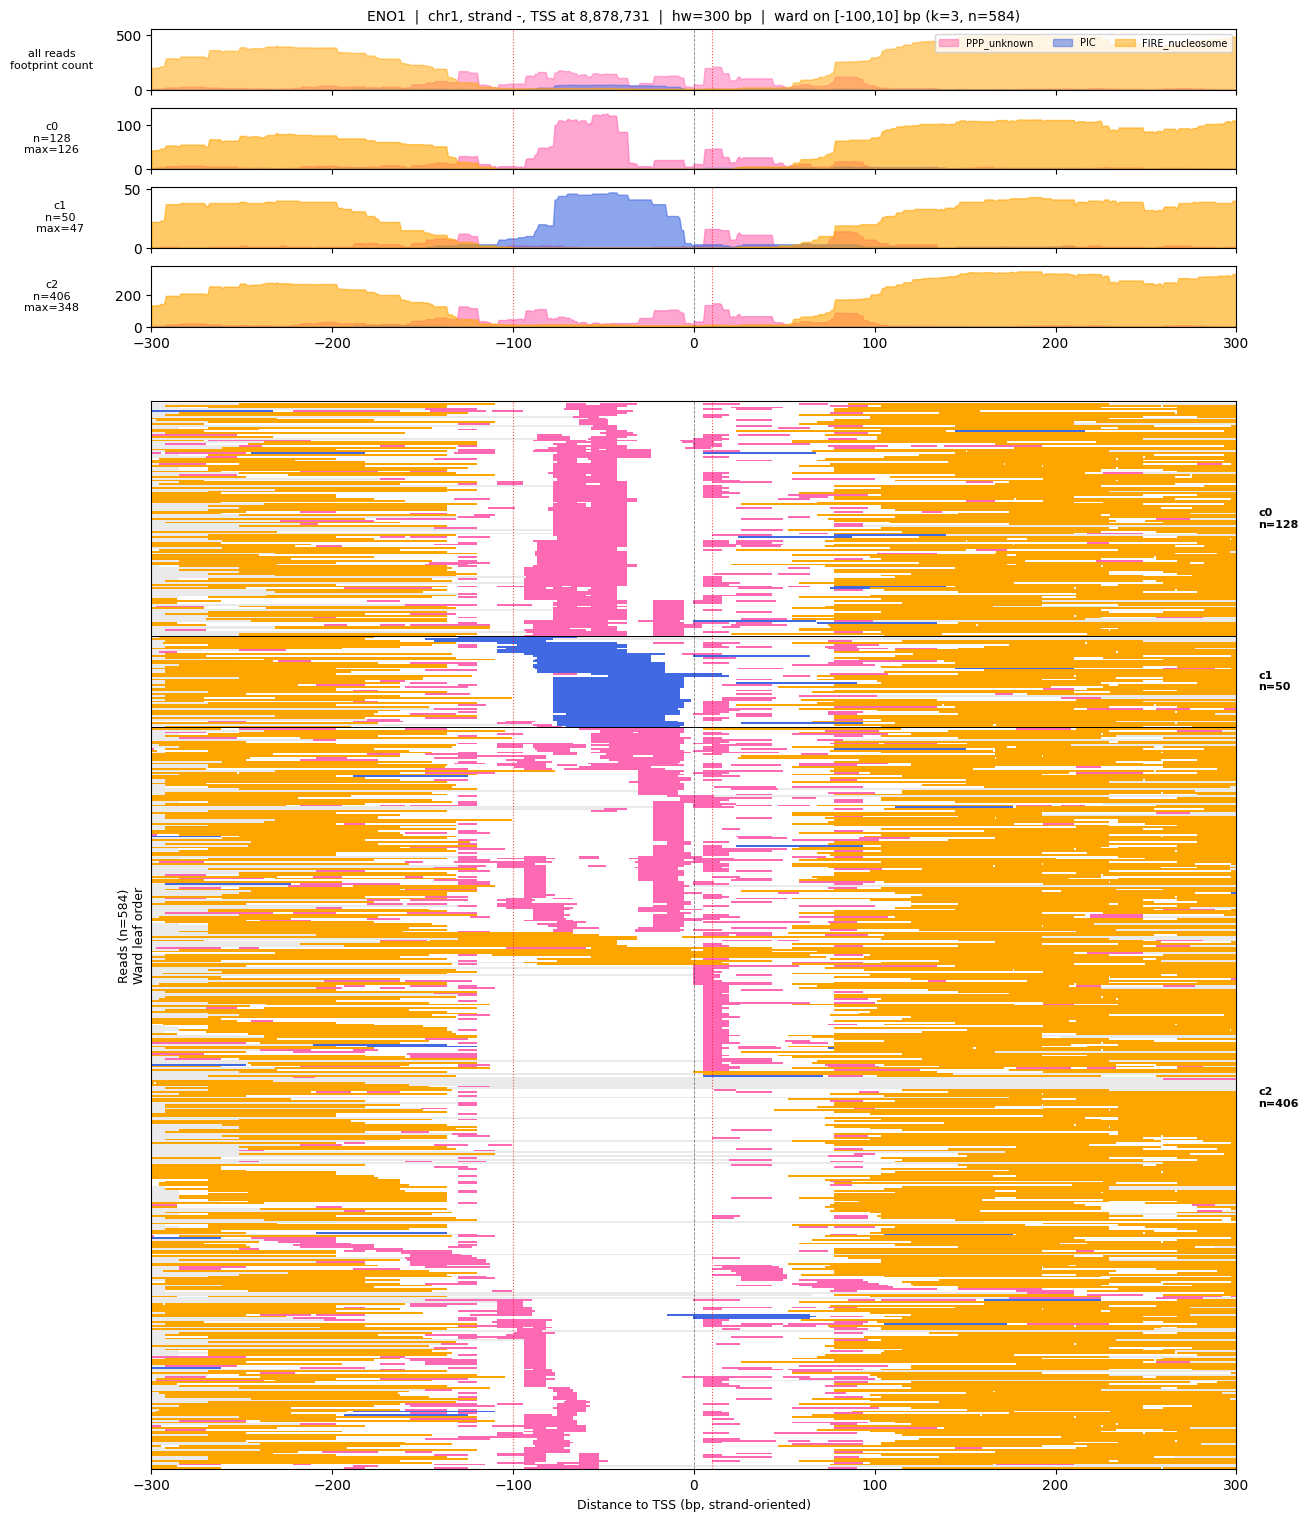

/home/cshan/ipykernel_3839657/3880104023.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ZCWPW1_hw300_tss_proximal_ward_cluster_panels_k2.pdf


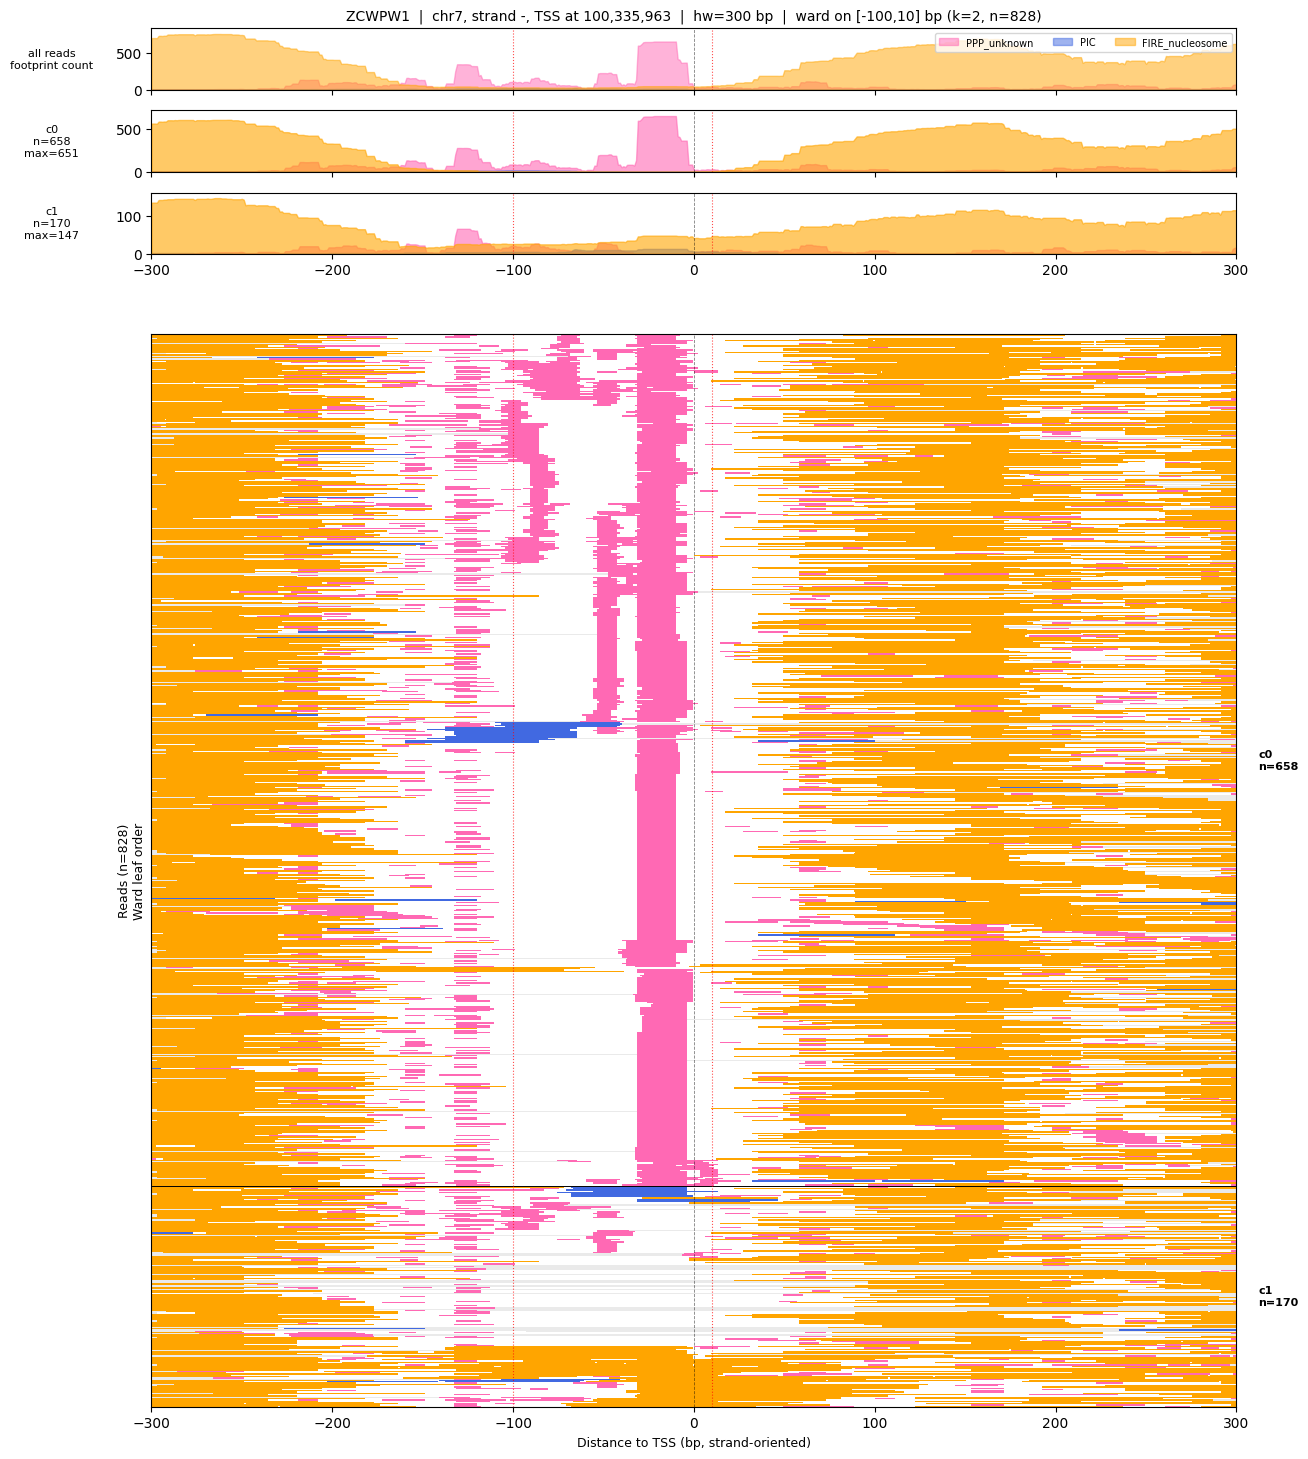

In [31]:
def plot_tss_proximal_panels(gene_name, res):
    occ        = res["occ"]
    aligned    = res["aligned"]
    classes    = res["classes"]
    chrom      = res["chrom"]
    strand     = res["strand"]
    tss        = res["tss"]
    hw         = res["hw"]
    k          = res["k"]
    labels     = res["labels"]
    leaf_order = res["leaf_order"]
    method     = res["method"]
    n_classes, n_reads, n_pos = occ.shape
    rel_pos    = np.arange(-hw, hw + 1)

    sizes = {c: int((labels == c).sum()) for c in range(k)}
    present_clusters = [c for c in range(k) if sizes[c] > 0]

    profiles = {}
    for cluster_id in range(k):
        cluster_mask = (labels == cluster_id)
        profiles[cluster_id] = {}
        for ci, cls in enumerate(classes):
            if cluster_mask.sum() == 0:
                profiles[cluster_id][cls] = np.zeros(n_pos)
            else:
                profiles[cluster_id][cls] = occ[ci, cluster_mask].sum(axis=0)

    combined = {cls: occ[ci].sum(axis=0) for ci, cls in enumerate(classes)}
    combined_ymax = max((v.max() for v in combined.values()), default=1.0)
    combined_ymax = max(combined_ymax, 1.0)

    order = np.asarray(leaf_order, dtype=int)
    labels_sorted = labels[order]

    img = np.tile(np.array(WHITE_RGB, dtype=np.float32), (n_reads, n_pos, 1))
    img[~aligned] = UNCOVERED_RGB
    for ci, cls in enumerate(classes):
        if cls not in TSS_FP_COLORS:
            continue
        rgb  = np.array(mcolors.to_rgb(TSS_FP_COLORS[cls]), dtype=np.float32)
        mask = occ[ci] > 0
        img[mask] = rgb
    img_sorted = img[order]

    n_top_tracks = len(present_clusters) + 1
    bot_height   = min(14.0, max(3.5, 0.05 * n_reads))
    spacer       = 0.5
    fig_height   = 0.8 * n_top_tracks + bot_height + spacer + 1.0

    fig = plt.figure(figsize=(14, fig_height))
    gs = plt.GridSpec(
        n_top_tracks + 2, 1,
        height_ratios=[0.8] * n_top_tracks + [spacer] + [bot_height],
        hspace=0.08,
    )
    ax_combined = fig.add_subplot(gs[0])
    per_cluster_axes = {
        c: fig.add_subplot(gs[1 + i], sharex=ax_combined)
        for i, c in enumerate(present_clusters)
    }
    ax_bot = fig.add_subplot(gs[n_top_tracks + 1], sharex=ax_combined)
    all_axes = [ax_combined] + list(per_cluster_axes.values()) + [ax_bot]

    for cls in classes:
        if cls not in TSS_FP_COLORS:
            continue
        ax_combined.fill_between(rel_pos, 0, combined[cls],
                                 color=TSS_FP_COLORS[cls], alpha=0.5, label=cls)
    ax_combined.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax_combined.set_xlim(-hw, hw)
    ax_combined.set_ylim(0, combined_ymax * 1.1)
    ax_combined.set_ylabel("all reads\nfootprint count", fontsize=8,
                           rotation=0, labelpad=46, va="center")
    ax_combined.set_title(
        f"{gene_name}  |  {chrom}, strand {strand}, TSS at {tss:,}  |  "
        f"hw={hw} bp  |  {method} on [{CLUSTER_REL_START},{CLUSTER_REL_END}] bp "
        f"(k={k}, n={n_reads})",
        fontsize=10,
    )
    ax_combined.legend(loc="upper right", fontsize=7, ncol=min(n_classes, 5))
    plt.setp(ax_combined.get_xticklabels(), visible=False)

    last_idx = len(present_clusters) - 1
    for i, cluster_id in enumerate(present_clusters):
        ax = per_cluster_axes[cluster_id]
        for cls in classes:
            if cls not in TSS_FP_COLORS:
                continue
            ax.fill_between(rel_pos, 0, profiles[cluster_id][cls],
                            color=TSS_FP_COLORS[cls], alpha=0.6)
        ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
        ax.set_xlim(-hw, hw)
        cluster_ymax = max(
            (profiles[cluster_id][cls].max() for cls in classes if cls in TSS_FP_COLORS),
            default=1.0,
        )
        cluster_ymax = max(cluster_ymax, 1.0)
        ax.set_ylim(0, cluster_ymax * 1.1)
        ax.set_ylabel(
            f"c{cluster_id}\nn={sizes[cluster_id]}\nmax={int(cluster_ymax)}",
            fontsize=8, rotation=0, labelpad=46, va="center",
        )
        if i < last_idx:
            plt.setp(ax.get_xticklabels(), visible=False)

    ax_bot.imshow(img_sorted, aspect="auto", interpolation="nearest",
                  extent=[-hw - 0.5, hw + 0.5, n_reads, 0])
    ax_bot.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    boundaries = np.where(np.diff(labels_sorted) != 0)[0] + 1
    for b in boundaries:
        ax_bot.axhline(b - 0.5, color="black", lw=0.7)
    label_x = hw + (2 * hw) * 0.02
    for c in present_clusters:
        idx = np.where(labels_sorted == c)[0]
        if len(idx):
            ax_bot.text(label_x, (idx.min() + idx.max()) / 2,
                        f"c{c}\nn={sizes[c]}", fontsize=8, va="center",
                        color="black", fontweight="bold")

    for ax in all_axes:
        ax.axvline(CLUSTER_REL_START, color="red", lw=0.8, ls=":", alpha=0.7)
        ax.axvline(CLUSTER_REL_END, color="red", lw=0.8, ls=":", alpha=0.7)

    ax_bot.set_xlim(-hw, hw)
    ax_bot.set_ylim(n_reads, -1)
    ax_bot.set_yticks([])
    order_label = "Ward leaf order" if method == "ward" else "k-means order"
    ax_bot.set_ylabel(f"Reads (n={n_reads})\n{order_label}", fontsize=9)
    ax_bot.set_xlabel("Distance to TSS (bp, strand-oriented)", fontsize=9)

    plt.tight_layout()
    out_pdf = TSS_OUT_ROOT / f"{gene_name}_hw{hw}_tss_proximal_{method}_cluster_panels_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


for gene_name, res in tss_cluster_results.items():
    plot_tss_proximal_panels(gene_name, res)

### 4. Per-class clustering on the same TSS-proximal region.

Same `[-100, +10]` bp clustering region and `hw=300` bp display window, but
this time clustering is driven by **one footprint class at a time**: only
that class's binned occupancy columns are used as features. Other classes
still appear in the plot but contribute nothing to the row ordering.
Uses whichever `CLUSTER_METHOD` is set (`"ward"` or `"kmeans").

In [27]:
tss_sc_cluster_results = {}

for driving_cls in FP_CLASSES:
    driving_ci = FP_CLASSES.index(driving_cls)

    for gene_name, info in tss_matrices.items():
        occ = info["occ"]
        n_classes, n_reads, n_pos = occ.shape

        if n_reads < 2:
            print(f"{gene_name}: only {n_reads} reads, skipping {driving_cls}")
            continue

        region = occ[driving_ci][:, col_start:col_end]
        X_single = _tss_bin_smooth_mean(region, TSS_BIN_BP)

        if CLUSTER_METHOD == "ward":
            Z = linkage(X_single, method="ward")
            leaf_order = leaves_list(Z)
            labels, best_k, cut_height = _tss_ward_elbow_k(Z)
        else:
            labels, best_k, _ = _tss_kmeans_best_k(X_single, K_RANGE)
            Z = None
            positions = np.arange(CLUSTER_REL_START, CLUSTER_REL_END + 1)
            center = np.full(region.shape[0], np.nan)
            for i in range(region.shape[0]):
                if region[i].sum() > 0:
                    center[i] = np.average(positions, weights=region[i])
            center_sort = np.where(np.isnan(center), np.inf, center)
            leaf_order = np.lexsort((center_sort, labels))

        tss_sc_cluster_results[(driving_cls, gene_name)] = {
            **info,
            "driving_class": driving_cls,
            "X":             X_single,
            "linkage":       Z,
            "leaf_order":    leaf_order,
            "labels":        labels,
            "k":             best_k,
            "method":        CLUSTER_METHOD,
        }

        sizes = {c: int((labels == c).sum()) for c in range(best_k)}
        tag = driving_cls.replace(" ", "_").replace("(", "").replace(")", "")
        print(f"=== {gene_name}  cluster on '{driving_cls}' "
              f"(n_reads={n_reads}, region [{CLUSTER_REL_START},{CLUSTER_REL_END}] bp, "
              f"bin={TSS_BIN_BP} bp, method={CLUSTER_METHOD}) ===")
        if CLUSTER_METHOD == "ward":
            print(f"  Ward elbow -> k={best_k}  (cut height {cut_height:.3f})")
        else:
            print(f"  K-means silhouette -> k={best_k}")
        for c, n in sorted(sizes.items()):
            print(f"  c{c}: n={n}")

        np.save(TSS_OUT_ROOT / f"{gene_name}_hw{TSS_HW}_tss_proximal_single_{tag}_{CLUSTER_METHOD}_labels_k{best_k}.npy",
                labels)
        pd.DataFrame({
            "read_id": info["read_ids"],
            "cluster": labels,
        }).to_csv(TSS_OUT_ROOT / f"{gene_name}_hw{TSS_HW}_tss_proximal_single_{tag}_{CLUSTER_METHOD}_clusters_k{best_k}.tsv",
                  sep="\t", index=False)

print(f"\n--- {len(tss_sc_cluster_results)} single-class clustering results stored ---")

=== ALAS1  cluster on 'PPP_unknown' (n_reads=648, region [-100,10] bp, bin=10 bp, method=kmeans) ===
  K-means silhouette -> k=9
  c0: n=33
  c1: n=226
  c2: n=91
  c3: n=62
  c4: n=39
  c5: n=91
  c6: n=42
  c7: n=29
  c8: n=35
=== ENO1  cluster on 'PPP_unknown' (n_reads=584, region [-100,10] bp, bin=10 bp, method=kmeans) ===
  K-means silhouette -> k=9
  c0: n=263
  c1: n=38
  c2: n=59
  c3: n=34
  c4: n=51
  c5: n=21
  c6: n=43
  c7: n=23
  c8: n=52
=== ZCWPW1  cluster on 'PPP_unknown' (n_reads=828, region [-100,10] bp, bin=10 bp, method=kmeans) ===
  K-means silhouette -> k=9
  c0: n=181
  c1: n=147
  c2: n=178
  c3: n=38
  c4: n=52
  c5: n=112
  c6: n=29
  c7: n=30
  c8: n=61
=== ALAS1  cluster on 'PIC' (n_reads=648, region [-100,10] bp, bin=10 bp, method=kmeans) ===
  K-means silhouette -> k=7
  c0: n=580
  c1: n=8
  c2: n=40
  c3: n=6
  c4: n=9
  c5: n=2
  c6: n=3
=== ENO1  cluster on 'PIC' (n_reads=584, region [-100,10] bp, bin=10 bp, method=kmeans) ===
  K-means silhouette -> 

### 5. Per-cluster plots driven by each single class.

Same three-part layout as section 3 (combined overlay, per-cluster
overlays, and per-read heatmap), one figure per `(driving_class, gene)`. The
driving class is named in the title; all three classes are drawn but row
order and cluster assignments come from the driving class alone. Red
dotted lines mark the `[-100, +10]` bp clustering region.

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ALAS1_hw300_tss_proximal_single_PPP_unknown_kmeans_cluster_panels_k9.pdf


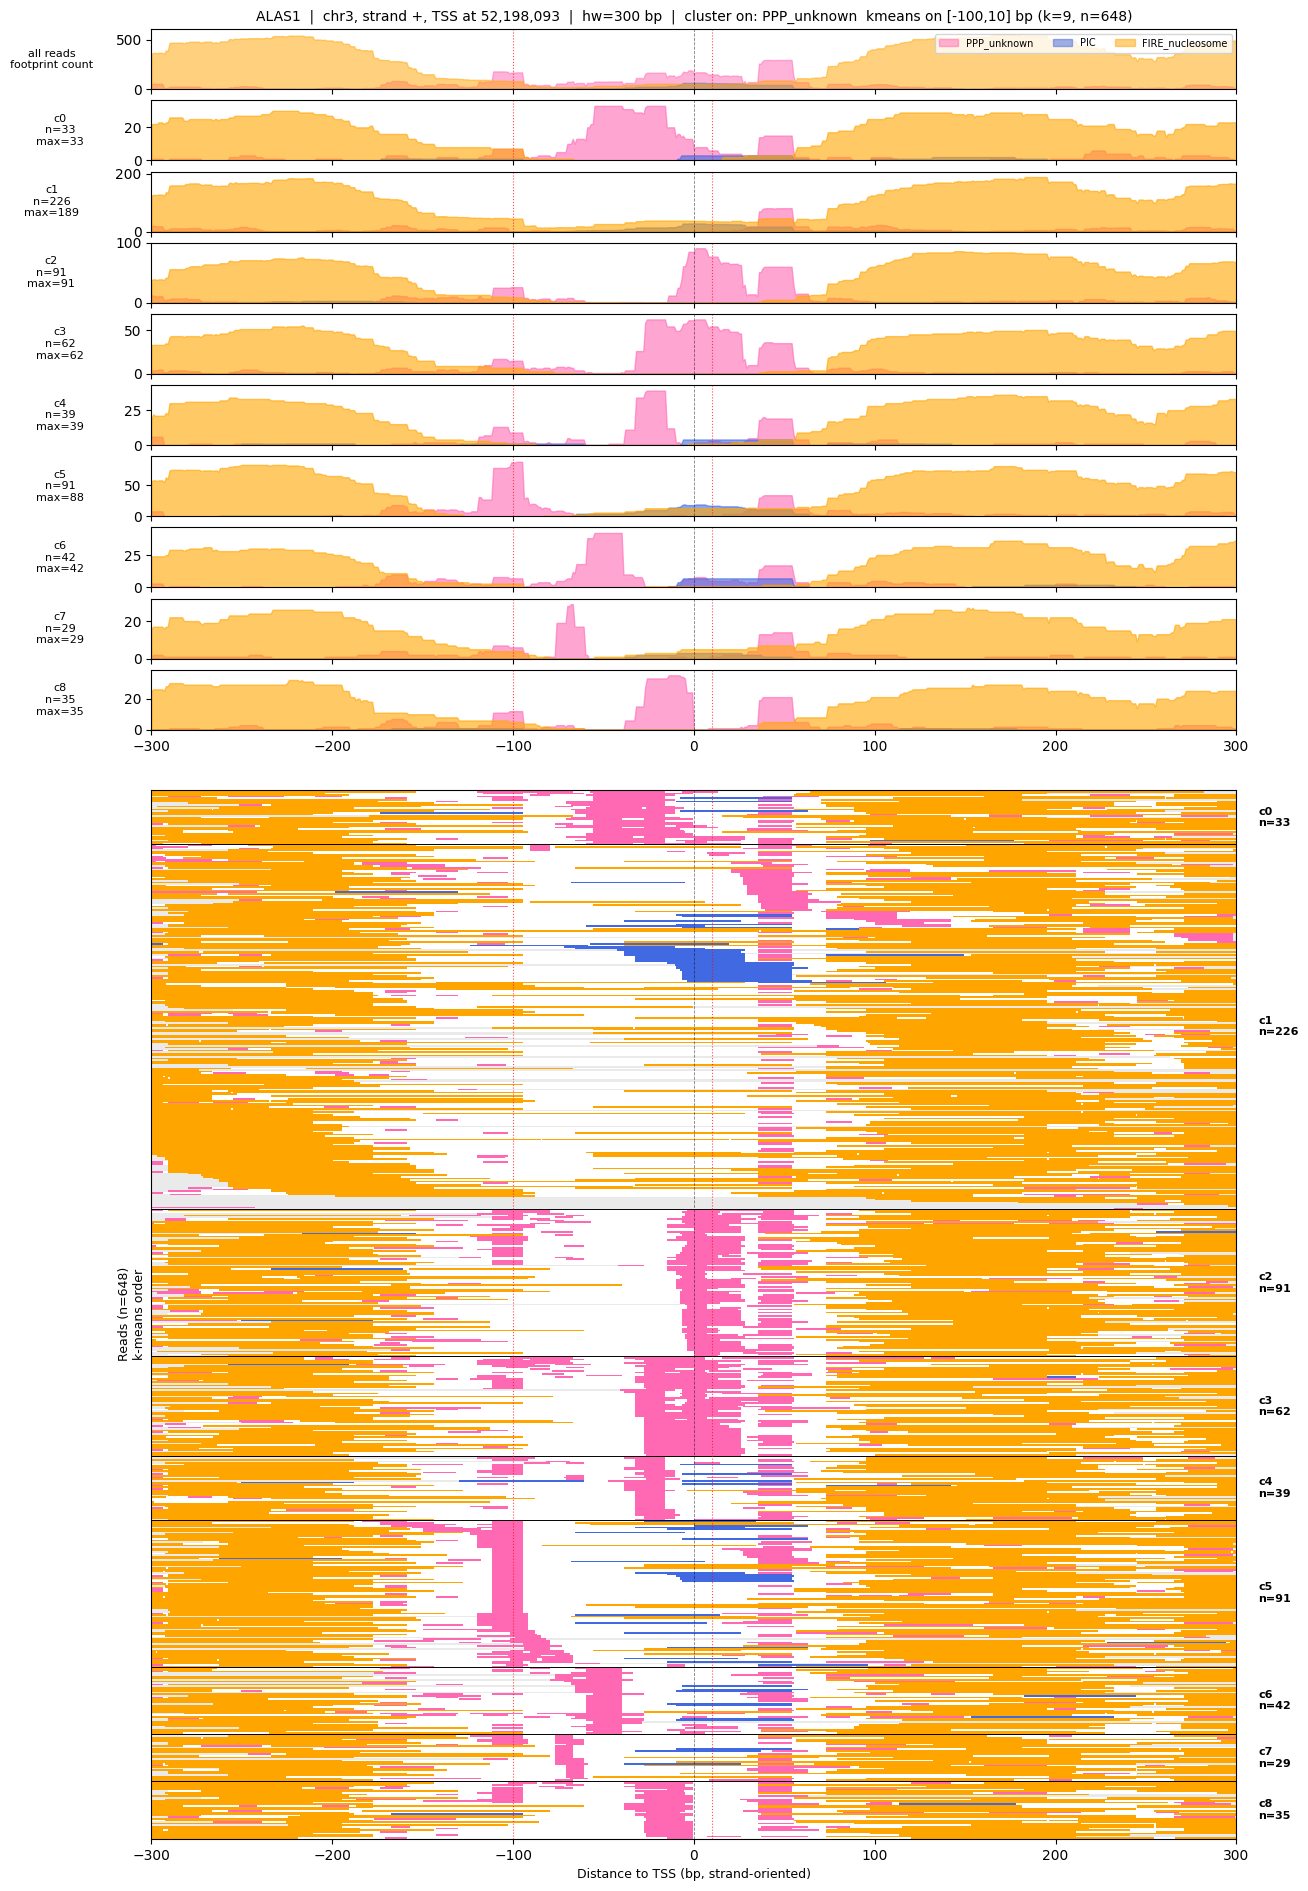

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ENO1_hw300_tss_proximal_single_PPP_unknown_kmeans_cluster_panels_k9.pdf


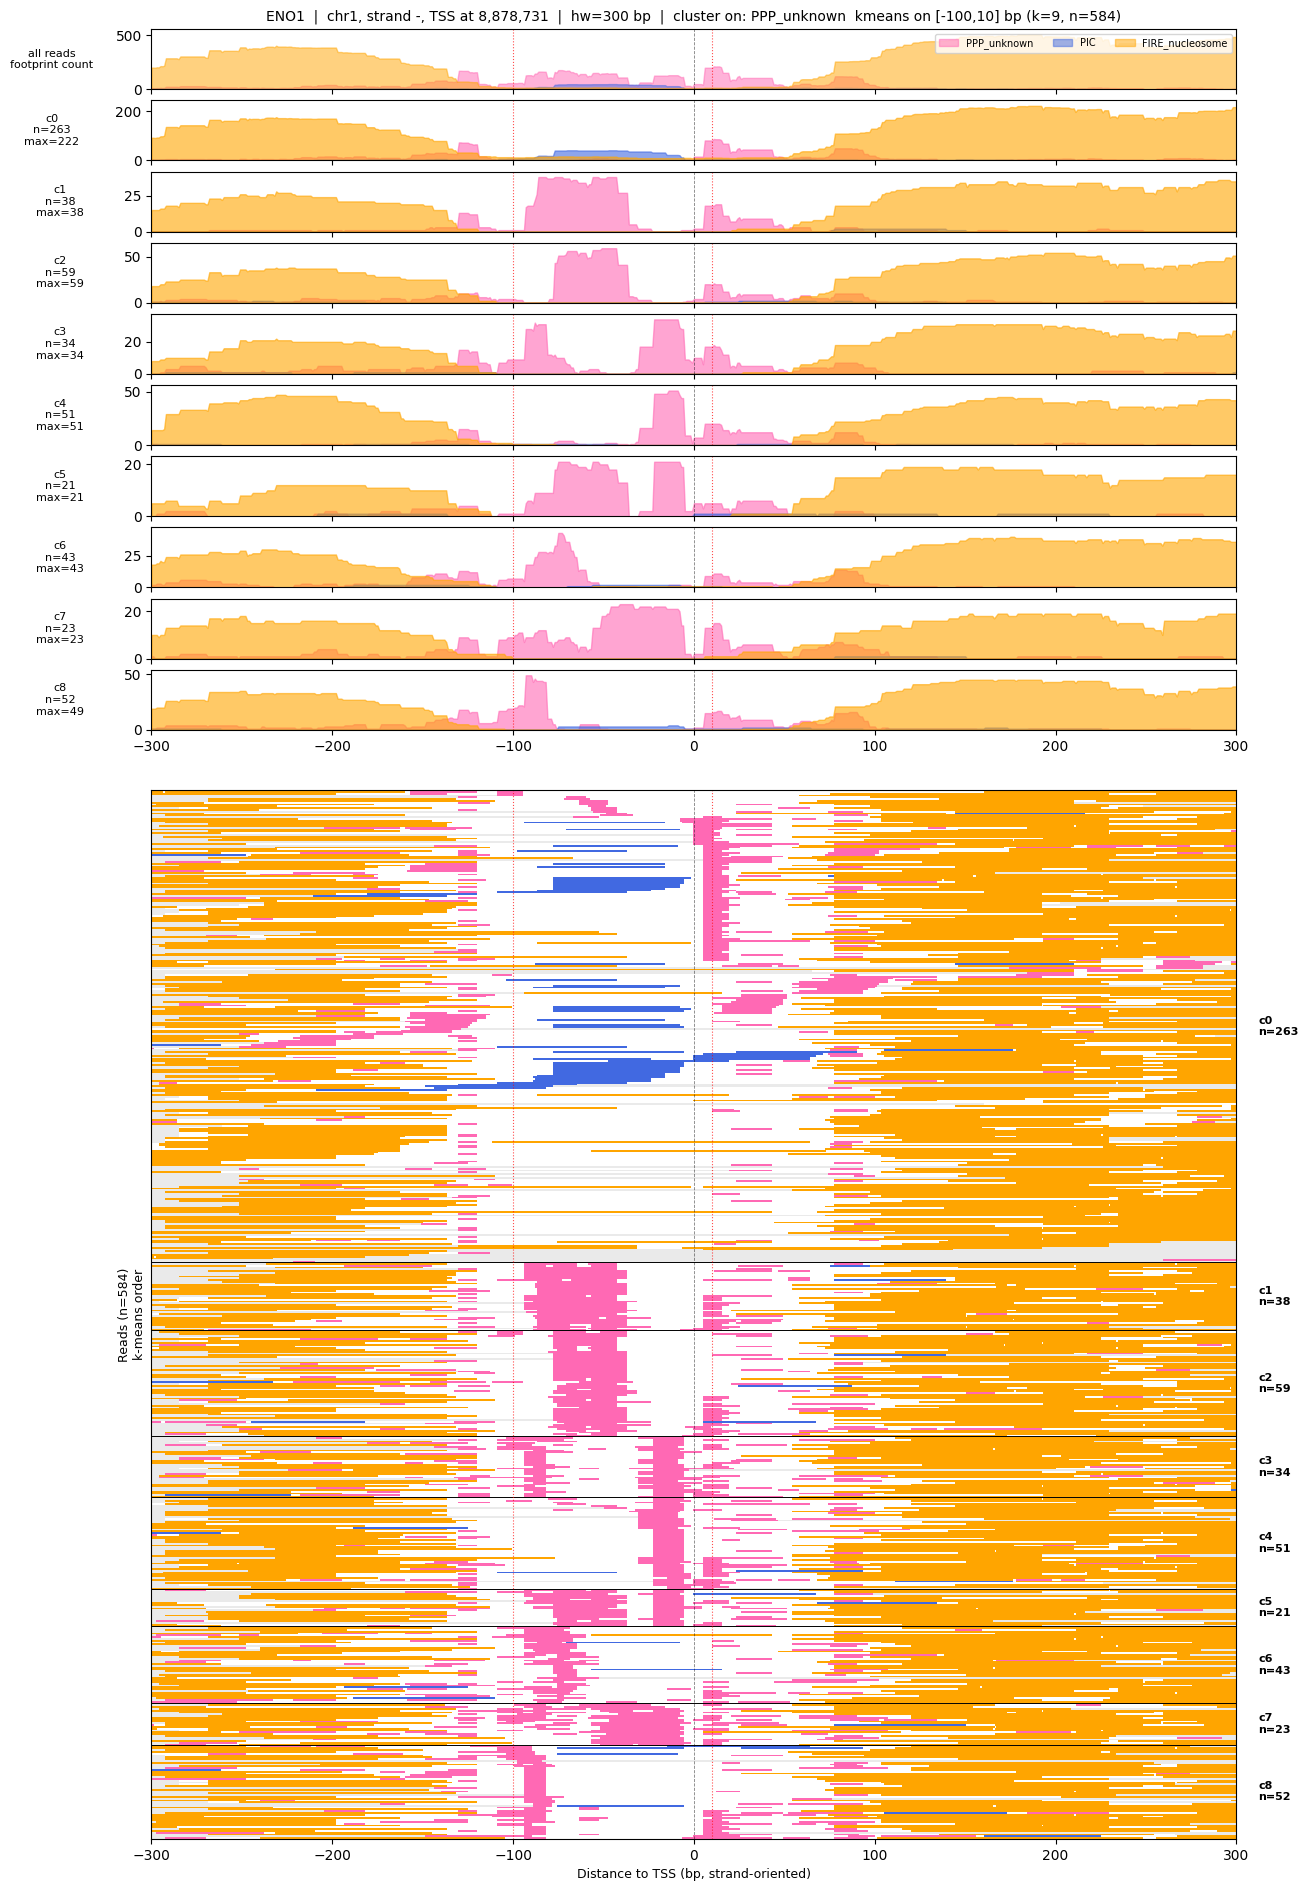

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ZCWPW1_hw300_tss_proximal_single_PPP_unknown_kmeans_cluster_panels_k9.pdf


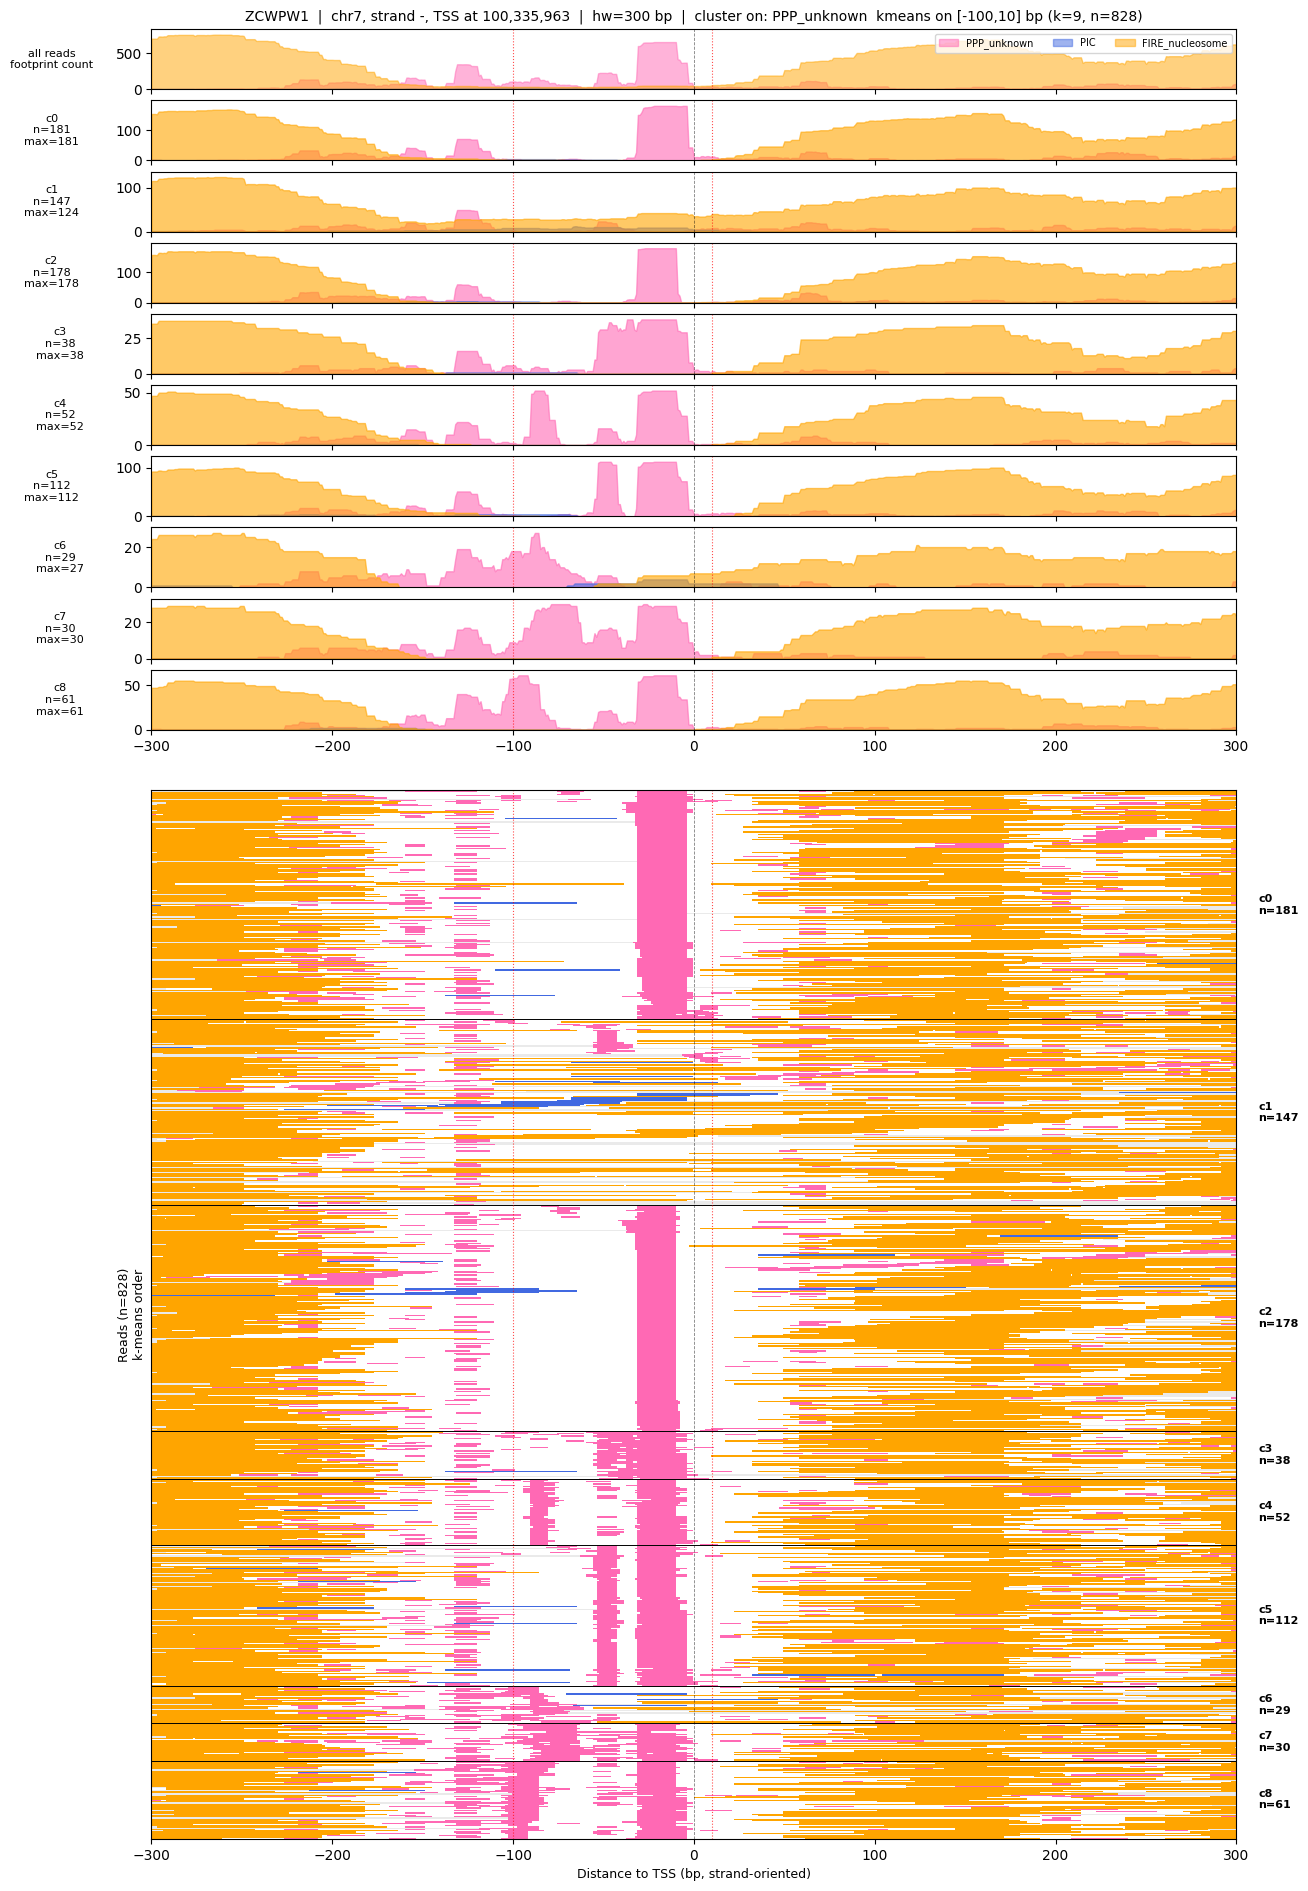

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ALAS1_hw300_tss_proximal_single_PIC_kmeans_cluster_panels_k7.pdf


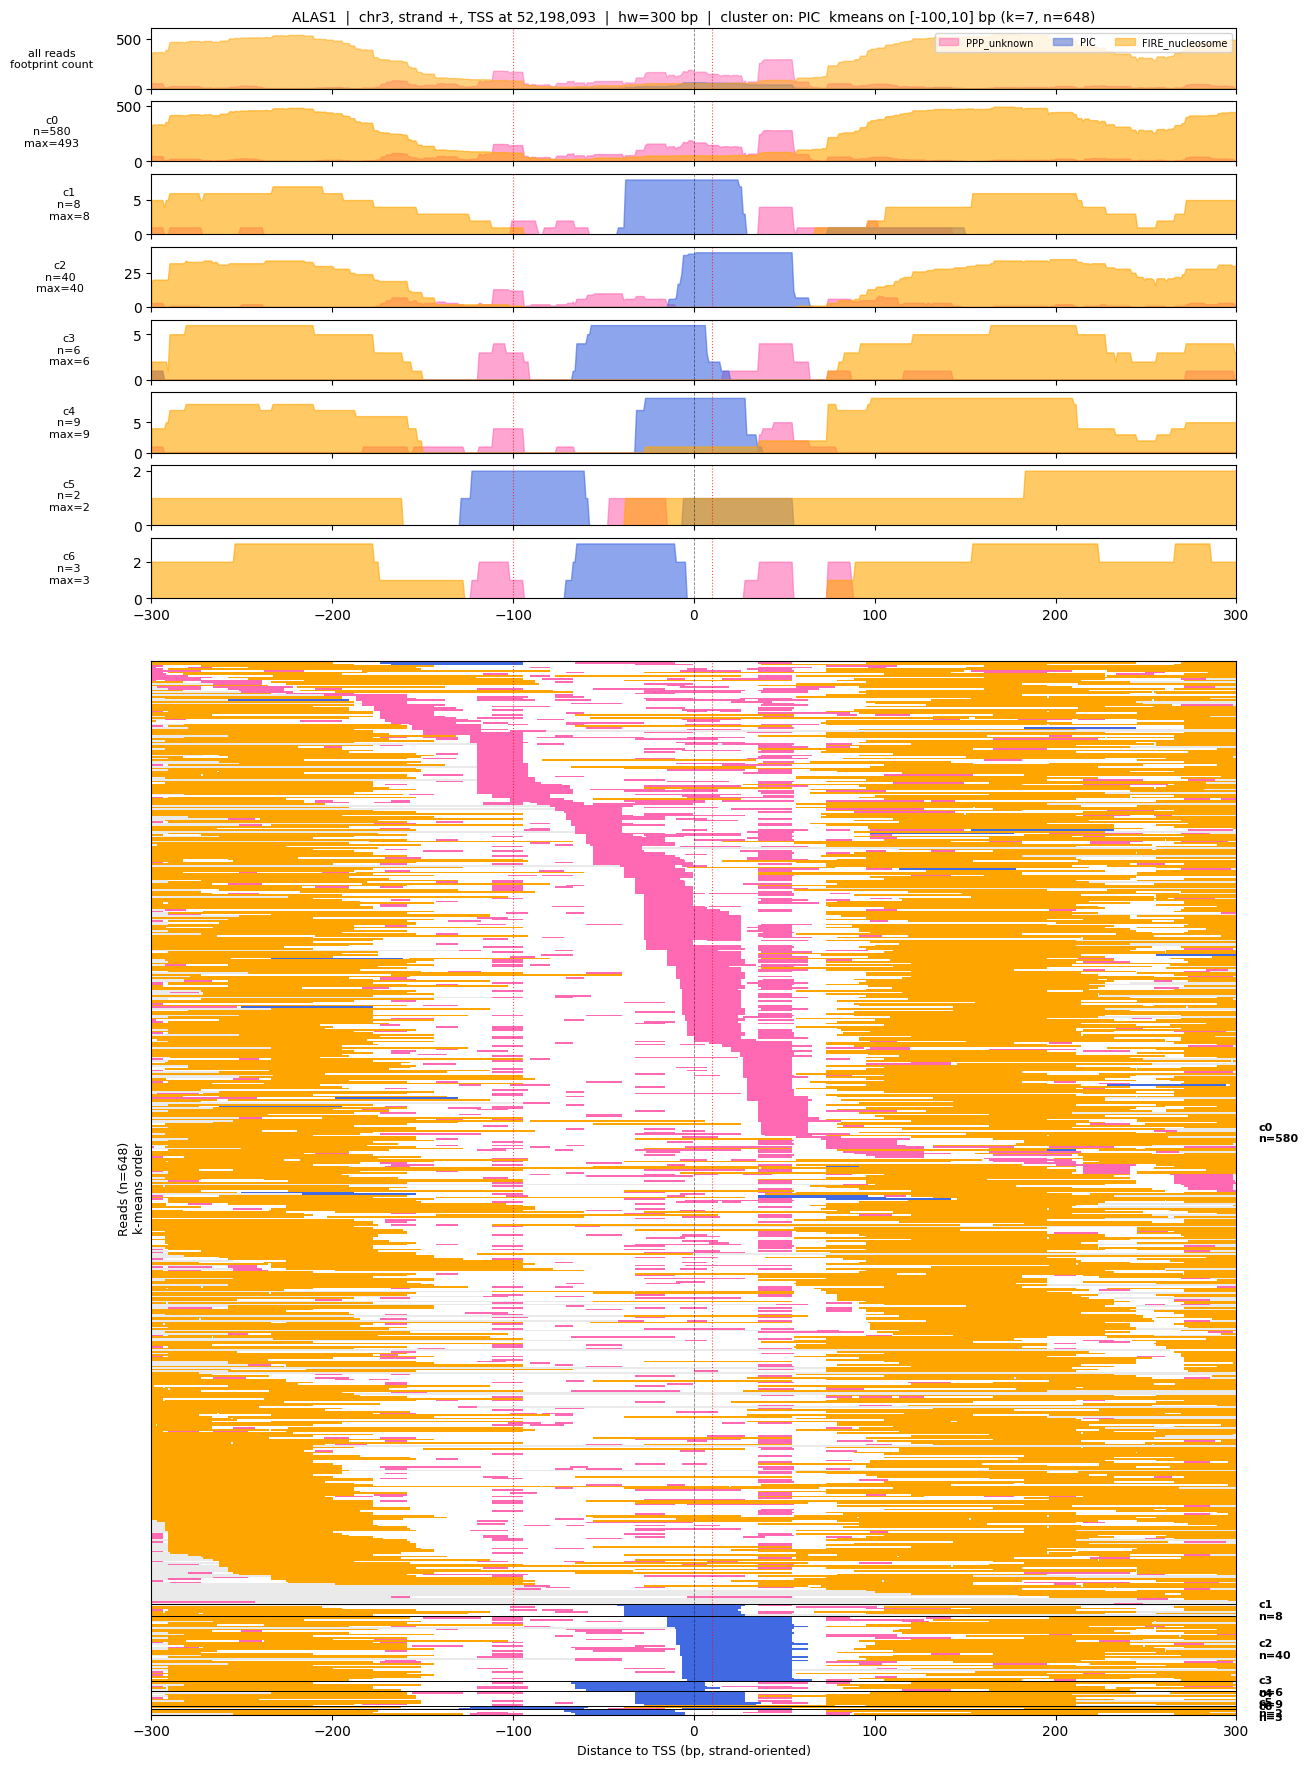

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ENO1_hw300_tss_proximal_single_PIC_kmeans_cluster_panels_k7.pdf


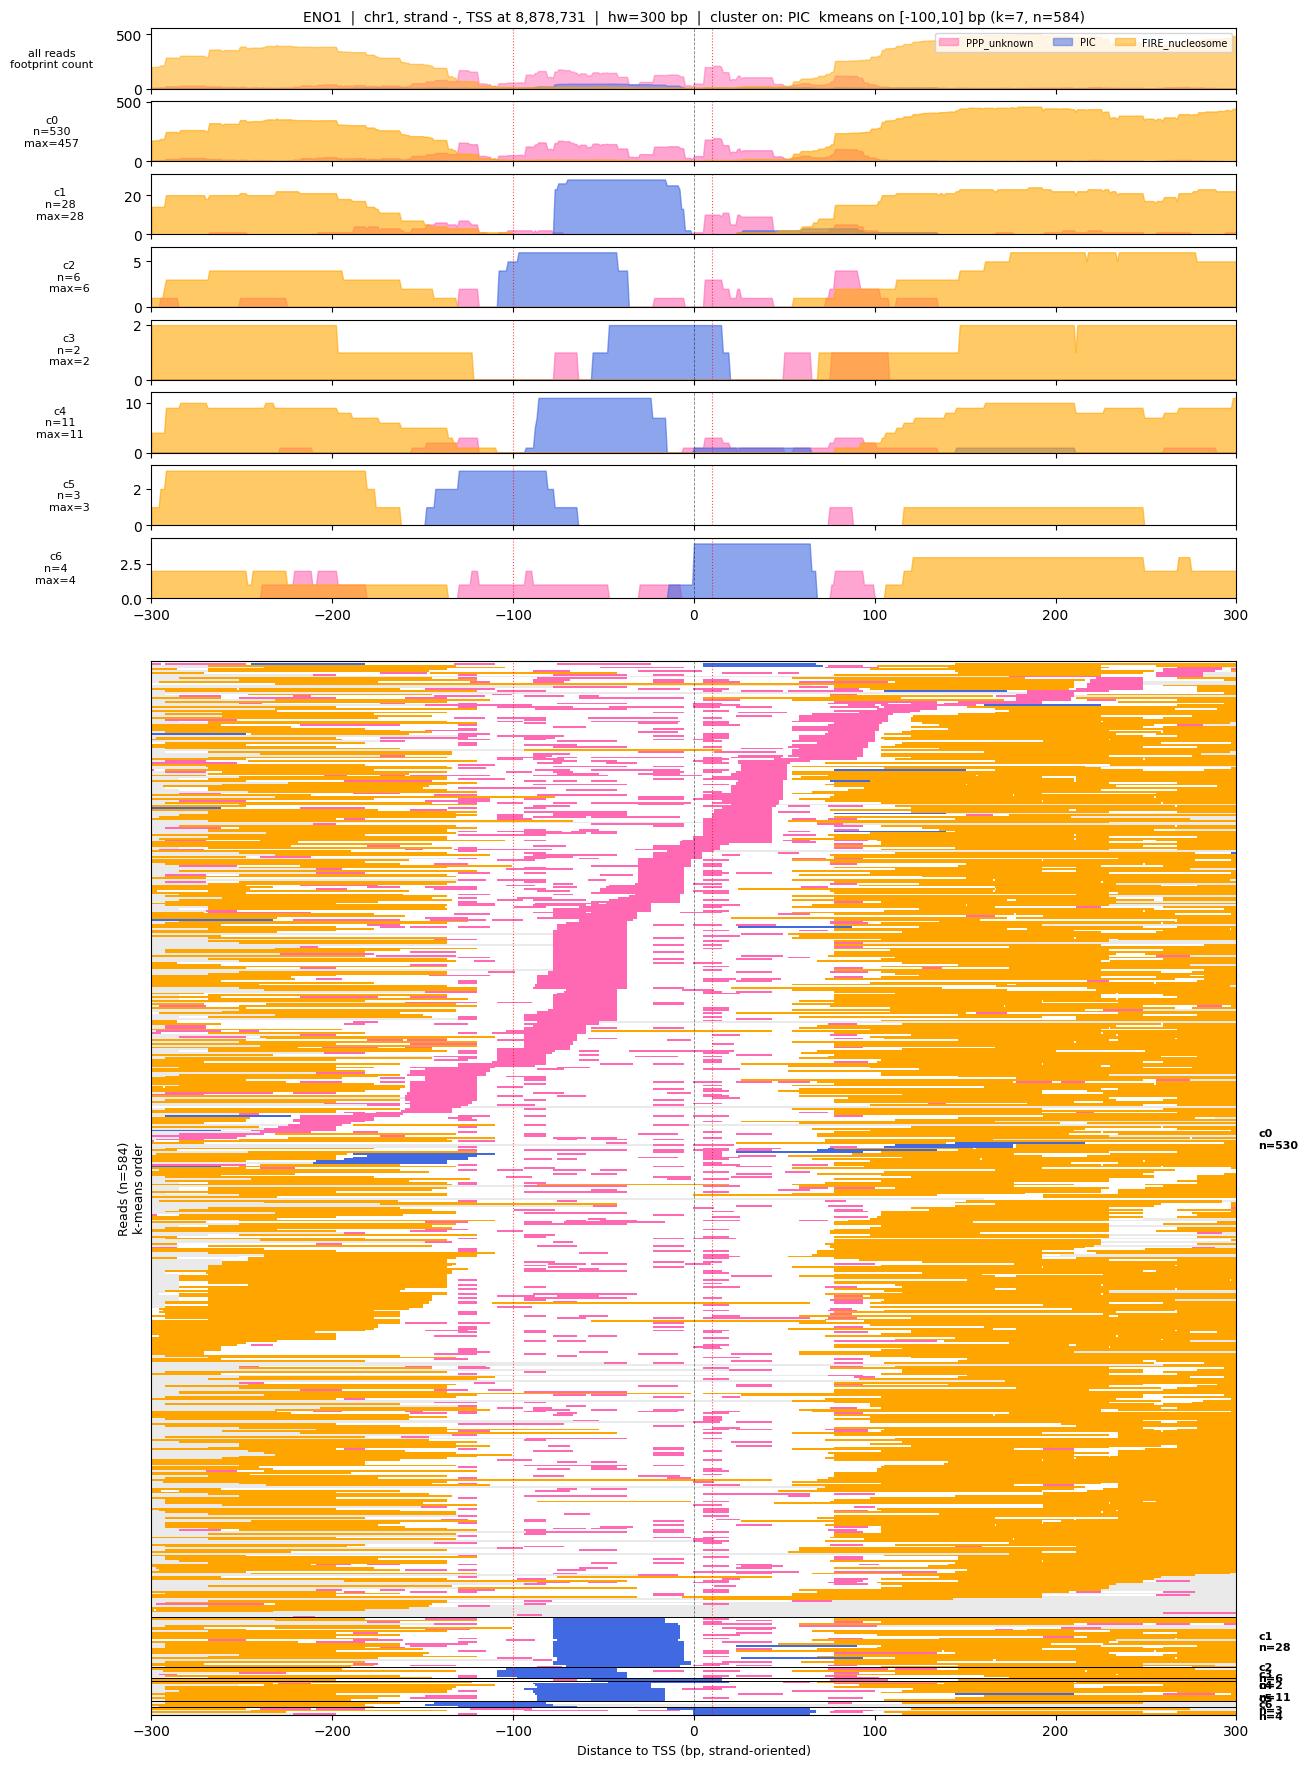

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ZCWPW1_hw300_tss_proximal_single_PIC_kmeans_cluster_panels_k8.pdf


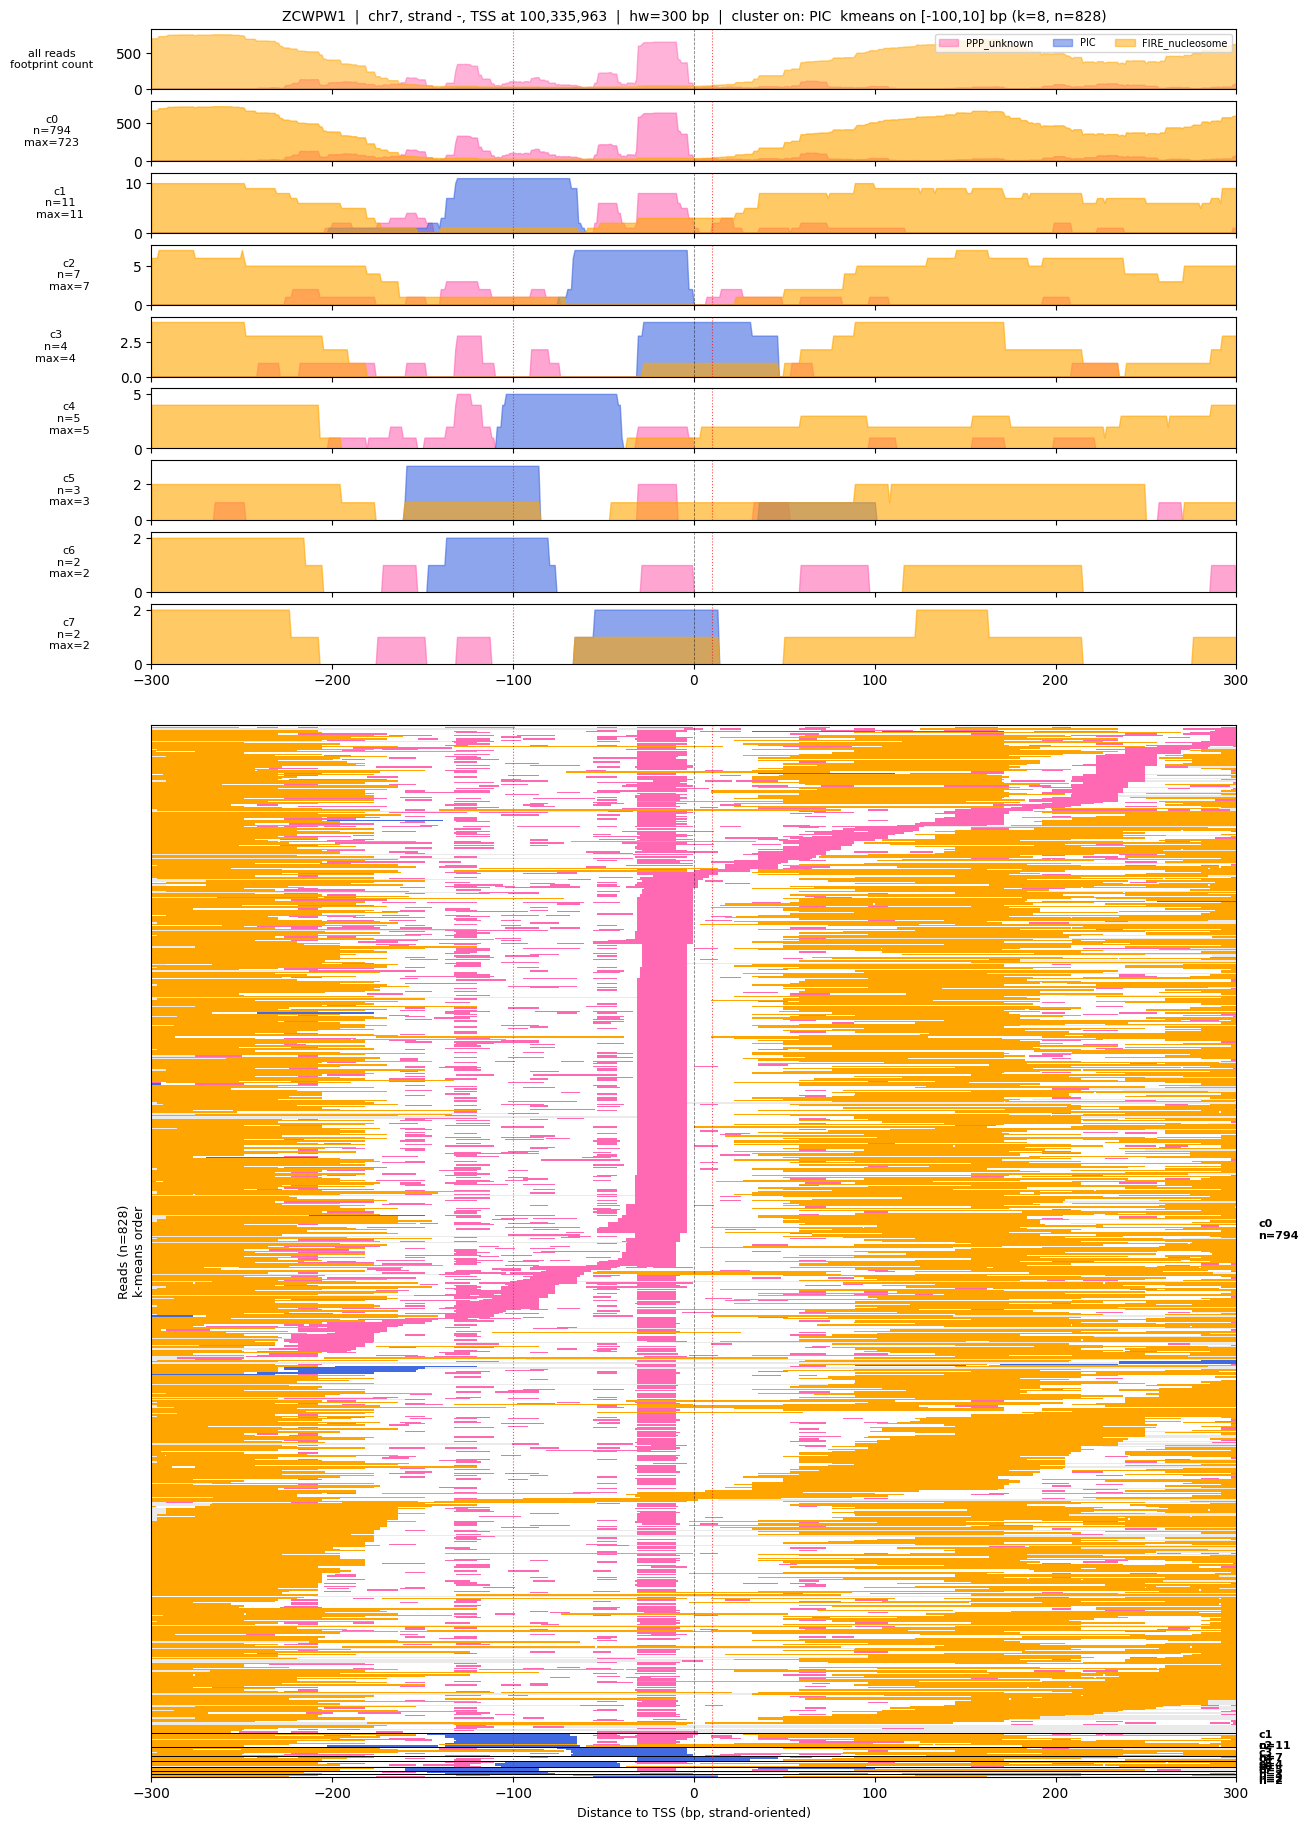

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ALAS1_hw300_tss_proximal_single_FIRE_nucleosome_kmeans_cluster_panels_k9.pdf


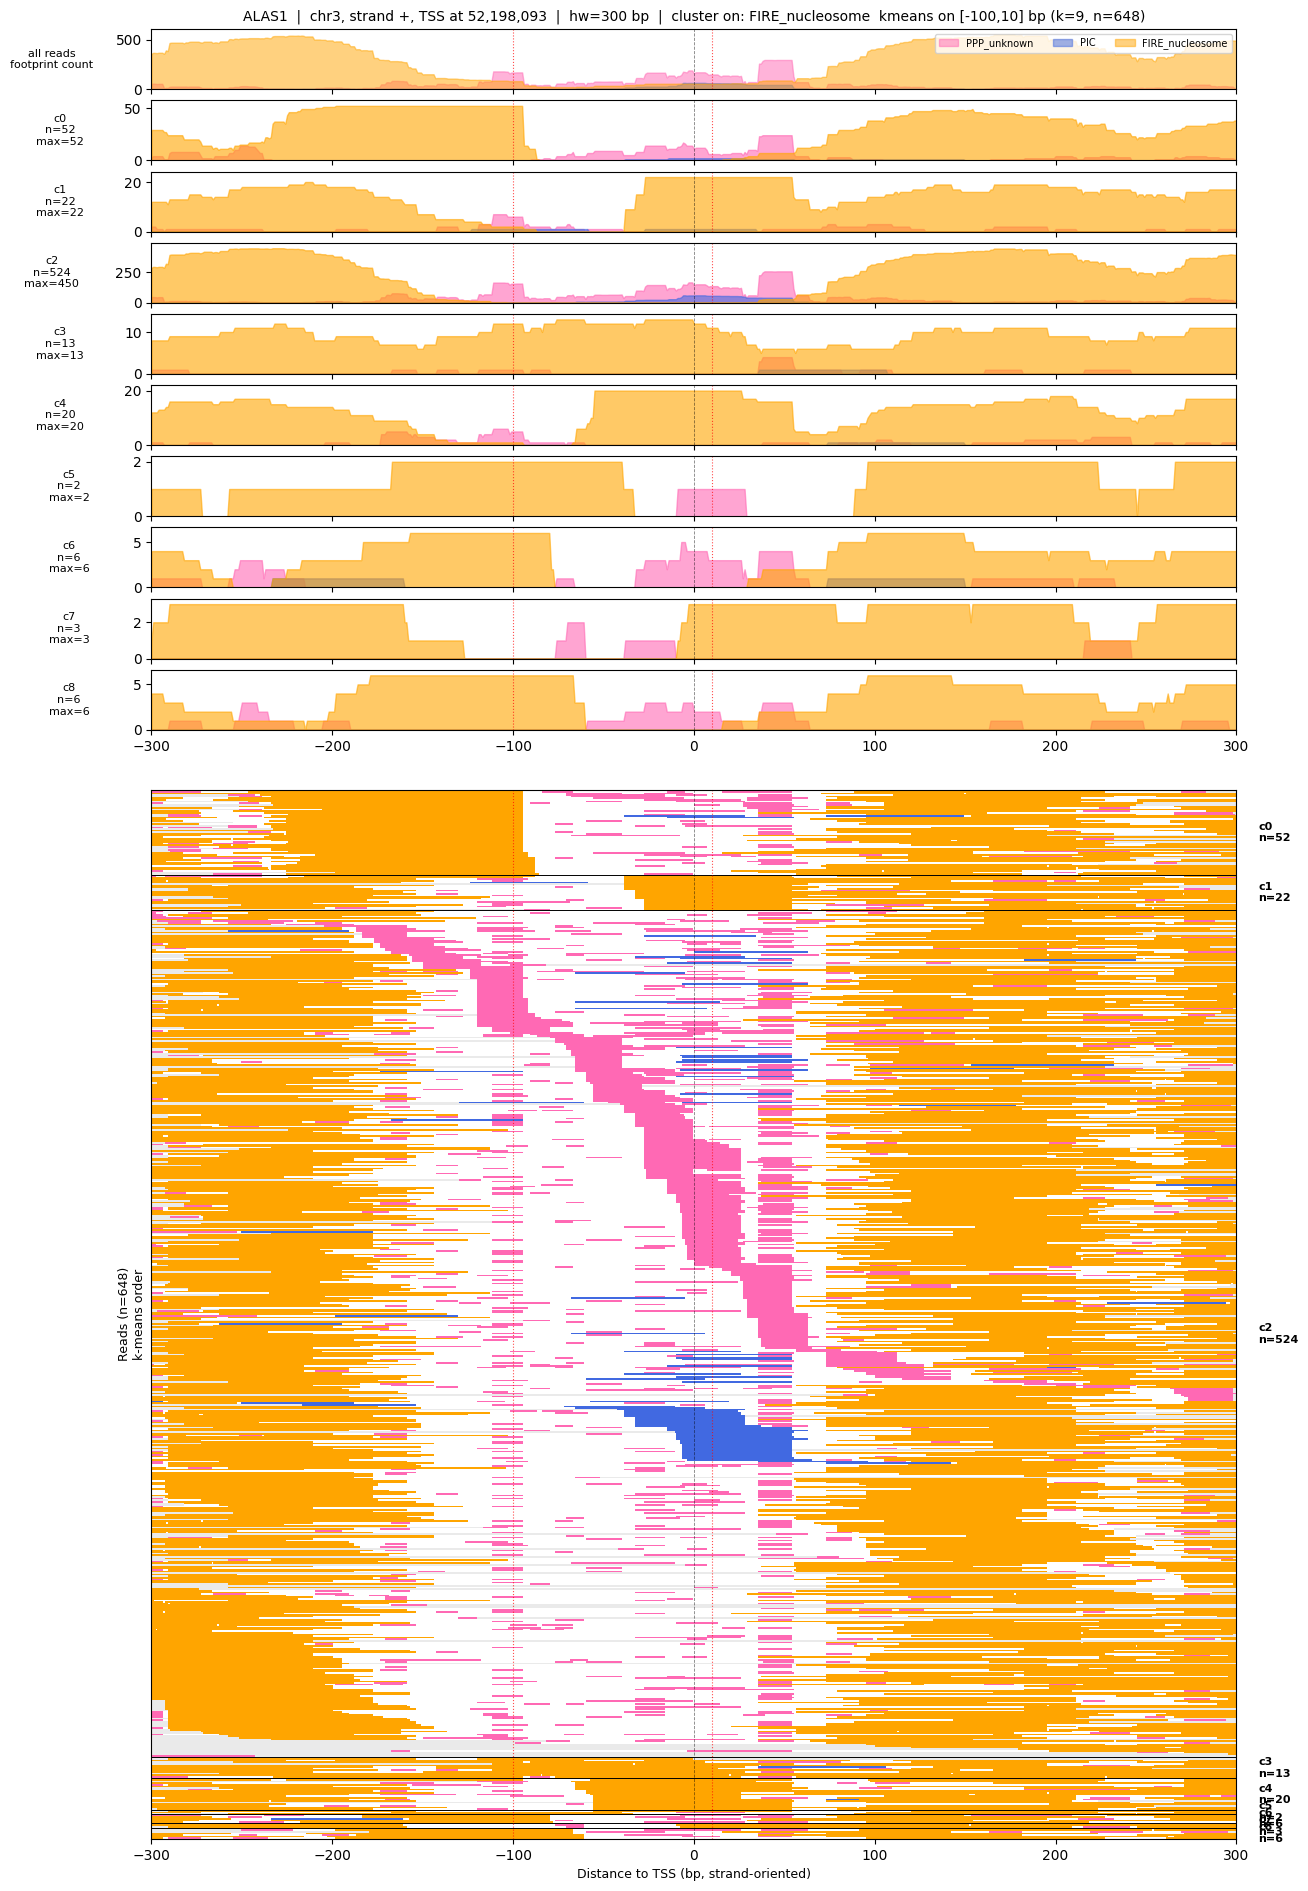

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ENO1_hw300_tss_proximal_single_FIRE_nucleosome_kmeans_cluster_panels_k8.pdf


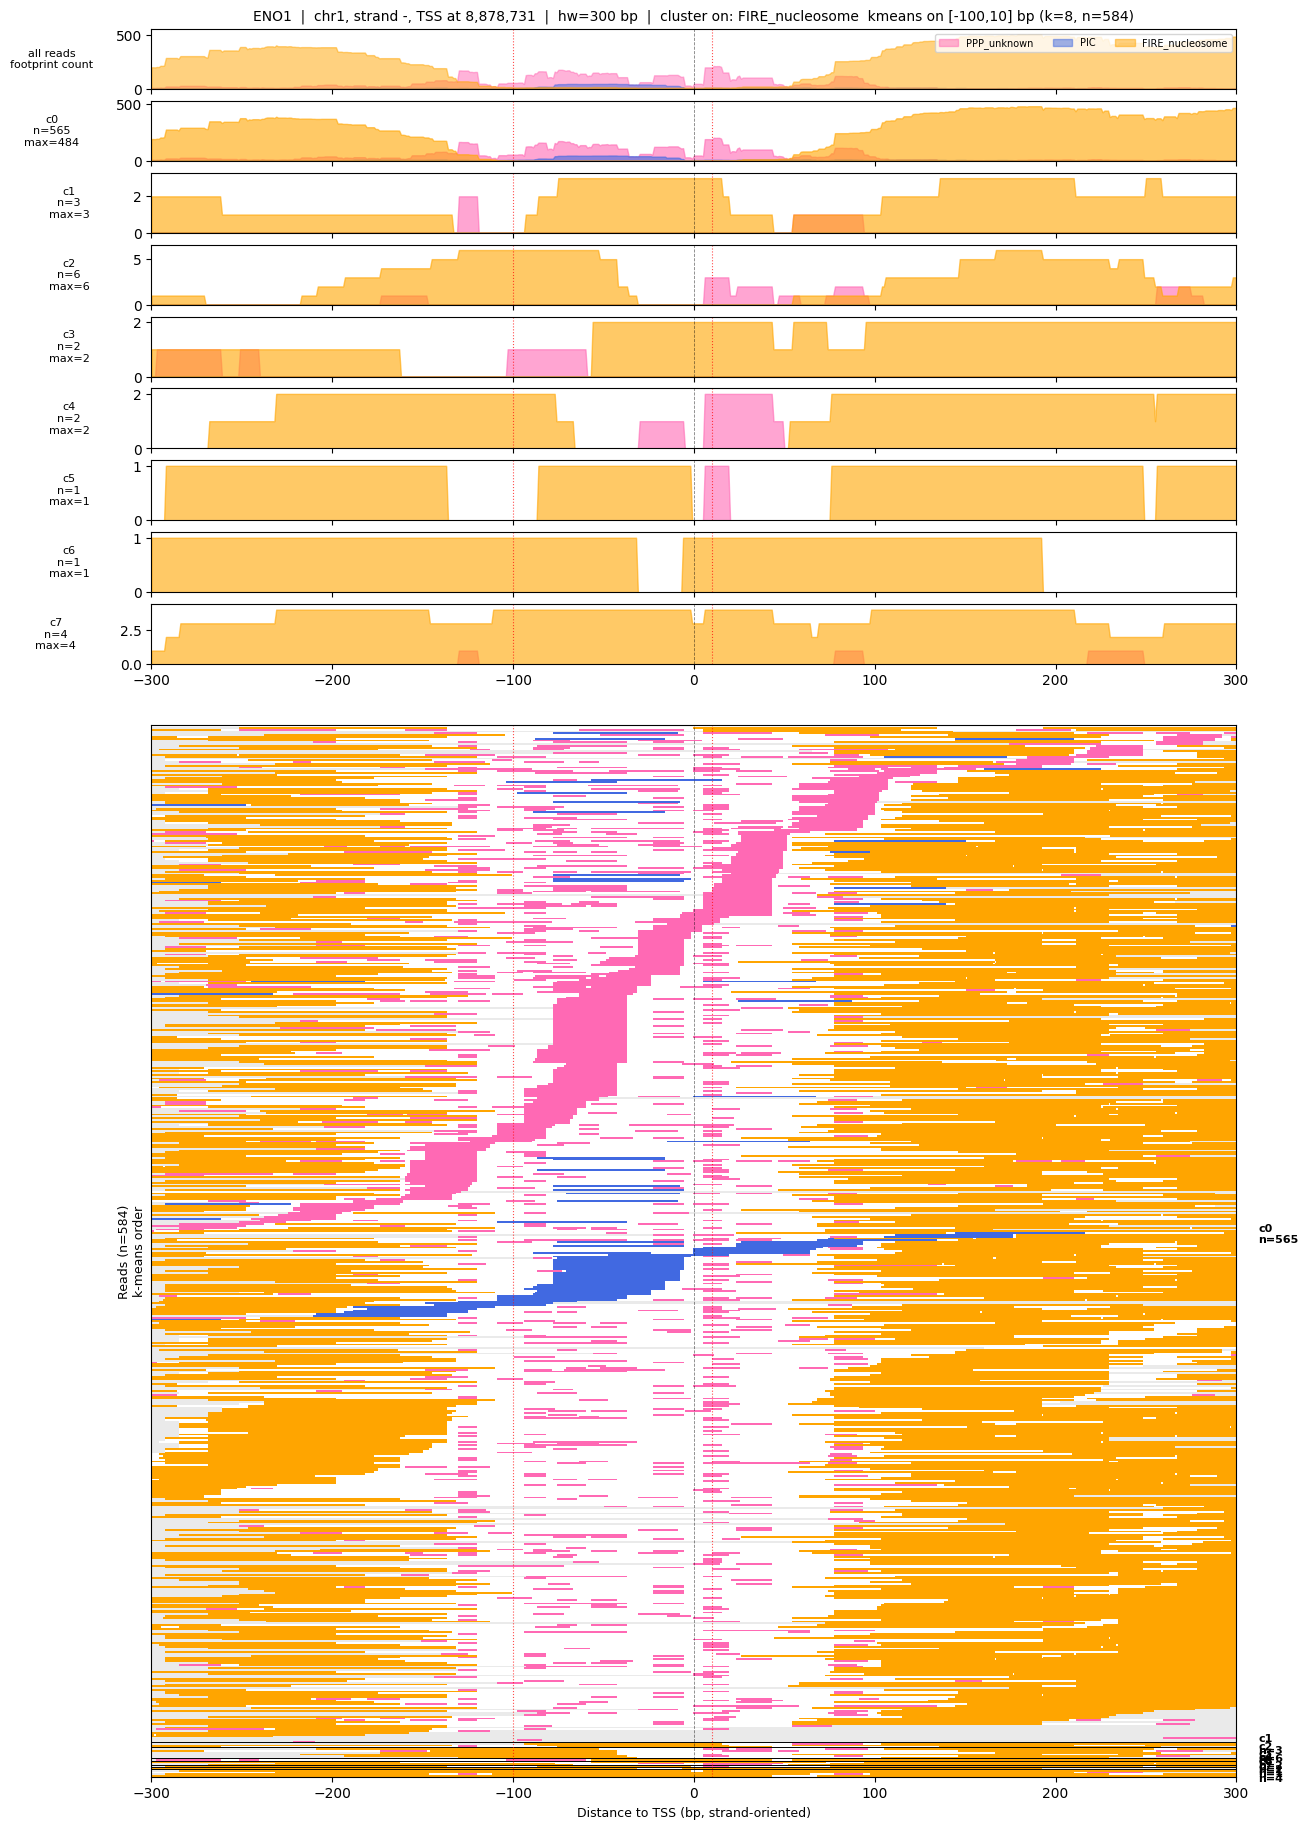

/home/cshan/ipykernel_3839657/1591223002.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_TSS_proximal/31samples_pooled/ZCWPW1_hw300_tss_proximal_single_FIRE_nucleosome_kmeans_cluster_panels_k9.pdf


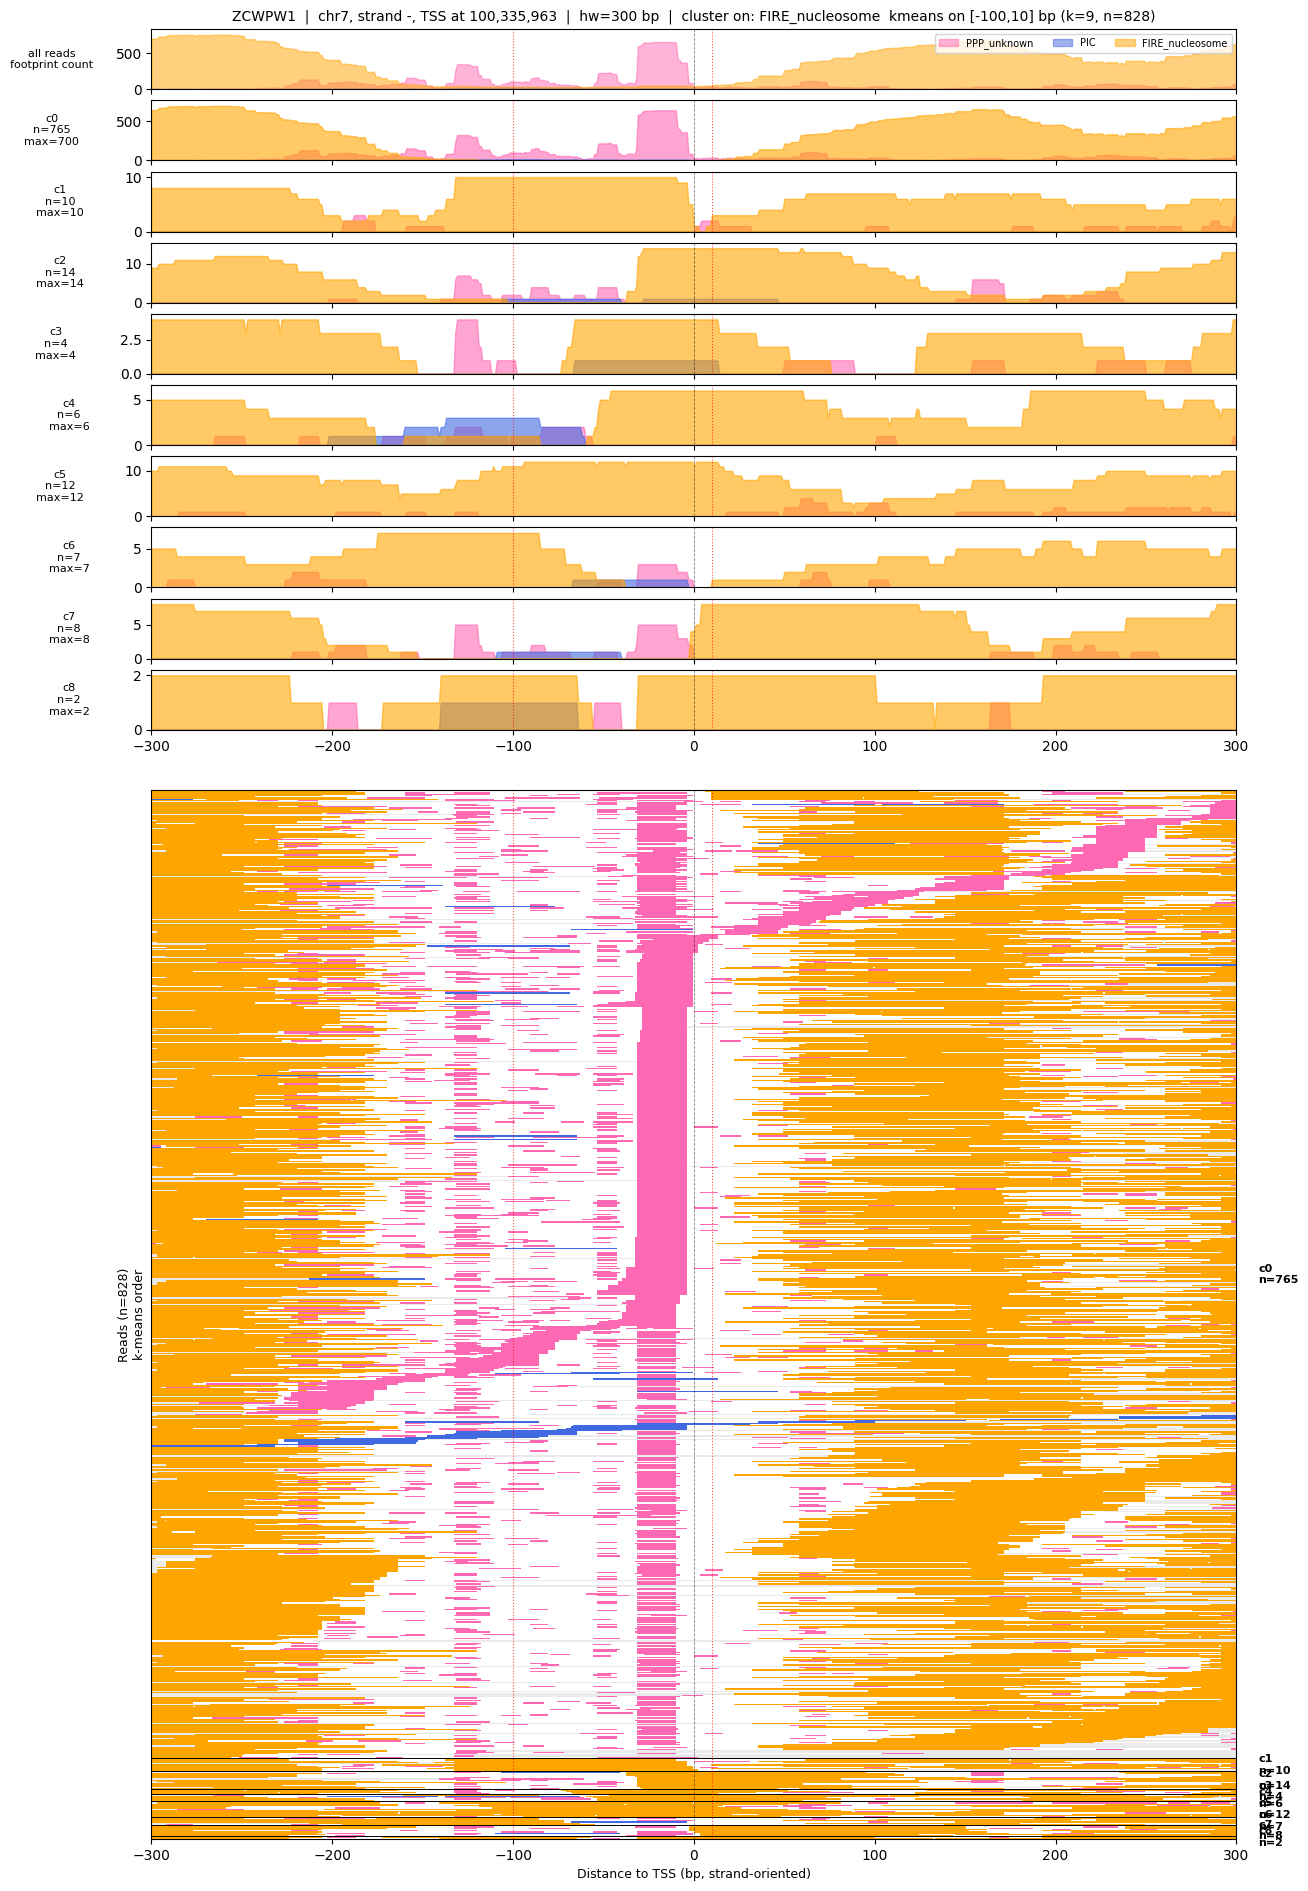

In [28]:
def plot_tss_proximal_single_class_panels(driving_cls, gene_name, res):
    occ        = res["occ"]
    aligned    = res["aligned"]
    classes    = res["classes"]
    chrom      = res["chrom"]
    strand     = res["strand"]
    tss        = res["tss"]
    hw         = res["hw"]
    k          = res["k"]
    labels     = res["labels"]
    leaf_order = res["leaf_order"]
    method     = res["method"]
    n_classes, n_reads, n_pos = occ.shape
    rel_pos    = np.arange(-hw, hw + 1)

    sizes = {c: int((labels == c).sum()) for c in range(k)}
    present_clusters = [c for c in range(k) if sizes[c] > 0]

    profiles = {}
    for cluster_id in range(k):
        cluster_mask = (labels == cluster_id)
        profiles[cluster_id] = {}
        for ci, cls in enumerate(classes):
            if cluster_mask.sum() == 0:
                profiles[cluster_id][cls] = np.zeros(n_pos)
            else:
                profiles[cluster_id][cls] = occ[ci, cluster_mask].sum(axis=0)

    combined = {cls: occ[ci].sum(axis=0) for ci, cls in enumerate(classes)}
    combined_ymax = max((v.max() for v in combined.values()), default=1.0)
    combined_ymax = max(combined_ymax, 1.0)

    order = np.asarray(leaf_order, dtype=int)
    labels_sorted = labels[order]

    img = np.tile(np.array(WHITE_RGB, dtype=np.float32), (n_reads, n_pos, 1))
    img[~aligned] = UNCOVERED_RGB
    for ci, cls in enumerate(classes):
        if cls not in TSS_FP_COLORS:
            continue
        rgb  = np.array(mcolors.to_rgb(TSS_FP_COLORS[cls]), dtype=np.float32)
        mask = occ[ci] > 0
        img[mask] = rgb
    img_sorted = img[order]

    n_top_tracks = len(present_clusters) + 1
    bot_height   = min(14.0, max(3.5, 0.05 * n_reads))
    spacer       = 0.5
    fig_height   = 0.8 * n_top_tracks + bot_height + spacer + 1.0

    fig = plt.figure(figsize=(14, fig_height))
    gs = plt.GridSpec(
        n_top_tracks + 2, 1,
        height_ratios=[0.8] * n_top_tracks + [spacer] + [bot_height],
        hspace=0.08,
    )
    ax_combined = fig.add_subplot(gs[0])
    per_cluster_axes = {
        c: fig.add_subplot(gs[1 + i], sharex=ax_combined)
        for i, c in enumerate(present_clusters)
    }
    ax_bot = fig.add_subplot(gs[n_top_tracks + 1], sharex=ax_combined)
    all_axes = [ax_combined] + list(per_cluster_axes.values()) + [ax_bot]

    for cls in classes:
        if cls not in TSS_FP_COLORS:
            continue
        ax_combined.fill_between(rel_pos, 0, combined[cls],
                                 color=TSS_FP_COLORS[cls], alpha=0.5, label=cls)
    ax_combined.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax_combined.set_xlim(-hw, hw)
    ax_combined.set_ylim(0, combined_ymax * 1.1)
    ax_combined.set_ylabel("all reads\nfootprint count", fontsize=8,
                           rotation=0, labelpad=46, va="center")
    ax_combined.set_title(
        f"{gene_name}  |  {chrom}, strand {strand}, TSS at {tss:,}  |  "
        f"hw={hw} bp  |  cluster on: {driving_cls}  "
        f"{method} on [{CLUSTER_REL_START},{CLUSTER_REL_END}] bp (k={k}, n={n_reads})",
        fontsize=10,
    )
    ax_combined.legend(loc="upper right", fontsize=7, ncol=min(n_classes, 5))
    plt.setp(ax_combined.get_xticklabels(), visible=False)

    last_idx = len(present_clusters) - 1
    for i, cluster_id in enumerate(present_clusters):
        ax = per_cluster_axes[cluster_id]
        for cls in classes:
            if cls not in TSS_FP_COLORS:
                continue
            ax.fill_between(rel_pos, 0, profiles[cluster_id][cls],
                            color=TSS_FP_COLORS[cls], alpha=0.6)
        ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
        ax.set_xlim(-hw, hw)
        cluster_ymax = max(
            (profiles[cluster_id][cls].max() for cls in classes if cls in TSS_FP_COLORS),
            default=1.0,
        )
        cluster_ymax = max(cluster_ymax, 1.0)
        ax.set_ylim(0, cluster_ymax * 1.1)
        ax.set_ylabel(
            f"c{cluster_id}\nn={sizes[cluster_id]}\nmax={int(cluster_ymax)}",
            fontsize=8, rotation=0, labelpad=46, va="center",
        )
        if i < last_idx:
            plt.setp(ax.get_xticklabels(), visible=False)

    ax_bot.imshow(img_sorted, aspect="auto", interpolation="nearest",
                  extent=[-hw - 0.5, hw + 0.5, n_reads, 0])
    ax_bot.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    boundaries = np.where(np.diff(labels_sorted) != 0)[0] + 1
    for b in boundaries:
        ax_bot.axhline(b - 0.5, color="black", lw=0.7)
    label_x = hw + (2 * hw) * 0.02
    for c in present_clusters:
        idx = np.where(labels_sorted == c)[0]
        if len(idx):
            ax_bot.text(label_x, (idx.min() + idx.max()) / 2,
                        f"c{c}\nn={sizes[c]}", fontsize=8, va="center",
                        color="black", fontweight="bold")

    for ax in all_axes:
        ax.axvline(CLUSTER_REL_START, color="red", lw=0.8, ls=":", alpha=0.7)
        ax.axvline(CLUSTER_REL_END, color="red", lw=0.8, ls=":", alpha=0.7)

    ax_bot.set_xlim(-hw, hw)
    ax_bot.set_ylim(n_reads, -1)
    ax_bot.set_yticks([])
    order_label = "Ward leaf order" if method == "ward" else "k-means order"
    ax_bot.set_ylabel(f"Reads (n={n_reads})\n{order_label}", fontsize=9)
    ax_bot.set_xlabel("Distance to TSS (bp, strand-oriented)", fontsize=9)

    plt.tight_layout()
    tag = driving_cls.replace(" ", "_").replace("(", "").replace(")", "")
    out_pdf = TSS_OUT_ROOT / f"{gene_name}_hw{hw}_tss_proximal_single_{tag}_{method}_cluster_panels_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


for (driving_cls, gene_name), res in tss_sc_cluster_results.items():
    plot_tss_proximal_single_class_panels(driving_cls, gene_name, res)

# Cluster by Partitioning Around Medoids (PAM) — PPP + FIRE_nucleosome + PIC jointly

Self-contained section. It imports the packages, loads the pausing/TSS table,
and builds the per-read multi-class occupancy matrix, then clusters with
**PAM (k-medoids)**. The three focal classes — **PPP**, **FIRE_nucleosome**,
and **PIC** — are bin-smoothed and concatenated side-by-side into one large
per-read feature matrix, partitioned by deterministic greedy BUILD seeding
followed by SWAP refinement, with `k` chosen by the silhouette score. Heatmap
rows are grouped by PAM cluster. Footprints are colored by class
(`FP_COLORS`); `unknown` footprints are drawn in grey (`#AAAAAA`) for context
but do **not** drive the clustering.

### 1. Setup: imports and tables.

Imports the packages and footprint-plotting helpers, then loads the
pausing/TSS table and resolves each gene's TSS anchor (CAGE TSS when
available, else GENCODE). Also defines the footprint classes, display
windows, color/blank constants, and the bin-smoothing helper used to build
the joint matrix. Running this makes the PAM section self-contained — no
earlier section needs to have been executed.

In [1]:
# --- Standalone setup for the PAM section --------------------------------
# Mirrors the imports/tables of the first section so this section runs on its
# own. (If you already executed "Cluster by presence of footprint classes"
# top-to-bottom, these definitions simply overwrite identical ones.)
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, "/project/spott/cshan/fiber-seq/code/PolII_footprints_code")
from plot_polii_footprints_precomputed_sort import (
    collect_reads_from_indexed_beds,
    _filter_fire_nucleosome_by_length,
    DEFAULT_FP_BED_DIR,
    DEFAULT_FIRE_NUC_LENGTH_RANGE,
    FP_COLORS,
    CLASS_SUBDIRS,
)

GENES = ["ENO1", "ZCWPW1"]
PAUSING_TSV = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/annotations/"
    "pausing_index_principal_with_CAGE_TSS_all_genes.tsv"
)

FIRE_NUC_LENGTH_RANGE = DEFAULT_FIRE_NUC_LENGTH_RANGE
UNCOVERED_RGB = (0.92, 0.92, 0.92)
WHITE_RGB     = (1.00, 1.00, 1.00)

# Footprint classes carried in the occupancy matrix. PAM later clusters on a
# subset; `unknown` is kept for grey context plotting.
FP_CLASSES_FOR_CLUSTERING = [
    "PPP",
    "PIC",
    "nucleosome (140-160)",
    "FIRE_nucleosome",
    "unknown",
]
PRESENCE_HALF_WINDOWS     = [150, 300]   # bp on each side of TSS, strand-aware
FILTER_FIRE_NUC_BY_LENGTH = False        # True -> restrict FIRE_nuc to FIRE_NUC_LENGTH_RANGE
PRESENCE_BIN_BP           = 10           # mean-pool width when building features


def _bin_smooth_mean(X, bin_bp):
    """Mean-pool every `bin_bp` columns of a 2D array."""
    n_reads, n_pos = X.shape
    n_bin = n_pos // bin_bp
    trimmed = X[:, : n_bin * bin_bp].reshape(n_reads, n_bin, bin_bp)
    return trimmed.mean(axis=2)


# Load the pausing/TSS table and resolve the per-gene TSS anchor.
paus = pd.read_csv(PAUSING_TSV, sep="\t")
gene_info = (
    paus[paus["gene_name"].isin(GENES)]
    [["gene_name", "gene_id", "chrom", "strand", "tss", "cage_tss", "PI"]]
    .drop_duplicates(subset=["gene_name"], keep="first")
    .reset_index(drop=True)
)
gene_info["tss_anchor"] = gene_info["cage_tss"].fillna(gene_info["tss"]).astype(np.int64)
gene_info["tss_source"] = np.where(gene_info["cage_tss"].notna(), "CAGE", "GENCODE")

print(gene_info.to_string(index=False))

gene_name            gene_id chrom strand       tss    cage_tss        PI  tss_anchor tss_source
     ENO1 ENSG00000074800.17  chr1      -   8878731   8878731.0  0.045216     8878731       CAGE
   ZCWPW1 ENSG00000078487.19  chr7      - 100335963 100335963.0 27.058752   100335963       CAGE


### 2. Per-read multi-class occupancy matrix.

For each `(gene, half-window)`, collect per-class footprints in a strand-aware
TSS-centered window and turn every read into a binary occupancy vector per
class (`1` where a class-`c` footprint covers the position). The result is
stored in `presence_matrices`, keyed by `(gene, half-window)`, and is the
input to the joint-matrix build below.

In [3]:
print(f"Half-windows         : {PRESENCE_HALF_WINDOWS} bp (strand-aware)")
print(f"Classes              : {FP_CLASSES_FOR_CLUSTERING}")
print(f"FIRE_nuc length filt : {'on (' + str(FIRE_NUC_LENGTH_RANGE) + ')' if FILTER_FIRE_NUC_BY_LENGTH else 'off (all sizes kept)'}\n")

presence_matrices = {}
for _, g in gene_info.iterrows():
    gene_name = g["gene_name"]
    chrom     = g["chrom"]
    strand    = g["strand"]
    tss       = int(g["tss_anchor"])

    for hw in PRESENCE_HALF_WINDOWS:
        view_start = max(0, tss - hw)
        view_end   = tss + hw
        n_pos      = 2 * hw + 1

        # All-class footprints to estimate each read's alignment span.
        read_spans = collect_reads_from_indexed_beds(
            chrom, view_start, view_end,
            fp_class="all", beds_dir=DEFAULT_FP_BED_DIR,
        )

        # Per-class footprints.
        per_class_reads = {}
        for cls in FP_CLASSES_FOR_CLUSTERING:
            per_class_reads[cls] = collect_reads_from_indexed_beds(
                chrom, view_start, view_end,
                fp_class=cls, beds_dir=DEFAULT_FP_BED_DIR,
            )
        if FILTER_FIRE_NUC_BY_LENGTH and "FIRE_nucleosome" in per_class_reads:
            per_class_reads["FIRE_nucleosome"] = _filter_fire_nucleosome_by_length(
                per_class_reads["FIRE_nucleosome"], FIRE_NUC_LENGTH_RANGE
            )

        read_ids = list(read_spans.keys())
        n_reads  = len(read_ids)
        n_cls    = len(FP_CLASSES_FOR_CLUSTERING)

        occ      = np.zeros((n_cls, n_reads, n_pos), dtype=np.float32)
        aligned  = np.zeros((n_reads, n_pos), dtype=bool)
        r_starts = np.zeros(n_reads, dtype=np.int64)
        r_ends   = np.zeros(n_reads, dtype=np.int64)

        def _rel_bounds(g_start, g_end_excl, strand=strand, tss=tss, hw=hw):
            g_end_incl = g_end_excl - 1
            if strand == "+":
                rel_lo = g_start    - tss
                rel_hi = g_end_incl - tss
            else:
                rel_lo = tss - g_end_incl
                rel_hi = tss - g_start
            return max(rel_lo, -hw), min(rel_hi, hw)

        for i, read_name in enumerate(read_ids):
            span_fps = read_spans[read_name]
            r_starts[i] = min(fp[0] for fp in span_fps)
            r_ends[i]   = max(fp[1] for fp in span_fps)

            rel_lo, rel_hi = _rel_bounds(r_starts[i], r_ends[i])
            if rel_lo <= rel_hi:
                aligned[i, rel_lo + hw : rel_hi + hw + 1] = True

            for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
                for fp in per_class_reads[cls].get(read_name, []):
                    rel_lo, rel_hi = _rel_bounds(fp[0], fp[1])
                    if rel_lo <= rel_hi:
                        occ[ci, i, rel_lo + hw : rel_hi + hw + 1] = 1.0

        presence_matrices[(gene_name, hw)] = {
            "read_ids": read_ids,
            "occ":      occ,
            "aligned":  aligned,
            "r_start":  r_starts,
            "r_end":    r_ends,
            "chrom":    chrom,
            "strand":   strand,
            "tss":      tss,
            "hw":       hw,
            "classes":  list(FP_CLASSES_FOR_CLUSTERING),
        }
        print(f"  {gene_name} hw={hw}: n_reads={n_reads}, shape per class={occ[0].shape}")
        for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
            n_with = int((occ[ci].sum(axis=1) > 0).sum())
            print(f"    {cls:24s}: {n_with} reads with >=1 footprint")

Half-windows         : [150, 300] bp (strand-aware)
Classes              : ['PPP', 'PIC', 'nucleosome (140-160)', 'FIRE_nucleosome', 'unknown']
FIRE_nuc length filt : off (all sizes kept)

  ENO1 hw=150: n_reads=570, shape per class=(570, 301)
    PPP                     : 258 reads with >=1 footprint
    PIC                     : 76 reads with >=1 footprint
    nucleosome (140-160)    : 136 reads with >=1 footprint
    FIRE_nucleosome         : 516 reads with >=1 footprint
    unknown                 : 440 reads with >=1 footprint
  ENO1 hw=300: n_reads=584, shape per class=(584, 601)
    PPP                     : 285 reads with >=1 footprint
    PIC                     : 86 reads with >=1 footprint
    nucleosome (140-160)    : 225 reads with >=1 footprint
    FIRE_nucleosome         : 577 reads with >=1 footprint
    unknown                 : 461 reads with >=1 footprint
  ZCWPW1 hw=150: n_reads=819, shape per class=(819, 301)


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr1_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds

    PPP                     : 465 reads with >=1 footprint
    PIC                     : 41 reads with >=1 footprint
    nucleosome (140-160)    : 234 reads with >=1 footprint
    FIRE_nucleosome         : 706 reads with >=1 footprint
    unknown                 : 676 reads with >=1 footprint
  ZCWPW1 hw=300: n_reads=828, shape per class=(828, 601)
    PPP                     : 513 reads with >=1 footprint
    PIC                     : 58 reads with >=1 footprint
    nucleosome (140-160)    : 481 reads with >=1 footprint
    FIRE_nucleosome         : 824 reads with >=1 footprint
    unknown                 : 740 reads with >=1 footprint


[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/spott/cshan/fiber-seq/results/PolII/footprint_summary_beds/FIRE_nucleosome/chr7_footprints.bed.gz.tbi


### 3. Joint matrix build (PPP + FIRE_nucleosome + PIC).

For each `(gene, half-window)` in `presence_matrices` (step 2), take the
per-read occupancy of the three focal classes, mean-pool every
`PRESENCE_BIN_BP` columns with `_bin_smooth_mean`, and concatenate the three
binned blocks into a single matrix `X` of shape `(n_reads, 3 × n_bins)` — the
large joint matrix that PAM clusters on.

In [4]:
# Cluster on the three focal classes only (the occupancy `presence_matrices`
# was built in step 2 above); `unknown` is carried along for plotting (drawn
# grey) but does NOT drive the clustering.
PAM_CLUSTER_CLASSES = ["PPP", "FIRE_nucleosome", "PIC"]   # clustered jointly
PAM_OUT_ROOT = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/"
    "31samples_pooled_PAM"
)
PAM_OUT_ROOT.mkdir(parents=True, exist_ok=True)

pam_joint_matrices = {}
for (gene_name, hw), info in presence_matrices.items():
    occ     = info["occ"]                 # (n_classes, n_reads, n_pos)
    classes = info["classes"]
    # Bin-smooth each focal class then concatenate side-by-side into one large
    # per-read feature matrix (the "joint" matrix).
    binned = [
        _bin_smooth_mean(occ[classes.index(cls)], PRESENCE_BIN_BP)
        for cls in PAM_CLUSTER_CLASSES
    ]
    X = np.concatenate(binned, axis=1)
    pam_joint_matrices[(gene_name, hw)] = X
    print(f"{gene_name} hw={hw}: joint matrix {X.shape} "
          f"({' + '.join(PAM_CLUSTER_CLASSES)}, bin={PRESENCE_BIN_BP} bp)")

ENO1 hw=150: joint matrix (570, 90) (PPP + FIRE_nucleosome + PIC, bin=10 bp)
ENO1 hw=300: joint matrix (584, 180) (PPP + FIRE_nucleosome + PIC, bin=10 bp)
ZCWPW1 hw=150: joint matrix (819, 90) (PPP + FIRE_nucleosome + PIC, bin=10 bp)
ZCWPW1 hw=300: joint matrix (828, 180) (PPP + FIRE_nucleosome + PIC, bin=10 bp)


### 4. PAM clustering (BUILD + SWAP), k by silhouette.

A precomputed pairwise distance matrix (`PAM_METRIC`, default Euclidean) is
clustered with Partitioning Around Medoids: greedy **BUILD** seeds the medoids,
then **SWAP** greedily exchanges a medoid with a non-medoid as long as the
total assignment cost decreases. Both steps are deterministic. `k` is selected
over `PAM_K_RANGE` by the silhouette score; clusters are then relabeled by
descending size and saved per `(gene, half-window)`.

In [5]:
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score

PAM_K_RANGE  = range(2, 7)      # candidate cluster counts; best k by silhouette
PAM_METRIC   = "euclidean"      # distance on the binned joint occupancy
PAM_MAX_ITER = 100              # max SWAP iterations


def _pam_build(D, k):
    """Greedy PAM BUILD: seed k medoids that minimize total assignment cost."""
    n = D.shape[0]
    medoids = [int(np.argmin(D.sum(axis=1)))]
    nearest = D[medoids[0]].copy()
    while len(medoids) < k:
        gains = np.where(
            np.isin(np.arange(n), medoids), -np.inf,
            np.maximum(0.0, nearest[None, :] - D).sum(axis=1),
        )
        c = int(np.argmax(gains))
        medoids.append(c)
        nearest = np.minimum(nearest, D[c])
    return medoids


def _pam_swap(D, medoids, max_iter):
    """PAM SWAP: greedily swap a medoid with a non-medoid while cost drops."""
    medoids = list(medoids)
    n = D.shape[0]
    for _ in range(max_iter):
        dm     = D[np.asarray(medoids)]                 # (k, n)
        labels = np.argmin(dm, axis=0)
        cost   = dm[labels, np.arange(n)].sum()
        best_delta, best = -1e-9, None
        for mi in range(len(medoids)):
            others  = [m for j, m in enumerate(medoids) if j != mi]
            d_other = (D[np.asarray(others)].min(axis=0)
                       if others else np.full(n, np.inf))
            # Total cost for every candidate replacement of medoids[mi] at once.
            cand = np.minimum(d_other[None, :], D).sum(axis=1)
            cand[np.asarray(medoids)] = np.inf
            h = int(np.argmin(cand))
            if cand[h] - cost < best_delta:
                best_delta, best = cand[h] - cost, (mi, h)
        if best is None:
            break
        mi, h = best
        medoids[mi] = h
    dm     = D[np.asarray(medoids)]
    labels = np.argmin(dm, axis=0)
    cost   = float(dm[labels, np.arange(n)].sum())
    return np.asarray(medoids), labels, cost


pam_cluster_results = {}
for (gene_name, hw), info in presence_matrices.items():
    X       = pam_joint_matrices[(gene_name, hw)]
    n_reads = X.shape[0]
    if n_reads < 3:
        print(f"{gene_name} hw={hw}: only {n_reads} reads, skipping")
        continue

    D = squareform(pdist(X, metric=PAM_METRIC)).astype(np.float64)

    best = None   # (silhouette, k, medoids, labels)
    for k in PAM_K_RANGE:
        if k >= n_reads:
            break
        medoids = _pam_build(D, k)
        medoids, labels, cost = _pam_swap(D, medoids, PAM_MAX_ITER)
        if len(np.unique(labels)) < 2:
            continue
        sil = float(silhouette_score(D, labels, metric="precomputed"))
        if best is None or sil > best[0]:
            best = (sil, k, medoids, labels)

    if best is None:
        print(f"{gene_name} hw={hw}: no valid PAM partition, skipping")
        continue

    sil, best_k, medoids, labels = best
    # Relabel clusters 0..k-1 in descending size for stable, readable ids.
    order_by_size = sorted(range(best_k), key=lambda c: -(labels == c).sum())
    remap   = {old: new for new, old in enumerate(order_by_size)}
    labels  = np.array([remap[c] for c in labels])
    medoids = medoids[np.asarray(order_by_size)]   # medoids[new] = old medoid

    pam_cluster_results[(gene_name, hw)] = {
        **info,
        "X":          X,
        "labels":     labels,
        "k":          best_k,
        "medoids":    medoids,
        "silhouette": sil,
    }

    sizes = {c: int((labels == c).sum()) for c in range(best_k)}
    print(f"\n=== {gene_name} hw={hw}  (n_reads={n_reads}, metric={PAM_METRIC}) ===")
    print(f"  PAM best k={best_k} (silhouette={sil:.3f})")
    for c, n in sorted(sizes.items()):
        print(f"  c{c}: n={n}  (medoid read = {info['read_ids'][medoids[c]]})")

    np.save(PAM_OUT_ROOT / f"{gene_name}_w{hw}_pam_labels_k{best_k}.npy", labels)
    pd.DataFrame({
        "read_id": info["read_ids"],
        "cluster": labels,
    }).to_csv(PAM_OUT_ROOT / f"{gene_name}_w{hw}_pam_clusters_k{best_k}.tsv",
              sep="\t", index=False)


=== ENO1 hw=150  (n_reads=570, metric=euclidean) ===
  PAM best k=2 (silhouette=0.210)
  c0: n=373  (medoid read = m84241_250514_222554_s2/110892865/ccs)
  c1: n=197  (medoid read = m84241_250326_051456_s4/261359939/ccs)

=== ENO1 hw=300  (n_reads=584, metric=euclidean) ===
  PAM best k=2 (silhouette=0.171)
  c0: n=386  (medoid read = m84241_250326_031141_s3/35591795/ccs)
  c1: n=198  (medoid read = m84241_250905_234909_s1/30082577/ccs)

=== ZCWPW1 hw=150  (n_reads=819, metric=euclidean) ===
  PAM best k=2 (silhouette=0.279)
  c0: n=484  (medoid read = m84241_250326_051456_s4/17961832/ccs)
  c1: n=335  (medoid read = m84241_250908_220650_s1/49415689/ccs)

=== ZCWPW1 hw=300  (n_reads=828, metric=euclidean) ===
  PAM best k=2 (silhouette=0.140)
  c0: n=420  (medoid read = m84241_250910_225330_s3/7669916/ccs)
  c1: n=408  (medoid read = m84241_250515_002859_s3/57609705/ccs)


### 5. Per-cluster tracks + per-read heatmap (rows grouped by PAM cluster).

Same three-part layout as the first section: a combined footprint-count overlay
across all reads, one per-cluster overlay, and the per-read heatmap with rows
ordered by PAM cluster and black lines at cluster boundaries. PPP / PIC /
FIRE_nucleosome are drawn in their `FP_COLORS`; `unknown` is drawn in grey
(`#AAAAAA`) beneath the colored focal classes.

/home/cshan/ipykernel_3167637/3516509487.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/31samples_pooled_PAM/ENO1_w150_pam_cluster_panels_k2.pdf


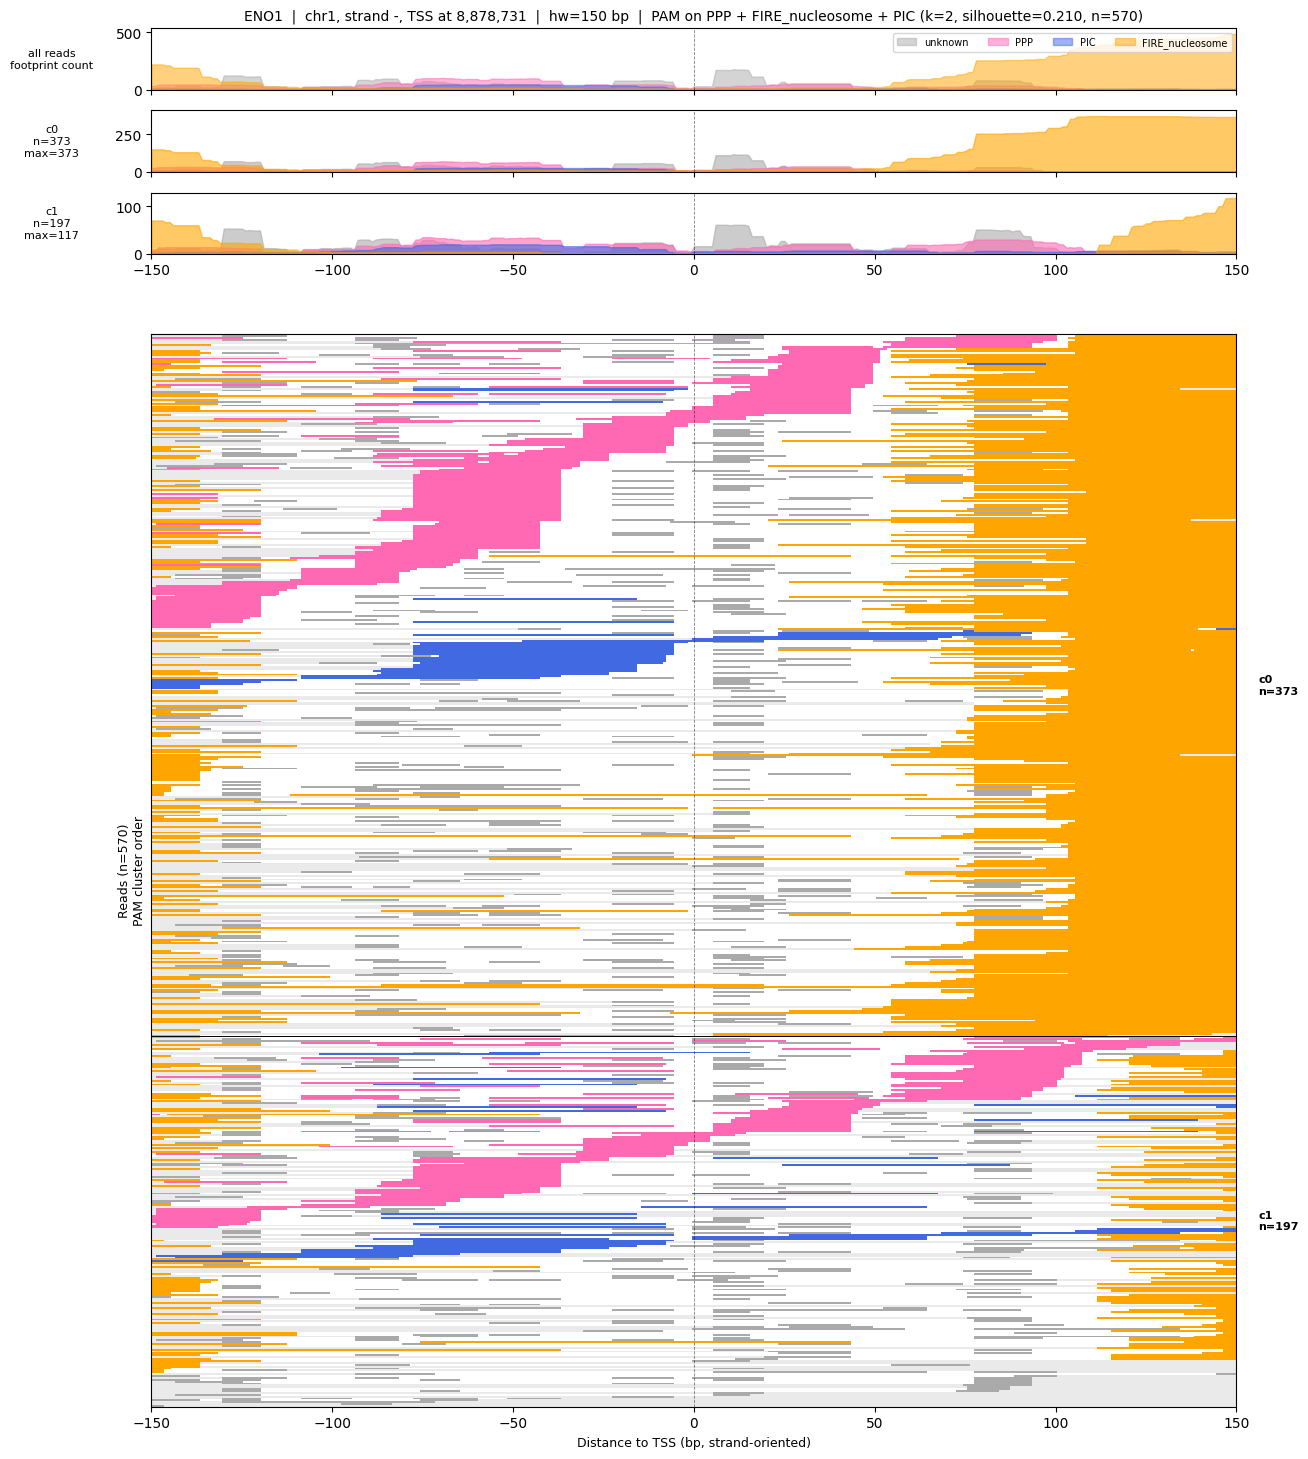

/home/cshan/ipykernel_3167637/3516509487.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/31samples_pooled_PAM/ENO1_w300_pam_cluster_panels_k2.pdf


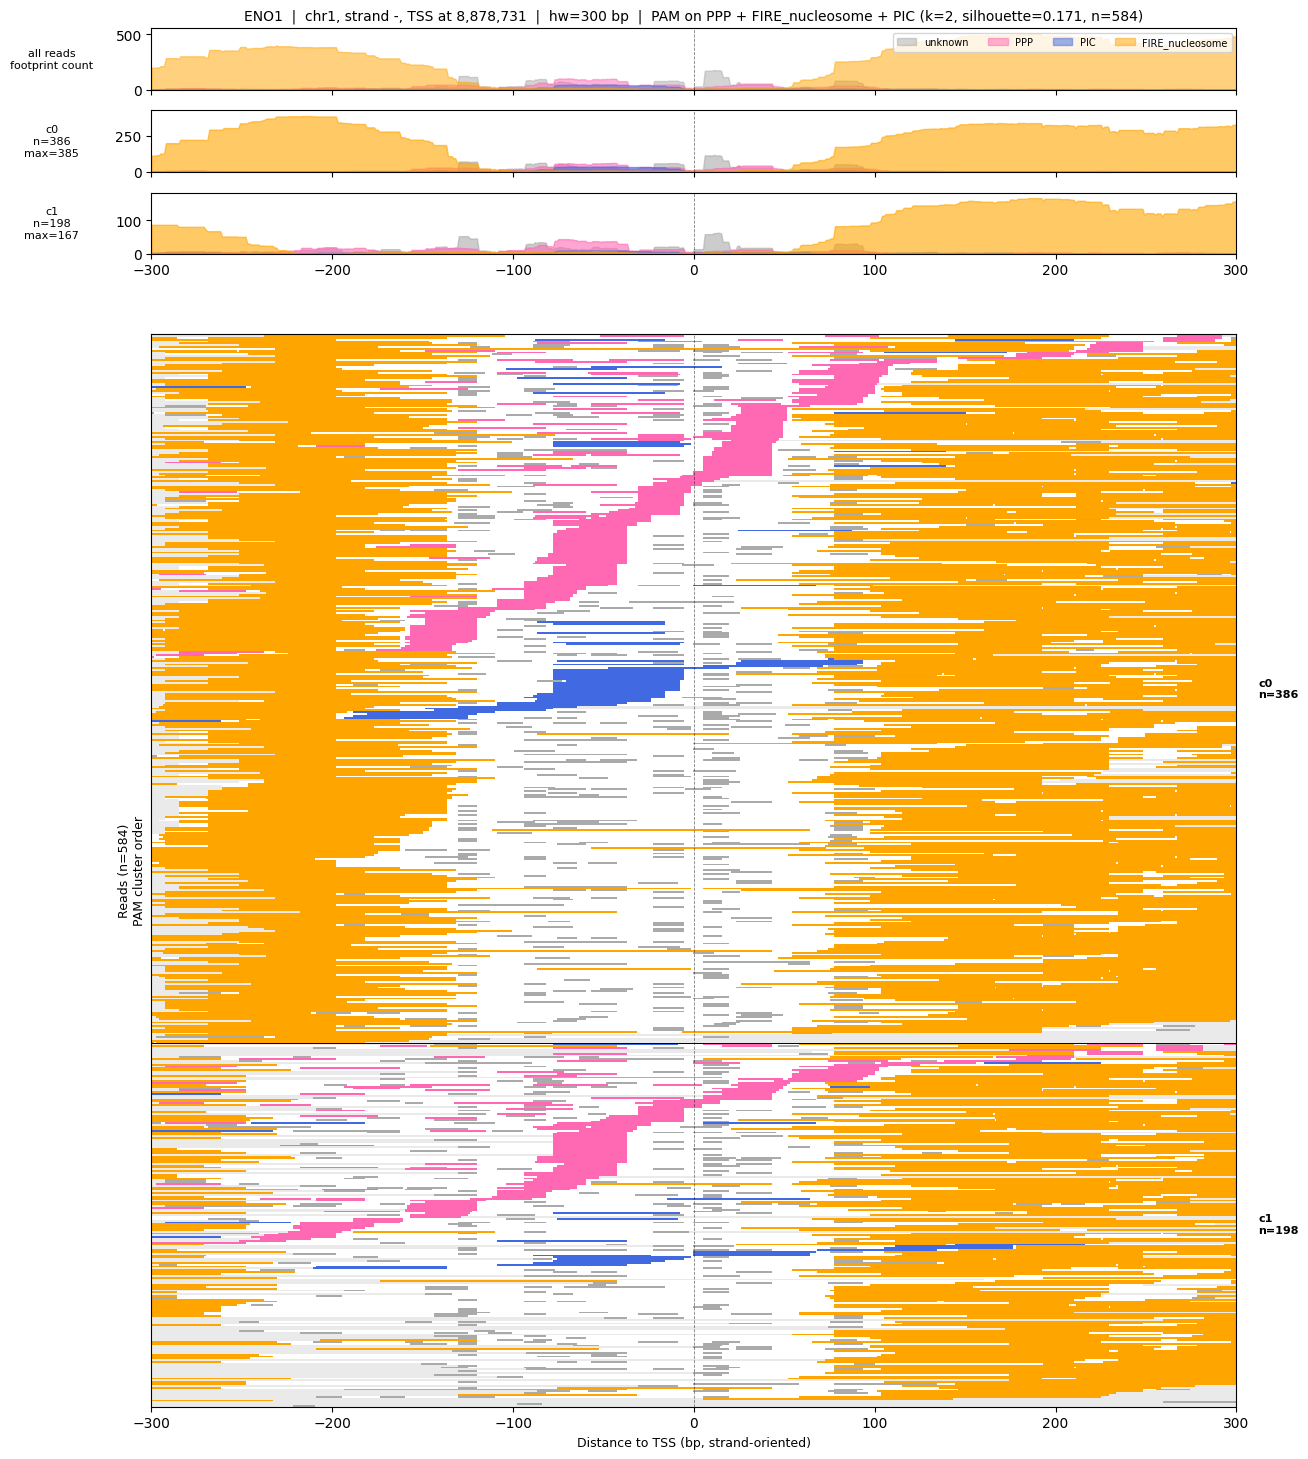

/home/cshan/ipykernel_3167637/3516509487.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/31samples_pooled_PAM/ZCWPW1_w150_pam_cluster_panels_k2.pdf


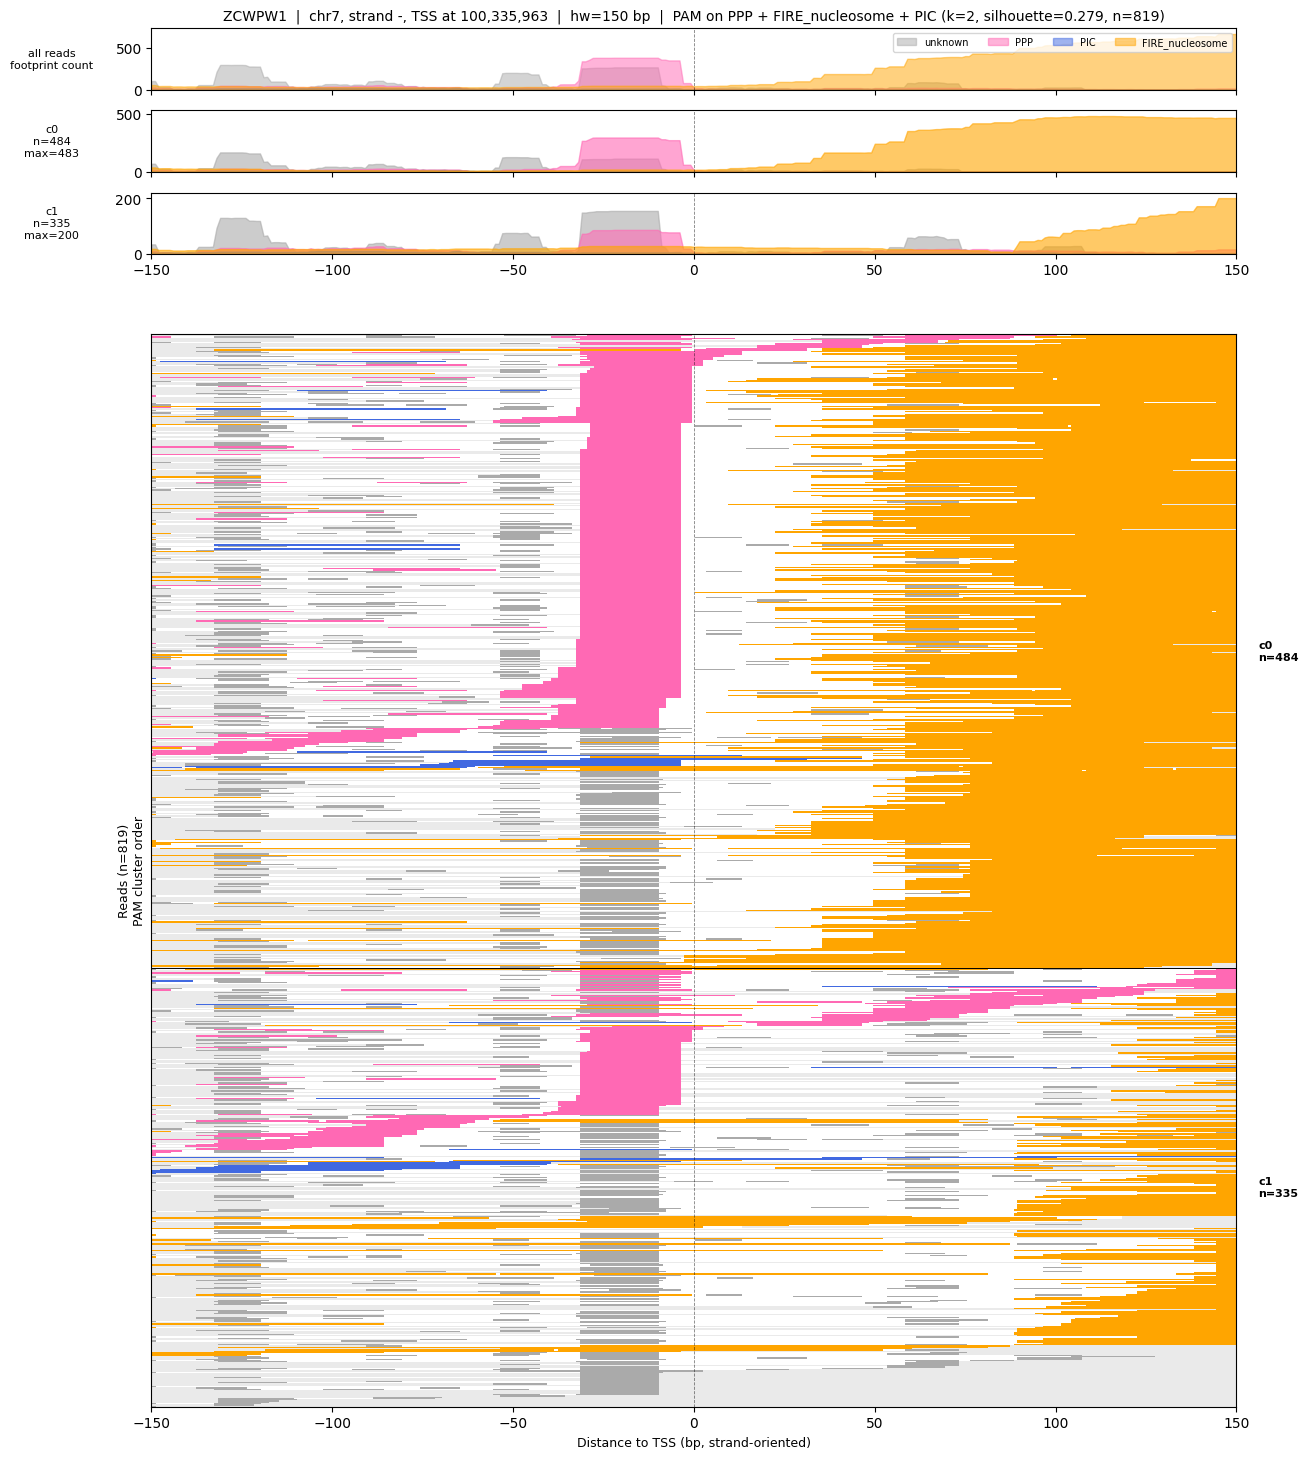

/home/cshan/ipykernel_3167637/3516509487.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  wrote: /project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/31samples_pooled_PAM/ZCWPW1_w300_pam_cluster_panels_k2.pdf


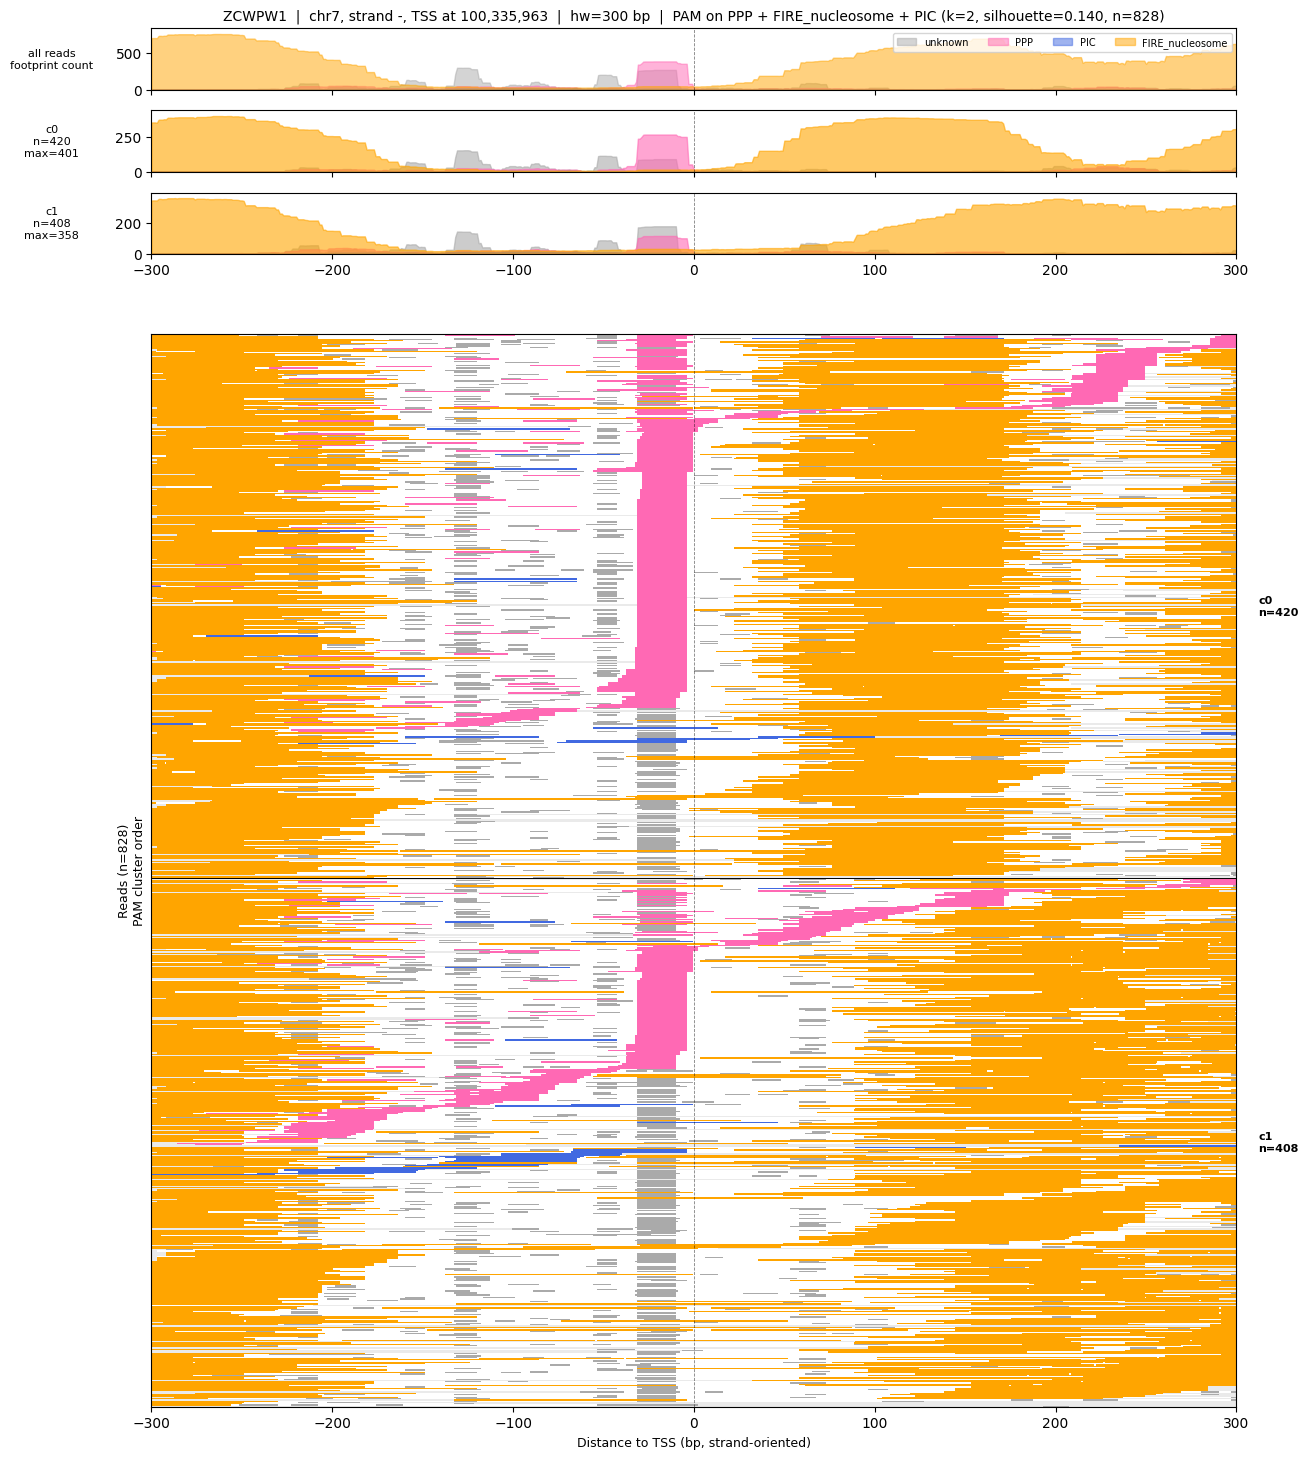

In [6]:
import matplotlib.colors as mcolors   # (already imported above; harmless)

# Classes drawn in the figure: the three clustered classes plus `unknown`
# (grey, FP_COLORS["unknown"] = #AAAAAA), shown for context only.
PAM_DISPLAY_CLASSES = ["unknown", "PPP", "PIC", "FIRE_nucleosome"]
# Heatmap paint order: grey `unknown` first, colored focal classes on top.
PAM_PAINT_ORDER     = ["unknown", "PPP", "PIC", "FIRE_nucleosome"]


def plot_pam_cluster_panels(gene_name, hw, res):
    occ      = res["occ"]               # (n_classes, n_reads, n_pos), 0/1
    aligned  = res["aligned"]
    classes  = res["classes"]
    chrom    = res["chrom"]
    strand   = res["strand"]
    tss      = res["tss"]
    k        = res["k"]
    labels   = res["labels"]
    sil      = res["silhouette"]
    n_classes, n_reads, n_pos = occ.shape
    rel_pos  = np.arange(-hw, hw + 1)
    ch       = {cls: classes.index(cls) for cls in PAM_DISPLAY_CLASSES}

    sizes = {c: int((labels == c).sum()) for c in range(k)}
    present_clusters = [c for c in range(k) if sizes[c] > 0]

    # Per-cluster, per-class footprint count at each position.
    profiles = {}
    for cluster_id in range(k):
        m = (labels == cluster_id)
        profiles[cluster_id] = {
            cls: (occ[ch[cls], m].sum(axis=0) if m.sum() else np.zeros(n_pos))
            for cls in PAM_DISPLAY_CLASSES
        }
    combined = {cls: occ[ch[cls]].sum(axis=0) for cls in PAM_DISPLAY_CLASSES}
    combined_ymax = max(max((v.max() for v in combined.values()), default=1.0), 1.0)

    # Rows grouped by PAM cluster (stable within cluster).
    order = np.argsort(labels, kind="stable")
    labels_sorted = labels[order]

    # Bottom heatmap RGB image: grey unknown first, colored classes on top.
    img = np.tile(np.array(WHITE_RGB, dtype=np.float32), (n_reads, n_pos, 1))
    img[~aligned] = UNCOVERED_RGB
    for cls in PAM_PAINT_ORDER:
        rgb  = np.array(mcolors.to_rgb(FP_COLORS[cls]), dtype=np.float32)
        img[occ[ch[cls]] > 0] = rgb
    img_sorted = img[order]

    n_top_tracks = len(present_clusters) + 1
    bot_height   = min(14.0, max(3.5, 0.05 * n_reads))
    spacer       = 0.5
    fig_height   = 0.8 * n_top_tracks + bot_height + spacer + 1.0

    fig = plt.figure(figsize=(14, fig_height))
    gs = plt.GridSpec(
        n_top_tracks + 2, 1,
        height_ratios=[0.8] * n_top_tracks + [spacer] + [bot_height],
        hspace=0.08,
    )
    ax_combined = fig.add_subplot(gs[0])
    per_cluster_axes = {
        c: fig.add_subplot(gs[1 + i], sharex=ax_combined)
        for i, c in enumerate(present_clusters)
    }
    ax_bot = fig.add_subplot(gs[n_top_tracks + 1], sharex=ax_combined)

    # Combined overlay - per-class total counts across all reads.
    for cls in PAM_DISPLAY_CLASSES:
        ax_combined.fill_between(rel_pos, 0, combined[cls],
                                 color=FP_COLORS[cls], alpha=0.5, label=cls)
    ax_combined.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax_combined.set_xlim(-hw, hw)
    ax_combined.set_ylim(0, combined_ymax * 1.1)
    ax_combined.set_ylabel("all reads\nfootprint count", fontsize=8,
                           rotation=0, labelpad=46, va="center")
    ax_combined.set_title(
        f"{gene_name}  |  {chrom}, strand {strand}, TSS at {tss:,}  |  "
        f"hw={hw} bp  |  PAM on {' + '.join(PAM_CLUSTER_CLASSES)} "
        f"(k={k}, silhouette={sil:.3f}, n={n_reads})",
        fontsize=10,
    )
    ax_combined.legend(loc="upper right", fontsize=7,
                       ncol=len(PAM_DISPLAY_CLASSES))
    plt.setp(ax_combined.get_xticklabels(), visible=False)

    # Per-cluster panels - per-class counts within each cluster, own y-axis max.
    last_idx = len(present_clusters) - 1
    for i, cluster_id in enumerate(present_clusters):
        ax = per_cluster_axes[cluster_id]
        for cls in PAM_DISPLAY_CLASSES:
            ax.fill_between(rel_pos, 0, profiles[cluster_id][cls],
                            color=FP_COLORS[cls], alpha=0.6)
        ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
        ax.set_xlim(-hw, hw)
        cluster_ymax = max(
            max((profiles[cluster_id][cls].max() for cls in PAM_DISPLAY_CLASSES),
                default=1.0), 1.0)
        ax.set_ylim(0, cluster_ymax * 1.1)
        ax.set_ylabel(
            f"c{cluster_id}\nn={sizes[cluster_id]}\nmax={int(cluster_ymax)}",
            fontsize=8, rotation=0, labelpad=46, va="center",
        )
        if i < last_idx:
            plt.setp(ax.get_xticklabels(), visible=False)

    # Bottom heatmap
    ax_bot.imshow(img_sorted, aspect="auto", interpolation="nearest",
                  extent=[-hw - 0.5, hw + 0.5, n_reads, 0])
    ax_bot.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    boundaries = np.where(np.diff(labels_sorted) != 0)[0] + 1
    for b in boundaries:
        ax_bot.axhline(b - 0.5, color="black", lw=0.7)
    label_x = hw + (2 * hw) * 0.02
    for c in present_clusters:
        idx = np.where(labels_sorted == c)[0]
        if len(idx):
            ax_bot.text(label_x, (idx.min() + idx.max()) / 2,
                        f"c{c}\nn={sizes[c]}", fontsize=8, va="center",
                        color="black", fontweight="bold")
    ax_bot.set_xlim(-hw, hw)
    ax_bot.set_ylim(n_reads, -1)
    ax_bot.set_yticks([])
    ax_bot.set_ylabel(f"Reads (n={n_reads})\nPAM cluster order", fontsize=9)
    ax_bot.set_xlabel("Distance to TSS (bp, strand-oriented)", fontsize=9)

    plt.tight_layout()
    out_pdf = PAM_OUT_ROOT / f"{gene_name}_w{hw}_pam_cluster_panels_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


for (gene_name, hw), res in pam_cluster_results.items():
    plot_pam_cluster_panels(gene_name, hw, res)

# Cluster by Leiden community detection — PPP + FIRE_nucleosome + PIC jointly

This section follows the graph-clustering pattern used by IDLI with caution: build one per-read joint matrix from aligned signal blocks, construct a k-nearest-neighbor graph, run Leiden community detection on that graph, and compute UMAP only for visualization / row ordering. Here the three signal blocks are binary footprint-class occupancy for **PPP**, **FIRE_nucleosome**, and **PIC** rather than CpG methylation / accessibility t-value tracks.

`unknown` remains available for heatmap context but does **not** drive graph construction. Leiden does not require a fixed cluster count; the number of clusters is controlled indirectly by `LEIDEN_RESOLUTION`, `LEIDEN_N_NEIGHBORS`, and the graph metric.


### 1. Setup and joint matrix build.

This reuses `presence_matrices` from the PAM setup above. For each `(gene, half-window)`, the three focal classes are mean-pooled in `PRESENCE_BIN_BP` bins and concatenated into `leiden_joint_matrices[(gene, hw)]`. The default `LEIDEN_SCALE_FEATURES = False` keeps the binned binary occupancy in its original units; set it to `True` if you want each binned position/class feature to contribute equally after standardization.


In [3]:
# --- Leiden / UMAP setup ---------------------------------------------------
# This section intentionally mirrors the IDLI graph-clustering workflow
# (joint matrix -> kNN graph -> Leiden -> UMAP) while using footprint-class
# occupancy rather than CpG methylation/accessibility tracks.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

LEIDEN_CLUSTER_CLASSES = ["PPP", "FIRE_nucleosome", "PIC"]
LEIDEN_DISPLAY_CLASSES = ["unknown", "PPP", "PIC", "FIRE_nucleosome"]
LEIDEN_PAINT_ORDER = ["unknown", "PPP", "PIC", "FIRE_nucleosome"]

LEIDEN_OUT_ROOT = Path(
    "/project/spott/cshan/fiber-seq/results/PolII/cluster_reads_by_FP_presence/"
    "31samples_pooled_leiden"
)
LEIDEN_OUT_ROOT.mkdir(parents=True, exist_ok=True)

# IDLI used n_neighbors=15, correlation distance, and Leiden resolution near 0.5
# for nucleosome distortion classes. These are reasonable starting values here,
# but should be treated as sensitivity parameters for footprint-class occupancy.
LEIDEN_N_NEIGHBORS = 15
LEIDEN_METRIC = "correlation"
LEIDEN_RESOLUTION = 0.5
LEIDEN_RANDOM_STATE = 0
LEIDEN_SCALE_FEATURES = False
LEIDEN_UMAP_MIN_DIST = 0.1
LEIDEN_UMAP_SPREAD = 1.0


def _standardize_features(X):
    """Column-standardize features while leaving constant columns at zero."""
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / sd


# Make this section runnable after a kernel restart. If the PAM setup above has
# already created `presence_matrices`, this block is skipped.
if "presence_matrices" not in globals():
    import sys

    sys.path.insert(0, "/project/spott/cshan/fiber-seq/code/PolII_footprints_code")
    from plot_polii_footprints_precomputed_sort import (
        collect_reads_from_indexed_beds,
        _filter_fire_nucleosome_by_length,
        DEFAULT_FP_BED_DIR,
        DEFAULT_FIRE_NUC_LENGTH_RANGE,
        FP_COLORS,
    )

    GENES = globals().get("GENES", ["ENO1", "ZCWPW1"])
    PAUSING_TSV = globals().get(
        "PAUSING_TSV",
        Path(
            "/project/spott/cshan/fiber-seq/results/PolII/annotations/"
            "pausing_index_principal_with_CAGE_TSS_all_genes.tsv"
        ),
    )
    FIRE_NUC_LENGTH_RANGE = globals().get(
        "FIRE_NUC_LENGTH_RANGE", DEFAULT_FIRE_NUC_LENGTH_RANGE
    )
    PRESENCE_HALF_WINDOWS = globals().get("PRESENCE_HALF_WINDOWS", [150, 300])
    PRESENCE_BIN_BP = globals().get("PRESENCE_BIN_BP", 10)
    FILTER_FIRE_NUC_BY_LENGTH = globals().get("FILTER_FIRE_NUC_BY_LENGTH", False)
    FP_CLASSES_FOR_CLUSTERING = globals().get(
        "FP_CLASSES_FOR_CLUSTERING",
        ["PPP", "PIC", "nucleosome (140-160)", "FIRE_nucleosome", "unknown"],
    )
    UNCOVERED_RGB = globals().get("UNCOVERED_RGB", (0.92, 0.92, 0.92))
    WHITE_RGB = globals().get("WHITE_RGB", (1.00, 1.00, 1.00))

    if "_bin_smooth_mean" not in globals():
        def _bin_smooth_mean(X, bin_bp):
            n_reads, n_pos = X.shape
            n_bin = n_pos // bin_bp
            trimmed = X[:, : n_bin * bin_bp].reshape(n_reads, n_bin, bin_bp)
            return trimmed.mean(axis=2)

    paus = pd.read_csv(PAUSING_TSV, sep="\t")
    gene_info = (
        paus[paus["gene_name"].isin(GENES)]
        [["gene_name", "gene_id", "chrom", "strand", "tss", "cage_tss", "PI"]]
        .drop_duplicates(subset=["gene_name"], keep="first")
        .reset_index(drop=True)
    )
    gene_info["tss_anchor"] = gene_info["cage_tss"].fillna(gene_info["tss"]).astype(np.int64)
    gene_info["tss_source"] = np.where(gene_info["cage_tss"].notna(), "CAGE", "GENCODE")

    print("presence_matrices not found; rebuilding occupancy matrices for Leiden")
    print(gene_info.to_string(index=False))

    presence_matrices = {}
    for _, g in gene_info.iterrows():
        gene_name = g["gene_name"]
        chrom = g["chrom"]
        strand = g["strand"]
        tss = int(g["tss_anchor"])

        for hw in PRESENCE_HALF_WINDOWS:
            view_start = max(0, tss - hw)
            view_end = tss + hw
            n_pos = 2 * hw + 1

            read_spans = collect_reads_from_indexed_beds(
                chrom, view_start, view_end,
                fp_class="all", beds_dir=DEFAULT_FP_BED_DIR,
            )
            per_class_reads = {}
            for cls in FP_CLASSES_FOR_CLUSTERING:
                per_class_reads[cls] = collect_reads_from_indexed_beds(
                    chrom, view_start, view_end,
                    fp_class=cls, beds_dir=DEFAULT_FP_BED_DIR,
                )
            if FILTER_FIRE_NUC_BY_LENGTH and "FIRE_nucleosome" in per_class_reads:
                per_class_reads["FIRE_nucleosome"] = _filter_fire_nucleosome_by_length(
                    per_class_reads["FIRE_nucleosome"], FIRE_NUC_LENGTH_RANGE
                )

            read_ids = list(read_spans.keys())
            n_reads = len(read_ids)
            n_cls = len(FP_CLASSES_FOR_CLUSTERING)
            occ = np.zeros((n_cls, n_reads, n_pos), dtype=np.float32)
            aligned = np.zeros((n_reads, n_pos), dtype=bool)
            r_starts = np.zeros(n_reads, dtype=np.int64)
            r_ends = np.zeros(n_reads, dtype=np.int64)

            def _rel_bounds(g_start, g_end_excl, strand=strand, tss=tss, hw=hw):
                g_end_incl = g_end_excl - 1
                if strand == "+":
                    rel_lo = g_start - tss
                    rel_hi = g_end_incl - tss
                else:
                    rel_lo = tss - g_end_incl
                    rel_hi = tss - g_start
                return max(rel_lo, -hw), min(rel_hi, hw)

            for ri, read_name in enumerate(read_ids):
                span_fps = read_spans[read_name]
                r_starts[ri] = min(fp[0] for fp in span_fps)
                r_ends[ri] = max(fp[1] for fp in span_fps)

                rel_lo, rel_hi = _rel_bounds(r_starts[ri], r_ends[ri])
                if rel_lo <= rel_hi:
                    aligned[ri, rel_lo + hw : rel_hi + hw + 1] = True

                for ci, cls in enumerate(FP_CLASSES_FOR_CLUSTERING):
                    for fp in per_class_reads[cls].get(read_name, []):
                        rel_lo, rel_hi = _rel_bounds(fp[0], fp[1])
                        if rel_lo <= rel_hi:
                            occ[ci, ri, rel_lo + hw : rel_hi + hw + 1] = 1.0

            presence_matrices[(gene_name, hw)] = {
                "read_ids": read_ids,
                "occ": occ,
                "aligned": aligned,
                "r_start": r_starts,
                "r_end": r_ends,
                "chrom": chrom,
                "strand": strand,
                "tss": tss,
                "hw": hw,
                "classes": list(FP_CLASSES_FOR_CLUSTERING),
            }
            print(f"  {gene_name} hw={hw}: n_reads={n_reads}, shape per class={occ[0].shape}")
else:
    PRESENCE_BIN_BP = globals().get("PRESENCE_BIN_BP", 10)
    UNCOVERED_RGB = globals().get("UNCOVERED_RGB", (0.92, 0.92, 0.92))
    WHITE_RGB = globals().get("WHITE_RGB", (1.00, 1.00, 1.00))


leiden_joint_matrices = {}
for (gene_name, hw), info in presence_matrices.items():
    occ = info["occ"]
    classes = info["classes"]
    missing = [cls for cls in LEIDEN_CLUSTER_CLASSES if cls not in classes]
    if missing:
        print(f"{gene_name} hw={hw}: missing {missing}, skipping")
        continue

    binned = [
        _bin_smooth_mean(occ[classes.index(cls)], PRESENCE_BIN_BP)
        for cls in LEIDEN_CLUSTER_CLASSES
    ]
    X = np.concatenate(binned, axis=1).astype(np.float32)
    X_graph = _standardize_features(X) if LEIDEN_SCALE_FEATURES else X
    focal_signal_mask = X.sum(axis=1) > 0
    leiden_joint_matrices[(gene_name, hw)] = {
        "X": X,
        "X_graph": X_graph,
        "focal_signal_mask": focal_signal_mask,
    }
    print(
        f"{gene_name} hw={hw}: joint matrix {X.shape} "
        f"({' + '.join(LEIDEN_CLUSTER_CLASSES)}, bin={PRESENCE_BIN_BP} bp, "
        f"scale={LEIDEN_SCALE_FEATURES}; "
        f"focal-signal reads={int(focal_signal_mask.sum())}/{len(focal_signal_mask)})"
    )

print(f"Output dir           : {LEIDEN_OUT_ROOT}")


NameError: name 'presence_matrices' is not defined

### 2. kNN graph, Leiden clustering, and UMAP.

For each joint matrix, build a kNN graph in the original binned feature space and run Leiden on that graph. UMAP is computed from the same neighbor graph and is used for diagnostic scatter plots plus stable within-cluster row ordering in the footprint heatmap.

The preferred path uses `scanpy`, matching the IDLI-style workflow closely. If `scanpy` is not installed but `sklearn`, `igraph`, `leidenalg`, and `umap-learn` are available, the fallback path builds a weighted sparse kNN graph directly and runs Leiden through `leidenalg`.


In [ ]:
from scipy import sparse
from sklearn.neighbors import kneighbors_graph


LEIDEN_INSTALL_HELP = """
Leiden/UMAP dependencies are missing from this notebook kernel. Install one of:

  # minimal manual backend
  %pip install python-igraph leidenalg umap-learn scikit-learn

  # scanpy-style backend, closest to IDLI
  %pip install scanpy python-igraph leidenalg

Then restart the kernel and rerun the Leiden cells.
"""


def _load_scanpy_or_none():
    try:
        import scanpy as sc
        return sc
    except ImportError:
        return None


def _run_scanpy_leiden_umap(X_graph):
    sc = _load_scanpy_or_none()
    if sc is None:
        return None

    adata = sc.AnnData(X_graph)
    n_reads, n_features = X_graph.shape
    n_neighbors = min(LEIDEN_N_NEIGHBORS, n_reads - 1)
    n_pcs = min(30, n_reads - 1, n_features)

    if n_pcs >= 2:
        sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack", random_state=LEIDEN_RANDOM_STATE)
        sc.pp.neighbors(
            adata,
            n_neighbors=n_neighbors,
            n_pcs=n_pcs,
            metric=LEIDEN_METRIC,
            random_state=LEIDEN_RANDOM_STATE,
        )
    else:
        sc.pp.neighbors(
            adata,
            n_neighbors=n_neighbors,
            use_rep="X",
            metric=LEIDEN_METRIC,
            random_state=LEIDEN_RANDOM_STATE,
        )

    try:
        sc.tl.leiden(
            adata,
            resolution=LEIDEN_RESOLUTION,
            random_state=LEIDEN_RANDOM_STATE,
            key_added="leiden",
        )
    except ImportError as exc:
        raise ImportError(LEIDEN_INSTALL_HELP) from exc
    sc.tl.umap(
        adata,
        min_dist=LEIDEN_UMAP_MIN_DIST,
        spread=LEIDEN_UMAP_SPREAD,
        random_state=LEIDEN_RANDOM_STATE,
    )

    labels = adata.obs["leiden"].astype(str).astype(int).to_numpy()
    graph = adata.obsp["connectivities"].copy()
    umap_xy = adata.obsm["X_umap"].copy()
    return labels, umap_xy, graph, "scanpy"


def _run_manual_leiden_umap(X_graph):
    try:
        import igraph as ig
        import leidenalg
        import umap
    except ImportError as exc:
        raise ImportError(LEIDEN_INSTALL_HELP) from exc

    n_reads = X_graph.shape[0]
    n_neighbors = min(LEIDEN_N_NEIGHBORS, n_reads - 1)
    distances = kneighbors_graph(
        X_graph,
        n_neighbors=n_neighbors,
        mode="distance",
        metric=LEIDEN_METRIC,
        include_self=False,
    )
    distances = distances.maximum(distances.T).tocsr()

    rows, cols = distances.nonzero()
    vals = distances.data
    sigma = np.nanmedian(vals[vals > 0]) if np.any(vals > 0) else 1.0
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = 1.0
    weights = np.exp(-vals / sigma)
    graph = sparse.csr_matrix((weights, (rows, cols)), shape=distances.shape)
    graph = graph.maximum(graph.T).tocsr()

    sources, targets = graph.nonzero()
    edge_mask = sources < targets
    edges = list(zip(sources[edge_mask].tolist(), targets[edge_mask].tolist()))
    edge_weights = graph[sources[edge_mask], targets[edge_mask]].A1.tolist()

    g = ig.Graph(n=n_reads, edges=edges, directed=False)
    g.es["weight"] = edge_weights
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=LEIDEN_RESOLUTION,
        seed=LEIDEN_RANDOM_STATE,
    )
    labels = np.asarray(partition.membership, dtype=int)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        metric=LEIDEN_METRIC,
        min_dist=LEIDEN_UMAP_MIN_DIST,
        spread=LEIDEN_UMAP_SPREAD,
        random_state=LEIDEN_RANDOM_STATE,
    )
    umap_xy = reducer.fit_transform(X_graph)
    return labels, umap_xy, graph, "manual"


def _relabel_by_size(labels):
    labels = np.asarray(labels, dtype=int)
    old_labels = sorted(np.unique(labels), key=lambda c: (-(labels == c).sum(), c))
    remap = {old: new for new, old in enumerate(old_labels)}
    return np.asarray([remap[c] for c in labels], dtype=int)


leiden_cluster_results = {}
for (gene_name, hw), info in presence_matrices.items():
    if (gene_name, hw) not in leiden_joint_matrices:
        continue
    joint = leiden_joint_matrices[(gene_name, hw)]
    X = joint["X"]
    X_graph = joint["X_graph"]
    focal_signal_mask = joint["focal_signal_mask"]
    n_reads = X.shape[0]
    n_active = int(focal_signal_mask.sum())
    if n_active < 3:
        print(
            f"{gene_name} hw={hw}: only {n_active}/{n_reads} reads have "
            "PPP/FIRE/PIC signal, skipping"
        )
        continue

    X_active = X_graph[focal_signal_mask]
    run = _run_scanpy_leiden_umap(X_active)
    if run is None:
        run = _run_manual_leiden_umap(X_active)
    labels_active, umap_active, graph, backend = run
    labels_active = _relabel_by_size(labels_active)
    k_active = int(len(np.unique(labels_active)))
    labels = np.full(n_reads, k_active, dtype=int)
    labels[focal_signal_mask] = labels_active
    k = k_active + int((~focal_signal_mask).any())
    umap_xy = np.zeros((n_reads, 2), dtype=float)
    umap_xy[focal_signal_mask] = umap_active
    if (~focal_signal_mask).any():
        pad_x = float(np.nanmax(umap_active[:, 0]) + 1.0)
        pad_y = float(np.nanmin(umap_active[:, 1]))
        umap_xy[~focal_signal_mask] = (pad_x, pad_y)

    leiden_cluster_results[(gene_name, hw)] = {
        **info,
        "X": X,
        "X_graph": X_graph,
        "graph": graph,
        "labels": labels,
        "k": k,
        "umap": umap_xy,
        "backend": backend,
        "focal_signal_mask": focal_signal_mask,
        "resolution": LEIDEN_RESOLUTION,
        "n_neighbors": min(LEIDEN_N_NEIGHBORS, n_reads - 1),
        "metric": LEIDEN_METRIC,
        "scale_features": LEIDEN_SCALE_FEATURES,
    }

    sizes = {c: int((labels == c).sum()) for c in range(k)}
    print(
        f"\n=== {gene_name} hw={hw}  "
        f"(n_reads={n_reads}, graph_reads={n_active}, backend={backend}) ==="
    )
    print(
        f"  Leiden resolution={LEIDEN_RESOLUTION}, "
        f"n_neighbors={min(LEIDEN_N_NEIGHBORS, n_reads - 1)}, "
        f"metric={LEIDEN_METRIC} -> k={k}"
    )
    no_signal_label = k_active if (~focal_signal_mask).any() else None
    for c, n in sorted(sizes.items()):
        suffix = " (no PPP/FIRE/PIC signal; not in graph)" if c == no_signal_label else ""
        print(f"  c{c}: n={n}{suffix}")

    out_tsv = LEIDEN_OUT_ROOT / f"{gene_name}_w{hw}_leiden_clusters_k{k}.tsv"
    pd.DataFrame({
        "read_id": info["read_ids"],
        "cluster": labels,
        "included_in_graph": focal_signal_mask,
        "UMAP1": umap_xy[:, 0],
        "UMAP2": umap_xy[:, 1],
    }).to_csv(out_tsv, sep="\t", index=False)
    np.save(LEIDEN_OUT_ROOT / f"{gene_name}_w{hw}_leiden_labels_k{k}.npy", labels)
    np.save(LEIDEN_OUT_ROOT / f"{gene_name}_w{hw}_leiden_umap_k{k}.npy", umap_xy)
    print(f"  wrote: {out_tsv}")


### 3. UMAP diagnostic plot and Leiden-cluster heatmap panels.

The scatter plot shows the graph-derived Leiden clusters in UMAP space. The footprint panels reuse the PAM display idea: cluster assignments are Leiden labels, row order is grouped by cluster and then sorted by UMAP1/UMAP2 within each cluster, and `unknown` is drawn only as context.


In [ ]:
def plot_leiden_umap(gene_name, hw, res):
    labels = res["labels"]
    umap_xy = res["umap"]
    k = res["k"]

    fig, ax = plt.subplots(figsize=(5.2, 4.5))
    cmap = plt.get_cmap("tab20", max(k, 1))
    for c in range(k):
        m = labels == c
        ax.scatter(
            umap_xy[m, 0],
            umap_xy[m, 1],
            s=10,
            alpha=0.75,
            color=cmap(c),
            label=f"c{c} n={int(m.sum())}",
        )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_title(
        f"{gene_name} hw={hw} | Leiden on {' + '.join(LEIDEN_CLUSTER_CLASSES)}\n"
        f"res={res['resolution']}, neighbors={res['n_neighbors']}, metric={res['metric']}",
        fontsize=9,
    )
    ax.legend(loc="best", fontsize=7, frameon=False)
    fig.tight_layout()
    out_pdf = LEIDEN_OUT_ROOT / f"{gene_name}_w{hw}_leiden_umap_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


def plot_leiden_cluster_panels(gene_name, hw, res):
    occ = res["occ"]
    aligned = res["aligned"]
    classes = res["classes"]
    chrom = res["chrom"]
    strand = res["strand"]
    tss = res["tss"]
    k = res["k"]
    labels = res["labels"]
    umap_xy = res["umap"]
    n_classes, n_reads, n_pos = occ.shape
    rel_pos = np.arange(-hw, hw + 1)
    ch = {cls: classes.index(cls) for cls in LEIDEN_DISPLAY_CLASSES if cls in classes}

    sizes = {c: int((labels == c).sum()) for c in range(k)}
    present_clusters = [c for c in range(k) if sizes[c] > 0]

    profiles = {}
    for cluster_id in range(k):
        m = labels == cluster_id
        profiles[cluster_id] = {
            cls: (occ[ch[cls], m].sum(axis=0) if m.sum() else np.zeros(n_pos))
            for cls in LEIDEN_DISPLAY_CLASSES
            if cls in ch
        }
    combined = {cls: occ[ch[cls]].sum(axis=0) for cls in LEIDEN_DISPLAY_CLASSES if cls in ch}
    combined_ymax = max(max((v.max() for v in combined.values()), default=1.0), 1.0)

    # Group by Leiden cluster, then sort within each cluster by UMAP1/UMAP2.
    order = np.lexsort((umap_xy[:, 1], umap_xy[:, 0], labels))
    labels_sorted = labels[order]

    img = np.tile(np.array(WHITE_RGB, dtype=np.float32), (n_reads, n_pos, 1))
    img[~aligned] = UNCOVERED_RGB
    for cls in LEIDEN_PAINT_ORDER:
        if cls not in ch:
            continue
        rgb = np.array(mcolors.to_rgb(FP_COLORS[cls]), dtype=np.float32)
        img[occ[ch[cls]] > 0] = rgb
    img_sorted = img[order]

    n_top_tracks = len(present_clusters) + 1
    bot_height = min(14.0, max(3.5, 0.05 * n_reads))
    spacer = 0.5
    fig_height = 0.8 * n_top_tracks + bot_height + spacer + 1.0

    fig = plt.figure(figsize=(14, fig_height))
    gs = plt.GridSpec(
        n_top_tracks + 2, 1,
        height_ratios=[0.8] * n_top_tracks + [spacer] + [bot_height],
        hspace=0.08,
    )
    ax_combined = fig.add_subplot(gs[0])
    per_cluster_axes = {
        c: fig.add_subplot(gs[1 + i], sharex=ax_combined)
        for i, c in enumerate(present_clusters)
    }
    ax_bot = fig.add_subplot(gs[n_top_tracks + 1], sharex=ax_combined)

    for cls in LEIDEN_DISPLAY_CLASSES:
        if cls not in combined:
            continue
        ax_combined.fill_between(rel_pos, 0, combined[cls],
                                 color=FP_COLORS[cls], alpha=0.5, label=cls)
    ax_combined.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax_combined.set_xlim(-hw, hw)
    ax_combined.set_ylim(0, combined_ymax * 1.1)
    ax_combined.set_ylabel("all reads\nfootprint count", fontsize=8,
                           rotation=0, labelpad=46, va="center")
    ax_combined.set_title(
        f"{gene_name}  |  {chrom}, strand {strand}, TSS at {tss:,}  |  "
        f"hw={hw} bp  |  Leiden on {' + '.join(LEIDEN_CLUSTER_CLASSES)} "
        f"(k={k}, res={res['resolution']}, nn={res['n_neighbors']}, n={n_reads})",
        fontsize=10,
    )
    ax_combined.legend(loc="upper right", fontsize=7,
                       ncol=len(LEIDEN_DISPLAY_CLASSES))
    plt.setp(ax_combined.get_xticklabels(), visible=False)

    last_idx = len(present_clusters) - 1
    for i, cluster_id in enumerate(present_clusters):
        ax = per_cluster_axes[cluster_id]
        for cls in LEIDEN_DISPLAY_CLASSES:
            if cls not in profiles[cluster_id]:
                continue
            ax.fill_between(rel_pos, 0, profiles[cluster_id][cls],
                            color=FP_COLORS[cls], alpha=0.6)
        ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
        ax.set_xlim(-hw, hw)
        cluster_ymax = max(
            max((profiles[cluster_id][cls].max() for cls in profiles[cluster_id]),
                default=1.0), 1.0)
        ax.set_ylim(0, cluster_ymax * 1.1)
        ax.set_ylabel(
            f"c{cluster_id}\nn={sizes[cluster_id]}\nmax={int(cluster_ymax)}",
            fontsize=8, rotation=0, labelpad=46, va="center",
        )
        if i < last_idx:
            plt.setp(ax.get_xticklabels(), visible=False)

    ax_bot.imshow(img_sorted, aspect="auto", interpolation="nearest",
                  extent=[-hw - 0.5, hw + 0.5, n_reads, 0])
    ax_bot.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    boundaries = np.where(np.diff(labels_sorted) != 0)[0] + 1
    for b in boundaries:
        ax_bot.axhline(b - 0.5, color="black", lw=0.7)
    label_x = hw + (2 * hw) * 0.02
    for c in present_clusters:
        idx = np.where(labels_sorted == c)[0]
        if len(idx):
            ax_bot.text(label_x, (idx.min() + idx.max()) / 2,
                        f"c{c}\nn={sizes[c]}", fontsize=8, va="center",
                        color="black", fontweight="bold")
    ax_bot.set_xlim(-hw, hw)
    ax_bot.set_ylim(n_reads, -1)
    ax_bot.set_yticks([])
    ax_bot.set_ylabel(f"Reads (n={n_reads})\nLeiden/UMAP order", fontsize=9)
    ax_bot.set_xlabel("Distance to TSS (bp, strand-oriented)", fontsize=9)

    plt.tight_layout()
    out_pdf = LEIDEN_OUT_ROOT / f"{gene_name}_w{hw}_leiden_cluster_panels_k{k}.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"  wrote: {out_pdf}")
    plt.show()


for (gene_name, hw), res in leiden_cluster_results.items():
    plot_leiden_umap(gene_name, hw, res)
    plot_leiden_cluster_panels(gene_name, hw, res)
